In [35]:
!pip install mesa==0.8

**Explication**
flowchart TD
    A["Horizonte 2026–2050"] --> D["Estructura de simulación"]
    B["Rutas EoL"] --> D
    C["Plantilla ScenarioConfig"] --> E["Tres escenarios"]
    E --> F["Validación de parámetros"]
    F --> G["Tabla resumen"]
    D --> H["Celdas posteriores del modelo"]
    G --> H

In [36]:
# ============================================================
# 1. Imports, simulation horizon, pathways, and scenarios
# ============================================================

from dataclasses import asdict, dataclass #dataclass: permite crear una clase destinada principalmente a almacenar datos.
#asdict: convierte posteriormente cada objeto de esa clase en un diccionario.
import matplotlib.pyplot as plt #se utilizará para construir las figuras.
import numpy as np #se utilizará para cálculos numéricos, vectores y distribuciones aleatorias.
import pandas as pd #se utilizará para guardar y analizar resultados en tablas o DataFrame.


# ============================================================
# Simulation horizon
# ============================================================

START_YEAR = 2026 #La simulación comienza en 2026 y termina en 2050. Se emplean mayúsculas porque estas variables se consideran constantes del modelo.
END_YEAR = 2050

YEARS = np.arange(START_YEAR, END_YEAR + 1, dtype=int) #crea un vector de años y dtype=int garantiza que sea numeros enteros
N_YEARS = len(YEARS) #Calcula el número total de periodos:


# ============================================================
# Active post-2025 wind turbine blade EoL pathways
# ============================================================

PATHWAYS = (
    "reuse",
    "repurposing",
    "mechanical_recycling",
    "pyrolysis",
    "recovery",
    "solvolysis",
) #Esta tupla contiene todas las rutas de gestión activas después de 2025:

DIRECT_REUSE_PATHWAYS = (
    "reuse",
    "repurposing",
)#Agrupa las rutas que prolongan directamente el uso de la pala o de su estructura.

# Established material-recycling pathways that predominantly supply
# open-loop applications
INCUMBENT_OPEN_LOOP_MATERIAL_PATHWAYS = (
    "mechanical_recycling",
    "pyrolysis",
)

# Energy recovery does not generate recovered material for recirculation
ENERGY_RECOVERY_PATHWAYS = (
    "recovery",
)

# All established treatment pathways competing with emerging solvolysis
INCUMBENT_TREATMENT_PATHWAYS = (
    "mechanical_recycling",
    "pyrolysis",
    "recovery",
)

# Solvolysis produces high-quality recovered material with the technical
# potential for closed-loop use. Actual closed-loop utilization also
# depends on manufacturer adoption, demand, coordination, and substitution.
HIGH_QUALITY_RECOVERY_PATHWAYS = (
    "solvolysis",
)


# ============================================================
# Scenario configuration
# ============================================================

@dataclass(frozen=True)
class ScenarioConfig:
    """
    Policy, technology, market, and coordination conditions defining
    one transition scenario.

    Parameters expressed as intensities are bounded between 0 and 1.
    Threshold shifts may be negative because policy or coordination
    can reduce the adoption threshold faced by agents.
    """

    name: str
    description: str

    # Regulatory feasibility
    landfill_allowed: bool

    # Technology development
    solvolysis_trl_acceleration_per_year: float
    technology_support: float

    # Market formation
    demand_pull: float
    recycled_content_mandate: float
    closed_loop_demand_growth: float

    # Producer responsibility
    epr_strength: float

    # Behavioural and coordination effects
    manufacturer_threshold_shift: float
    recycler_threshold_shift: float
    coordination_strength: float

    def __post_init__(self) -> None:
        """Validate scenario parameters after initialization."""

        bounded_parameters = {
            "technology_support": self.technology_support,
            "demand_pull": self.demand_pull,
            "recycled_content_mandate": self.recycled_content_mandate,
            "epr_strength": self.epr_strength,
            "coordination_strength": self.coordination_strength,
        }

        for parameter_name, value in bounded_parameters.items():
            if not 0.0 <= value <= 1.0:
                raise ValueError(
                    f"{parameter_name} must lie between 0 and 1; "
                    f"received {value}."
                )

        non_negative_parameters = {
            "solvolysis_trl_acceleration_per_year":
                self.solvolysis_trl_acceleration_per_year,
            "closed_loop_demand_growth":
                self.closed_loop_demand_growth,
        }

        for parameter_name, value in non_negative_parameters.items():
            if value < 0.0:
                raise ValueError(
                    f"{parameter_name} cannot be negative; "
                    f"received {value}."
                )

        threshold_shifts = {
            "manufacturer_threshold_shift":
                self.manufacturer_threshold_shift,
            "recycler_threshold_shift":
                self.recycler_threshold_shift,
        }

        for parameter_name, value in threshold_shifts.items():
            if not -1.0 <= value <= 1.0:
                raise ValueError(
                    f"{parameter_name} must lie between -1 and 1; "
                    f"received {value}."
                )


# ============================================================
# Transition scenarios
# ============================================================

SCENARIOS = {
    "post_2025_baseline": ScenarioConfig(
        name="post_2025_baseline",
        description=(
            "Post-2025 baseline with landfill excluded, weak market "
            "formation, and reference solvolysis maturity."
        ),
        landfill_allowed=False,
        solvolysis_trl_acceleration_per_year=0.000,
        technology_support=0.00,
        demand_pull=0.00,
        recycled_content_mandate=0.00,
        closed_loop_demand_growth=0.01,
        epr_strength=0.00,
        manufacturer_threshold_shift=0.00,
        recycler_threshold_shift=0.00,
        coordination_strength=0.00,
    ),

    "demand_pull_circularity": ScenarioConfig(
        name="demand_pull_circularity",
        description=(
            "Demand-oriented circularity scenario combining recovered-material "
            "demand incentives, a moderate recycled-content mandate, and limited "
            "value-chain coordination, without direct support for solvolysis."
    ),
        landfill_allowed=False,
        solvolysis_trl_acceleration_per_year=0.000,
        technology_support=0.00,
        demand_pull=0.40,
        recycled_content_mandate=0.25,
        closed_loop_demand_growth=0.04,
        epr_strength=0.00,
        manufacturer_threshold_shift=-0.15,
        recycler_threshold_shift=0.00,
        coordination_strength=0.10,
    ),

    "coordinated_closed_loop_transition": ScenarioConfig(
        name="coordinated_closed_loop_transition",
        description=(
            "Coordinated transition combining technology support, EPR, "
            "recycled-content mandates, demand-side incentives, and "
            "value-chain coordination."
        ),
        landfill_allowed=False,
        solvolysis_trl_acceleration_per_year=0.043,
        technology_support=0.40,
        demand_pull=0.50,
        recycled_content_mandate=0.35,
        closed_loop_demand_growth=0.06,
        epr_strength=0.40,
        manufacturer_threshold_shift=-0.30,
        recycler_threshold_shift=-0.20,
        coordination_strength=0.60,
    ),
}


# ============================================================
# Scenario ordering and labels for results
# ============================================================

SCENARIO_ORDER = (
    "post_2025_baseline",
    "demand_pull_circularity",
    "coordinated_closed_loop_transition",
)

SCENARIO_LABELS = {
    "post_2025_baseline": "Post-2025 baseline",
    "demand_pull_circularity": "Demand-pull circularity",
    "coordinated_closed_loop_transition":
        "Coordinated closed-loop transition",
}

SCENARIO_LABELS_SHORT = {
    "post_2025_baseline": "Baseline",
    "demand_pull_circularity": "Demand-pull",
    "coordinated_closed_loop_transition": "Coordinated transition",
}


# ============================================================
# Internal consistency checks
# ============================================================

if tuple(SCENARIOS.keys()) != SCENARIO_ORDER:
    raise ValueError(
        "The order of SCENARIOS must match SCENARIO_ORDER."
    )

for scenario_key, scenario_config in SCENARIOS.items():
    if scenario_key != scenario_config.name:
        raise ValueError(
            f"Scenario key '{scenario_key}' does not match "
            f"ScenarioConfig.name '{scenario_config.name}'."
        )


# ============================================================
# Scenario summary table
# ============================================================

scenario_table = pd.DataFrame(
    [
        {
            "scenario": scenario_key,
            "scenario_label": SCENARIO_LABELS[scenario_key],
            **asdict(SCENARIOS[scenario_key]),
        }
        for scenario_key in SCENARIO_ORDER
    ]
)

scenario_table


,scenario,scenario_label,name,description,landfill_allowed,solvolysis_trl_acceleration_per_year,technology_support,demand_pull,recycled_content_mandate,closed_loop_demand_growth,epr_strength,manufacturer_threshold_shift,recycler_threshold_shift,coordination_strength
0,post_2025_baseline,Post-2025 baseline,post_2025_baseline,"Post-2025 baseline with landfill excluded, wea...",False,0.000,0.0,0.0,0.00,0.01,0.0,0.00,0.0,0.0
1,demand_pull_circularity,Demand-pull circularity,demand_pull_circularity,Demand-oriented circularity scenario combining...,False,0.000,0.0,0.4,0.25,0.04,0.0,-0.15,0.0,0.1
2,coordinated_closed_loop_transition,Coordinated closed-loop transition,coordinated_closed_loop_transition,Coordinated transition combining technology su...,False,0.043,0.4,0.5,0.35,0.06,0.4,-0.30,-0.2,0.6


In [37]:
# ============================================================
# 2. Baseline model parameters
# ============================================================

# All material quantities are expressed in normalised WTB material units.
# The model explores conditional transition pathways rather than providing
# an empirically calibrated forecast of absolute European waste tonnage.


# ============================================================
# WTB end-of-life inflow
# ============================================================

BASE_DECOMMISSIONED_WTB = 100.0
ANNUAL_EOL_GROWTH = 0.035


# ============================================================
# Initial pathway allocation
# ============================================================

# These shares describe the desired initial allocation of the
# post-2025 EoL inflow. They do not represent initial capacity.
INITIAL_PATHWAY_SHARES = {
    "reuse": 0.01,
    "repurposing": 0.04,
    "mechanical_recycling": 0.38,
    "pyrolysis": 0.02,
    "recovery": 0.55,
    "solvolysis": 0.00,
}


# ============================================================
# Pathway functional groups
# ============================================================

# Pathways generating secondary-material stocks.
MATERIAL_RECOVERY_PATHWAYS = (
    "mechanical_recycling",
    "pyrolysis",
    "solvolysis",
)

# Lower-value resource recovery that does not generate a
# conventional secondary-material inventory.
LOW_VALUE_RECOVERY_PATHWAYS = (
    "recovery",
)

# All treatment routes producing material or an equivalent
# resource-recovery output.
RESOURCE_RECOVERY_PATHWAYS = (
    MATERIAL_RECOVERY_PATHWAYS
    + LOW_VALUE_RECOVERY_PATHWAYS
)


# ============================================================
# Technical performance
# ============================================================

# Fraction of treated WTB material converted into usable secondary
# material or an equivalent resource-recovery benefit.
RECOVERY_EFFICIENCY = {
    "mechanical_recycling": 0.55,
    "pyrolysis": 0.65,
    "recovery": 0.30,
    "solvolysis": 0.80,
}

# Stylised recovered-material or resource-quality index in [0, 1].
MATERIAL_QUALITY = {
    "mechanical_recycling": 0.35,
    "pyrolysis": 0.55,
    "recovery": 0.20,
    "solvolysis": 0.85,
}

# Fraction of virgin-material demand displaced by one unit of
# recovered material or equivalent resource benefit.
SUBSTITUTION_FACTOR = {
    "mechanical_recycling": 0.30,
    "pyrolysis": 0.50,
    "recovery": 0.15,
    "solvolysis": 0.80,
}


# ============================================================
# Processing costs and learning
# ============================================================

# Stylised indexed unit-processing costs.
INITIAL_PROCESSING_COST = {
    "reuse": 250.0,
    "repurposing": 350.0,
    "mechanical_recycling": 500.0,
    "pyrolysis": 850.0,
    "recovery": 400.0,
    "solvolysis": 1200.0,
}

# Reference cumulative throughput at which the initial cost
# is observed.
REFERENCE_CUMULATIVE_THROUGHPUT = {
    "mechanical_recycling": 100.0,
    "pyrolysis": 50.0,
    "recovery": 100.0,
    "solvolysis": 20.0,
}

# Cost-learning exponents.
LEARNING_EXPONENT = {
    "mechanical_recycling": 0.06,
    "pyrolysis": 0.08,
    "recovery": 0.03,
    "solvolysis": 0.14,
}

# Initial cumulative experience.
#
# The positive initial value for solvolysis represents
# pre-commercial pilot and demonstration experience,
# not commercial processing capacity.
INITIAL_CUMULATIVE_THROUGHPUT = {
    "mechanical_recycling": 100.0,
    "pyrolysis": 50.0,
    "recovery": 100.0,
    "solvolysis": 20.0,
}


# ============================================================
# Recovered-material prices
# ============================================================

RECOVERED_MATERIAL_PRICE = {
    "mechanical_recycling": 300.0,
    "pyrolysis": 520.0,
    "recovery": 180.0,
    "solvolysis": 950.0,
}

VIRGIN_MATERIAL_PRICE = 900.0


# ============================================================
# Environmental performance
# ============================================================

# Normalised environmental-intensity indices per material unit.
EMISSION_FACTOR_RECOVERED = {
    "mechanical_recycling": 0.55,
    "pyrolysis": 0.75,
    "recovery": 0.40,
    "solvolysis": 0.65,
}

EMISSION_FACTOR_VIRGIN = {
    pathway: 1.80
    for pathway in RESOURCE_RECOVERY_PATHWAYS
}


# ============================================================
# Solvolysis maturity
# ============================================================

INITIAL_TRL_SOLVOLYSIS = 5.0
TRL_THRESHOLD_SOLVOLYSIS = 7.0
REFERENCE_SOLVOLYSIS_COMMERCIAL_YEAR = 2037

# The first maturity update occurs at the end of 2026 and moves
# the technology state towards 2027.
BASE_TRL_GROWTH_SOLVOLYSIS = (
    TRL_THRESHOLD_SOLVOLYSIS - INITIAL_TRL_SOLVOLYSIS
) / (
    REFERENCE_SOLVOLYSIS_COMMERCIAL_YEAR - START_YEAR
)


# ============================================================
# Downstream demand
# ============================================================

BASE_OPEN_LOOP_DEMAND = 80.0
BASE_CLOSED_LOOP_DEMAND = 10.0

OPEN_LOOP_DEMAND_GROWTH = 0.02

# Closed-loop demand growth is not defined here because it is
# scenario-specific through scenario.closed_loop_demand_growth.


# ============================================================
# Treatment capacity
# ============================================================

INITIAL_CAPACITY = {
    "reuse": 5.0,
    "repurposing": 10.0,
    "mechanical_recycling": 60.0,
    "pyrolysis": 10.0,
    "recovery": 80.0,
    "solvolysis": 0.0,
}

# Maximum permitted annual expansion rates. Actual expansion
# must subsequently depend on realized utilization, profitability,
# investment decisions, and technological feasibility.
MAX_ANNUAL_CAPACITY_EXPANSION = {
    "reuse": 0.00,
    "repurposing": 0.02,
    "mechanical_recycling": 0.05,
    "pyrolysis": 0.08,
    "recovery": 0.03,
    "solvolysis": 0.20,
}


# ============================================================
# Operator behaviour
# ============================================================

MEAN_OPERATOR_COST_WEIGHT = 0.65
MEAN_OPERATOR_ENV_WEIGHT = 0.35
MEAN_OPERATOR_CHOICE_SENSITIVITY = 2.50


# ============================================================
# Recycler behaviour and economics
# ============================================================

MEAN_RECYCLER_SWITCHING_THRESHOLD = 50.0
BASE_RECYCLER_EXIT_THRESHOLD = 0.0
MEAN_RECYCLER_DISCOUNT_RATE = 0.08

BASE_GATE_FEE = {
    "mechanical_recycling": 620.0,
    "pyrolysis": 760.0,
    "recovery": 520.0,
    "solvolysis": 820.0,
}

BASE_LOGISTICS_COST = {
    "mechanical_recycling": 70.0,
    "pyrolysis": 95.0,
    "recovery": 65.0,
    "solvolysis": 110.0,
}

RECYCLER_INVESTMENT_COST = {
    "mechanical_recycling": 500.0,
    "pyrolysis": 700.0,
    "recovery": 450.0,
    "solvolysis": 1300.0,
}

RECYCLER_SWITCHING_COST = {
    "mechanical_recycling": 100.0,
    "pyrolysis": 140.0,
    "recovery": 90.0,
    "solvolysis": 380.0,
}

RECYCLER_PROFIT_HORIZON = 5
RECYCLER_PROFIT_SCALE = 650.0

RECYCLER_NEGATIVE_PROFIT_YEARS_FOR_CONTRACTION = 2
RECYCLER_CAPACITY_CONTRACTION_RATE = 0.08

SOLVOLYSIS_ADOPTION_THRESHOLD_PROB = 0.50


# ============================================================
# Scenario effects on recycler economics
# ============================================================

EPR_GATE_FEE_MULTIPLIER = 0.40
TECH_SUPPORT_INVESTMENT_REDUCTION = 0.35
DEMAND_PULL_PRICE_PREMIUM = 0.12
MANDATE_CLOSED_LOOP_PRICE_PREMIUM = 0.18


# ============================================================
# Manufacturer behaviour
# ============================================================

MEAN_MANUFACTURER_ADOPTION_THRESHOLD = 0.50
MEAN_MANUFACTURER_ADOPTION_SENSITIVITY = 5.0
MEAN_PERCEIVED_TECHNICAL_RISK = 0.35
MEAN_SUPPLY_RELIABILITY = 0.40

CERTIFICATION_SENSITIVITY = 2.0

# No artificial minimum adoption is imposed. The adoption-dependent
# component of realized closed-loop demand must therefore respond
# directly to realized manufacturer adoption.
CLOSED_LOOP_DEMAND_ADOPTION_FLOOR = 0.00

# A recycled-content mandate may create an additional demand component.
CLOSED_LOOP_MANDATE_DEMAND_FACTOR = 0.15


# ============================================================
# Consistency checks
# ============================================================

assert set(INITIAL_PATHWAY_SHARES) == set(PATHWAYS)

assert all(
    value >= 0.0
    for value in INITIAL_PATHWAY_SHARES.values()
)

assert np.isclose(
    sum(INITIAL_PATHWAY_SHARES.values()),
    1.0,
)

assert set(INITIAL_PROCESSING_COST) == set(PATHWAYS)
assert set(INITIAL_CAPACITY) == set(PATHWAYS)
assert set(MAX_ANNUAL_CAPACITY_EXPANSION) == set(PATHWAYS)

assert set(RECOVERY_EFFICIENCY) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(MATERIAL_QUALITY) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(SUBSTITUTION_FACTOR) == set(
    RESOURCE_RECOVERY_PATHWAYS
)

assert set(REFERENCE_CUMULATIVE_THROUGHPUT) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(LEARNING_EXPONENT) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(INITIAL_CUMULATIVE_THROUGHPUT) == set(
    RESOURCE_RECOVERY_PATHWAYS
)

assert set(RECOVERED_MATERIAL_PRICE) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(EMISSION_FACTOR_RECOVERED) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(EMISSION_FACTOR_VIRGIN) == set(
    RESOURCE_RECOVERY_PATHWAYS
)

assert set(BASE_GATE_FEE) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(BASE_LOGISTICS_COST) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(RECYCLER_INVESTMENT_COST) == set(
    RESOURCE_RECOVERY_PATHWAYS
)
assert set(RECYCLER_SWITCHING_COST) == set(
    RESOURCE_RECOVERY_PATHWAYS
)

assert all(
    0.0 <= value <= 1.0
    for value in RECOVERY_EFFICIENCY.values()
)
assert all(
    0.0 <= value <= 1.0
    for value in MATERIAL_QUALITY.values()
)
assert all(
    0.0 <= value <= 1.0
    for value in SUBSTITUTION_FACTOR.values()
)

assert all(
    value >= 0.0
    for value in INITIAL_PROCESSING_COST.values()
)
assert all(
    value >= 0.0
    for value in INITIAL_CAPACITY.values()
)
assert all(
    0.0 <= value <= 1.0
    for value in MAX_ANNUAL_CAPACITY_EXPANSION.values()
)

assert BASE_DECOMMISSIONED_WTB > 0.0
assert ANNUAL_EOL_GROWTH >= 0.0

assert BASE_OPEN_LOOP_DEMAND >= 0.0
assert BASE_CLOSED_LOOP_DEMAND >= 0.0
assert OPEN_LOOP_DEMAND_GROWTH >= 0.0

assert 0.0 <= CLOSED_LOOP_DEMAND_ADOPTION_FLOOR <= 1.0
assert CLOSED_LOOP_MANDATE_DEMAND_FACTOR >= 0.0

assert all(
    value >= 0.0
    for value in RECYCLER_INVESTMENT_COST.values()
)
assert all(
    value >= 0.0
    for value in RECYCLER_SWITCHING_COST.values()
)

assert (
    RECYCLER_NEGATIVE_PROFIT_YEARS_FOR_CONTRACTION
    >= 1
)
assert (
    0.0
    <= RECYCLER_CAPACITY_CONTRACTION_RATE
    <= 1.0
)

assert np.isclose(
    MEAN_OPERATOR_COST_WEIGHT + MEAN_OPERATOR_ENV_WEIGHT,
    1.0,
)

assert INITIAL_TRL_SOLVOLYSIS < TRL_THRESHOLD_SOLVOLYSIS
assert BASE_TRL_GROWTH_SOLVOLYSIS > 0.0


# ============================================================
# Parameter inspection tables
# ============================================================

pathway_parameter_table = pd.DataFrame(
    {
        "pathway": PATHWAYS,
        "initial_share": [
            INITIAL_PATHWAY_SHARES[pathway]
            for pathway in PATHWAYS
        ],
        "initial_processing_cost": [
            INITIAL_PROCESSING_COST[pathway]
            for pathway in PATHWAYS
        ],
        "initial_capacity": [
            INITIAL_CAPACITY[pathway]
            for pathway in PATHWAYS
        ],
        "maximum_capacity_expansion": [
            MAX_ANNUAL_CAPACITY_EXPANSION[pathway]
            for pathway in PATHWAYS
        ],
    }
)

resource_recovery_parameter_table = pd.DataFrame(
    {
        "pathway": RESOURCE_RECOVERY_PATHWAYS,
        "recovery_efficiency": [
            RECOVERY_EFFICIENCY[pathway]
            for pathway in RESOURCE_RECOVERY_PATHWAYS
        ],
        "material_quality": [
            MATERIAL_QUALITY[pathway]
            for pathway in RESOURCE_RECOVERY_PATHWAYS
        ],
        "recovered_material_price": [
            RECOVERED_MATERIAL_PRICE[pathway]
            for pathway in RESOURCE_RECOVERY_PATHWAYS
        ],
        "learning_exponent": [
            LEARNING_EXPONENT[pathway]
            for pathway in RESOURCE_RECOVERY_PATHWAYS
        ],
        "reference_throughput": [
            REFERENCE_CUMULATIVE_THROUGHPUT[pathway]
            for pathway in RESOURCE_RECOVERY_PATHWAYS
        ],
    }
)

pathway_parameter_table


,pathway,initial_share,initial_processing_cost,initial_capacity,maximum_capacity_expansion
0,reuse,0.01,250.0,5.0,0.00
1,repurposing,0.04,350.0,10.0,0.02
2,mechanical_recycling,0.38,500.0,60.0,0.05
3,pyrolysis,0.02,850.0,10.0,0.08
4,recovery,0.55,400.0,80.0,0.03
5,solvolysis,0.00,1200.0,0.0,0.20


In [38]:
# ============================================================
# 3. Core mathematical and allocation functions
# ============================================================


# ============================================================
# Numerical stability
# ============================================================

NUMERICAL_EPSILON = 1e-12


def logistic(x):
    """
    Transform a scalar or NumPy array into values between 0 and 1.

    The input is clipped to avoid numerical overflow when evaluating
    the exponential function.
    """

    values = np.asarray(x, dtype=float)
    values = np.clip(values, -60.0, 60.0)

    probabilities = 1.0 / (1.0 + np.exp(-values))

    if probabilities.ndim == 0:
        return float(probabilities)

    return probabilities


def bounded(value, lower=0.0, upper=1.0):
    """
    Constrain a scalar value to the interval [lower, upper].
    """

    if lower > upper:
        raise ValueError(
            "The lower bound cannot exceed the upper bound."
        )

    return float(np.clip(value, lower, upper))


def safe_divide(numerator, denominator, default=0.0):
    """
    Divide two values while avoiding division by a denominator
    that is numerically equal to zero.
    """

    if abs(float(denominator)) <= NUMERICAL_EPSILON:
        return float(default)

    return float(numerator) / float(denominator)


# ============================================================
# Exogenous WTB end-of-life inflow
# ============================================================

def decommissioned_wtb_inflow(year):
    """
    Calculate the annual post-2025 WTB end-of-life inflow.

    The inflow follows an exogenous compound-growth trajectory:

        E_t = E_0 * (1 + g) ** (t - START_YEAR)
    """

    year = int(year)

    if year < START_YEAR:
        raise ValueError(
            f"year must be greater than or equal to {START_YEAR}."
        )

    elapsed_years = year - START_YEAR

    return float(
        BASE_DECOMMISSIONED_WTB
        * (1.0 + ANNUAL_EOL_GROWTH) ** elapsed_years
    )


# ============================================================
# Experience-based processing-cost learning
# ============================================================

def learning_cost(
    initial_cost,
    cumulative_throughput,
    reference_throughput,
    learning_exponent,
):
    """
    Calculate the processing cost after experience-based learning.

    Cost declines once cumulative throughput exceeds the reference
    experience level:

        c_t = c_0 * (Q_t / Q_ref) ** (-beta)

    Before reaching Q_ref, the cost remains equal to c_0.
    """

    initial_cost = float(initial_cost)
    cumulative_throughput = float(cumulative_throughput)
    reference_throughput = float(reference_throughput)
    learning_exponent = float(learning_exponent)

    if initial_cost < 0.0:
        raise ValueError("initial_cost cannot be negative.")

    if cumulative_throughput < 0.0:
        raise ValueError(
            "cumulative_throughput cannot be negative."
        )

    if reference_throughput <= 0.0:
        raise ValueError(
            "reference_throughput must be strictly positive."
        )

    if learning_exponent < 0.0:
        raise ValueError(
            "learning_exponent cannot be negative."
        )

    effective_throughput = max(
        cumulative_throughput,
        reference_throughput,
    )

    experience_ratio = (
        effective_throughput
        / reference_throughput
    )

    return float(
        initial_cost
        * experience_ratio ** (-learning_exponent)
    )


# ============================================================
# Conversion of pathway scores into desired shares
# ============================================================

def normalize_scores_to_shares(
    scores,
    sensitivity=1.0,
):
    """
    Convert pathway-attractiveness scores into desired shares
    using a numerically stable softmax transformation.

    Higher sensitivity produces a stronger concentration of the
    desired flow in the most attractive pathway.
    """

    if not scores:
        return {}

    sensitivity = float(sensitivity)

    if sensitivity < 0.0:
        raise ValueError("sensitivity cannot be negative.")

    pathway_names = tuple(scores.keys())

    score_values = np.asarray(
        [
            float(scores[pathway])
            for pathway in pathway_names
        ],
        dtype=float,
    )

    if not np.all(np.isfinite(score_values)):
        raise ValueError(
            "All pathway scores must be finite."
        )

    if sensitivity <= NUMERICAL_EPSILON:
        equal_share = 1.0 / len(pathway_names)

        return {
            pathway: equal_share
            for pathway in pathway_names
        }

    scaled_scores = sensitivity * score_values

    # Subtracting the maximum score makes the softmax numerically
    # stable without changing the resulting shares.
    scaled_scores -= np.max(scaled_scores)

    exponential_scores = np.exp(
        np.clip(scaled_scores, -60.0, 60.0)
    )

    denominator = float(exponential_scores.sum())

    if denominator <= NUMERICAL_EPSILON:
        equal_share = 1.0 / len(pathway_names)

        return {
            pathway: equal_share
            for pathway in pathway_names
        }

    shares = exponential_scores / denominator

    return {
        pathway: float(share)
        for pathway, share in zip(
            pathway_names,
            shares,
        )
    }


# ============================================================
# Capacity-constrained pathway allocation
# ============================================================

def apply_capacity_constraints(
    desired_flows,
    capacities,
):
    """
    Apply pathway capacities and redistribute constrained flow
    towards pathways with remaining capacity.

    First-round allocation is:

        actual_k = min(desired_k, capacity_k)

    Flow rejected because the initially selected pathway lacks
    capacity is then redistributed proportionally across pathways
    with spare capacity.

    Returns
    -------
    actual_flows : dict
        Flow finally treated by each pathway.

    total_unmet_flow : float
        Flow that remains untreated after all available capacity
        has been considered.

    unmet_flows_by_pathway : dict
        Final pathway-specific unmet flow. Because constrained flow
        can be reassigned, this reports only the amount remaining
        after redistribution.
    """

    if set(desired_flows) != set(capacities):
        raise ValueError(
            "desired_flows and capacities must contain "
            "the same pathways."
        )

    pathway_names = tuple(desired_flows.keys())

    desired = {
        pathway: max(
            0.0,
            float(desired_flows[pathway]),
        )
        for pathway in pathway_names
    }

    available_capacity = {
        pathway: max(
            0.0,
            float(capacities[pathway]),
        )
        for pathway in pathway_names
    }

    # First allocation: respect the operators' desired pathway
    # allocation wherever sufficient capacity exists.
    actual_flows = {
        pathway: min(
            desired[pathway],
            available_capacity[pathway],
        )
        for pathway in pathway_names
    }

    total_desired_flow = sum(desired.values())
    initially_allocated_flow = sum(actual_flows.values())

    flow_to_redistribute = max(
        0.0,
        total_desired_flow - initially_allocated_flow,
    )

    spare_capacity = {
        pathway: max(
            0.0,
            available_capacity[pathway]
            - actual_flows[pathway],
        )
        for pathway in pathway_names
    }

    total_spare_capacity = sum(spare_capacity.values())

    # Reallocate the constrained flow proportionally to the remaining
    # capacity of alternative pathways.
    if (
        flow_to_redistribute > NUMERICAL_EPSILON
        and total_spare_capacity > NUMERICAL_EPSILON
    ):
        reallocated_total = min(
            flow_to_redistribute,
            total_spare_capacity,
        )

        for pathway in pathway_names:
            pathway_reallocation = (
                reallocated_total
                * safe_divide(
                    spare_capacity[pathway],
                    total_spare_capacity,
                )
            )

            actual_flows[pathway] += min(
                pathway_reallocation,
                spare_capacity[pathway],
            )

    total_actual_flow = sum(actual_flows.values())

    total_unmet_flow = max(
        0.0,
        total_desired_flow - total_actual_flow,
    )

    # After redistribution, unmet flow is no longer attributed to
    # the originally constrained pathway. It represents a system-level
    # absence of sufficient treatment capacity.
    if total_unmet_flow > NUMERICAL_EPSILON:
        original_shortfalls = {
            pathway: max(
                0.0,
                desired[pathway]
                - min(
                    desired[pathway],
                    available_capacity[pathway],
                ),
            )
            for pathway in pathway_names
        }

        total_original_shortfall = sum(
            original_shortfalls.values()
        )

        if total_original_shortfall > NUMERICAL_EPSILON:
            unmet_flows_by_pathway = {
                pathway: (
                    total_unmet_flow
                    * safe_divide(
                        original_shortfalls[pathway],
                        total_original_shortfall,
                    )
                )
                for pathway in pathway_names
            }
        else:
            unmet_flows_by_pathway = {
                pathway: 0.0
                for pathway in pathway_names
            }
    else:
        unmet_flows_by_pathway = {
            pathway: 0.0
            for pathway in pathway_names
        }

    return (
        actual_flows,
        float(total_unmet_flow),
        unmet_flows_by_pathway,
    )


# ============================================================
# Proportional downstream material allocation
# ============================================================

def proportional_allocation(
    available_by_pathway,
    total_demand,
):
    """
    Allocate limited downstream demand proportionally across the
    available quantities supplied by the different pathways.

    Total utilization cannot exceed either total material availability
    or total downstream demand.
    """

    total_demand = max(
        0.0,
        float(total_demand),
    )

    availability = {
        pathway: max(
            0.0,
            float(quantity),
        )
        for pathway, quantity
        in available_by_pathway.items()
    }

    total_available = sum(availability.values())

    if (
        total_available <= NUMERICAL_EPSILON
        or total_demand <= NUMERICAL_EPSILON
    ):
        return {
            pathway: 0.0
            for pathway in availability
        }

    total_allocated = min(
        total_available,
        total_demand,
    )

    return {
        pathway: (
            total_allocated
            * safe_divide(
                quantity,
                total_available,
            )
        )
        for pathway, quantity
        in availability.items()
    }


# ============================================================
# Open-loop and closed-loop recovered-material utilization
# ============================================================

def compute_open_closed_utilization(
    recovered_material,
    open_loop_demand,
    closed_loop_demand,
    manufacturer_adoption,
    recycled_content_mandate,
    decommissioned,
):
    """
    Allocate recovered material between realized closed-loop use,
    open-loop use, and unutilized secondary-material stocks.

    Solvolysis treatment does not automatically count as closed-loop
    utilization. Only solvolysis-derived material that is accepted
    by manufacturers and absorbed by effective closed-loop demand
    constitutes realized closed-loop use.

    Mechanical-recycling and pyrolysis outputs are directed to
    open-loop applications. Solvolysis material not absorbed by
    closed-loop demand may also enter the open-loop market.
    """

    required_pathways = set(
        MATERIAL_RECOVERY_PATHWAYS
    )

    missing_pathways = (
        required_pathways
        - set(recovered_material)
    )

    if missing_pathways:
        raise ValueError(
            "recovered_material is missing the following "
            f"pathways: {sorted(missing_pathways)}"
        )

    material_available = {
        pathway: max(
            0.0,
            float(recovered_material[pathway]),
        )
        for pathway in MATERIAL_RECOVERY_PATHWAYS
    }

    open_loop_demand = max(
        0.0,
        float(open_loop_demand),
    )

    closed_loop_demand = max(
        0.0,
        float(closed_loop_demand),
    )

    manufacturer_adoption = bounded(
        manufacturer_adoption,
    )

    recycled_content_mandate = bounded(
        recycled_content_mandate,
    )

    decommissioned = max(
        0.0,
        float(decommissioned),
    )

    # The adoption-dependent demand component responds directly
    # to realized manufacturer adoption. No artificial adoption
    # floor is imposed.
    adoption_activated_demand = (
        closed_loop_demand
        * manufacturer_adoption
    )

    # The recycled-content mandate activates an additional portion
    # of potential closed-loop demand.
    mandate_activated_demand = (
        CLOSED_LOOP_MANDATE_DEMAND_FACTOR
        * recycled_content_mandate
        * decommissioned
    )

    # Manufacturer adoption and the mandate activate potential demand;
    # they do not increase effective demand beyond its potential level.
    effective_closed_loop_demand = min(
        closed_loop_demand,
        adoption_activated_demand
        + mandate_activated_demand,
    )

    # Solvolysis treatment, recovered output, and realized closed-loop
    # utilization remain separate quantities.
    high_quality_recovered_material = (
        material_available["solvolysis"]
    )

    realized_closed_loop_use = min(
        high_quality_recovered_material,
        effective_closed_loop_demand,
    )

    closed_loop_use_by_pathway = {
        pathway: 0.0
        for pathway in MATERIAL_RECOVERY_PATHWAYS
    }

    closed_loop_use_by_pathway["solvolysis"] = (
        realized_closed_loop_use
    )

    # Mechanical and pyrolysis material, together with any solvolysis
    # material not used in closed-loop applications, may enter the
    # open-loop market.
    available_for_open_loop = {
        "mechanical_recycling": (
            material_available["mechanical_recycling"]
        ),
        "pyrolysis": (
            material_available["pyrolysis"]
        ),
        "solvolysis": max(
            0.0,
            high_quality_recovered_material
            - realized_closed_loop_use,
        ),
    }

    open_loop_use_by_pathway = proportional_allocation(
        available_by_pathway=available_for_open_loop,
        total_demand=open_loop_demand,
    )

    unutilized_material_by_pathway = {
        pathway: max(
            0.0,
            material_available[pathway]
            - closed_loop_use_by_pathway[pathway]
            - open_loop_use_by_pathway[pathway],
        )
        for pathway in MATERIAL_RECOVERY_PATHWAYS
    }

    total_open_loop_use = sum(
        open_loop_use_by_pathway.values()
    )

    total_unutilized_material = sum(
        unutilized_material_by_pathway.values()
    )

    return {
        "adoption_activated_closed_loop_demand":
            float(adoption_activated_demand),

        "mandate_activated_closed_loop_demand":
            float(mandate_activated_demand),

        "effective_closed_loop_demand":
            float(effective_closed_loop_demand),

        "high_quality_recovered_material":
            float(high_quality_recovered_material),

        "realized_closed_loop_use":
            float(realized_closed_loop_use),

        "closed_loop_use_by_pathway":
            closed_loop_use_by_pathway,

        "open_loop_use_by_pathway":
            open_loop_use_by_pathway,

        "total_open_loop_use":
            float(total_open_loop_use),

        "unutilized_material_by_pathway":
            unutilized_material_by_pathway,

        "total_unutilized_material":
            float(total_unutilized_material),
    }


# ============================================================
# Basic function checks
# ============================================================

assert np.isclose(logistic(0.0), 0.5)
assert bounded(-0.5) == 0.0
assert bounded(1.5) == 1.0
assert safe_divide(10.0, 0.0) == 0.0

assert np.isclose(
    decommissioned_wtb_inflow(START_YEAR),
    BASE_DECOMMISSIONED_WTB,
)

_test_shares = normalize_scores_to_shares(
    {
        "a": 1.0,
        "b": 2.0,
        "c": 3.0,
    },
    sensitivity=1.0,
)

assert np.isclose(
    sum(_test_shares.values()),
    1.0,
)

_test_actual, _test_unmet, _test_unmet_by_pathway = (
    apply_capacity_constraints(
        desired_flows={
            "a": 80.0,
            "b": 20.0,
        },
        capacities={
            "a": 40.0,
            "b": 50.0,
        },
    )
)

assert np.isclose(
    sum(_test_actual.values()),
    90.0,
)

assert np.isclose(
    _test_unmet,
    10.0,
)

In [39]:
# ============================================================
# 4. Agent classes and population initialization
# ============================================================


# ============================================================
# Agent population sizes
# ============================================================

N_OPERATORS = 100
N_RECYCLERS = 40
N_MANUFACTURERS = 60

AGENT_POPULATION_SEED = 42


# ============================================================
# Wind-farm operator agent
# ============================================================

@dataclass
class WindFarmOperator:
    """
    Wind-farm operator deciding how to allocate decommissioned
    wind-turbine blades across the available EoL pathways.
    """

    agent_id: int
    cost_weight: float
    environmental_weight: float
    choice_sensitivity: float

    def __post_init__(self):
        self.agent_id = int(self.agent_id)
        self.cost_weight = float(self.cost_weight)
        self.environmental_weight = float(
            self.environmental_weight
        )
        self.choice_sensitivity = float(
            self.choice_sensitivity
        )

        if self.agent_id < 0:
            raise ValueError("agent_id cannot be negative.")

        if not 0.0 <= self.cost_weight <= 1.0:
            raise ValueError(
                "cost_weight must lie between 0 and 1."
            )

        if not 0.0 <= self.environmental_weight <= 1.0:
            raise ValueError(
                "environmental_weight must lie between 0 and 1."
            )

        if not np.isclose(
            self.cost_weight + self.environmental_weight,
            1.0,
        ):
            raise ValueError(
                "Operator cost and environmental weights "
                "must sum to 1."
            )

        if self.choice_sensitivity < 0.0:
            raise ValueError(
                "choice_sensitivity cannot be negative."
            )


# ============================================================
# Recycler agent
# ============================================================

@dataclass
class Recycler:
    """
    Recycler operating one EoL treatment technology.

    Recycler agents may subsequently expand capacity, contract,
    exit, or switch to solvolysis depending on their expected
    profitability and the maturity of the technology.
    """

    agent_id: int
    technology: str
    switching_threshold: float
    exit_threshold: float
    discount_rate: float
    capacity_share: float
    active: bool = True
    consecutive_negative_profit_years: int = 0

    def __post_init__(self):
        self.agent_id = int(self.agent_id)
        self.technology = str(self.technology)
        self.switching_threshold = float(
            self.switching_threshold
        )
        self.exit_threshold = float(self.exit_threshold)
        self.discount_rate = float(self.discount_rate)
        self.capacity_share = float(self.capacity_share)
        self.active = bool(self.active)

        self.consecutive_negative_profit_years = int(
            self.consecutive_negative_profit_years
        )

        if self.agent_id < 0:
            raise ValueError("agent_id cannot be negative.")

        if self.technology not in RESOURCE_RECOVERY_PATHWAYS:
            raise ValueError(
                f"Unknown recycler technology: {self.technology}"
            )

        if self.switching_threshold < 0.0:
            raise ValueError(
                "switching_threshold cannot be negative."
            )

        if self.exit_threshold < 0.0:
            raise ValueError(
                "exit_threshold cannot be negative."
            )

        if not 0.0 <= self.discount_rate < 1.0:
            raise ValueError(
                "discount_rate must lie in [0, 1)."
            )

        if self.capacity_share < 0.0:
            raise ValueError(
                "capacity_share cannot be negative."
            )

        if self.consecutive_negative_profit_years < 0:
            raise ValueError(
                "consecutive_negative_profit_years "
                "cannot be negative."
            )


# ============================================================
# Manufacturer agent
# ============================================================

@dataclass
class Manufacturer:
    """
    Manufacturer deciding whether to adopt high-quality recovered
    material produced through solvolysis.
    """

    agent_id: int
    adoption_threshold: float
    adoption_sensitivity: float
    perceived_technical_risk: float
    required_supply_reliability: float
    adopted_recovered_material: bool = False

    def __post_init__(self):
        self.agent_id = int(self.agent_id)
        self.adoption_threshold = float(
            self.adoption_threshold
        )
        self.adoption_sensitivity = float(
            self.adoption_sensitivity
        )
        self.perceived_technical_risk = float(
            self.perceived_technical_risk
        )
        self.required_supply_reliability = float(
            self.required_supply_reliability
        )

        self.adopted_recovered_material = bool(
            self.adopted_recovered_material
        )

        if self.agent_id < 0:
            raise ValueError("agent_id cannot be negative.")

        if not 0.0 <= self.adoption_threshold <= 1.0:
            raise ValueError(
                "adoption_threshold must lie between 0 and 1."
            )

        if self.adoption_sensitivity < 0.0:
            raise ValueError(
                "adoption_sensitivity cannot be negative."
            )

        if not 0.0 <= self.perceived_technical_risk <= 1.0:
            raise ValueError(
                "perceived_technical_risk must lie "
                "between 0 and 1."
            )

        if not 0.0 <= self.required_supply_reliability <= 1.0:
            raise ValueError(
                "required_supply_reliability must lie "
                "between 0 and 1."
            )


# ============================================================
# Operator population
# ============================================================

def create_operator_population(
    rng,
    n_operators=N_OPERATORS,
):
    """
    Create heterogeneous wind-farm operators.

    Environmental preferences are drawn first. The corresponding
    cost weight is calculated as one minus the environmental
    weight so that both weights sum exactly to one.
    """

    n_operators = int(n_operators)

    if n_operators <= 0:
        raise ValueError(
            "n_operators must be strictly positive."
        )

    environmental_weights = np.clip(
        rng.normal(
            loc=MEAN_OPERATOR_ENV_WEIGHT,
            scale=0.08,
            size=n_operators,
        ),
        0.05,
        0.95,
    )

    choice_sensitivities = np.clip(
        rng.normal(
            loc=MEAN_OPERATOR_CHOICE_SENSITIVITY,
            scale=0.35,
            size=n_operators,
        ),
        0.10,
        None,
    )

    operators = []

    for agent_id in range(n_operators):
        environmental_weight = float(
            environmental_weights[agent_id]
        )

        operators.append(
            WindFarmOperator(
                agent_id=agent_id,
                cost_weight=1.0 - environmental_weight,
                environmental_weight=environmental_weight,
                choice_sensitivity=float(
                    choice_sensitivities[agent_id]
                ),
            )
        )

    return operators


# ============================================================
# Recycler population
# ============================================================

def create_recycler_population(
    rng,
    n_recyclers=N_RECYCLERS,
):
    """
    Create heterogeneous recyclers while guaranteeing at least
    one recycler for every technology with positive initial
    capacity.

    The remaining recyclers are assigned probabilistically
    according to the relative initial capacity of each technology.
    Individual capacity shares are subsequently calculated so
    that the recycler population reproduces INITIAL_CAPACITY
    exactly.
    """

    n_recyclers = int(n_recyclers)

    if n_recyclers <= 0:
        raise ValueError(
            "n_recyclers must be strictly positive."
        )

    initial_recycler_technologies = tuple(
        pathway
        for pathway in RESOURCE_RECOVERY_PATHWAYS
        if INITIAL_CAPACITY[pathway] > NUMERICAL_EPSILON
    )

    if not initial_recycler_technologies:
        raise ValueError(
            "At least one recycler technology must have "
            "positive initial capacity."
        )

    if n_recyclers < len(initial_recycler_technologies):
        raise ValueError(
            "n_recyclers must be at least as large as the "
            "number of initially active technologies."
        )

    technology_capacities = np.asarray(
        [
            INITIAL_CAPACITY[technology]
            for technology in initial_recycler_technologies
        ],
        dtype=float,
    )

    technology_probabilities = (
        technology_capacities
        / technology_capacities.sum()
    )

    # Guarantee one recycler for every initially active technology.
    assigned_technologies = list(
        initial_recycler_technologies
    )

    # Assign the remaining recyclers according to the initial
    # relative-capacity structure.
    remaining_recyclers = (
        n_recyclers
        - len(initial_recycler_technologies)
    )

    if remaining_recyclers > 0:
        additional_technologies = rng.choice(
            initial_recycler_technologies,
            size=remaining_recyclers,
            replace=True,
            p=technology_probabilities,
        )

        assigned_technologies.extend(
            additional_technologies.tolist()
        )

    # Avoid associating low agent identifiers systematically
    # with particular technologies.
    rng.shuffle(assigned_technologies)

    recycler_count_by_technology = {
        technology: assigned_technologies.count(technology)
        for technology in initial_recycler_technologies
    }

    switching_thresholds = np.clip(
        rng.normal(
            loc=0.50,
            scale=0.10,
            size=n_recyclers,
        ),
        0.05,
        0.95,
    )

    exit_thresholds = np.clip(
        rng.normal(
            loc=0.15,
            scale=0.04,
            size=n_recyclers,
        ),
        0.01,
        0.50,
    )

    discount_rates = np.clip(
        rng.normal(
            loc=0.08,
            scale=0.02,
            size=n_recyclers,
        ),
        0.01,
        0.25,
    )

    recyclers = []

    for agent_id, technology in enumerate(
        assigned_technologies
    ):
        technology_recycler_count = (
            recycler_count_by_technology[technology]
        )

        capacity_share = (
            INITIAL_CAPACITY[technology]
            / technology_recycler_count
        )

        recyclers.append(
            Recycler(
                agent_id=agent_id,
                technology=technology,
                switching_threshold=float(
                    switching_thresholds[agent_id]
                ),
                exit_threshold=float(
                    exit_thresholds[agent_id]
                ),
                discount_rate=float(
                    discount_rates[agent_id]
                ),
                capacity_share=float(capacity_share),
                active=True,
                consecutive_negative_profit_years=0,
            )
        )

    return recyclers


# ============================================================
# Manufacturer population
# ============================================================

def create_manufacturer_population(
    rng,
    n_manufacturers=N_MANUFACTURERS,
):
    """
    Create heterogeneous manufacturers differing in their
    adoption thresholds, response sensitivities, perceived
    technical risks, and required supply reliability.
    """

    n_manufacturers = int(n_manufacturers)

    if n_manufacturers <= 0:
        raise ValueError(
            "n_manufacturers must be strictly positive."
        )

    adoption_thresholds = np.clip(
        rng.normal(
            loc=MEAN_MANUFACTURER_ADOPTION_THRESHOLD,
            scale=0.08,
            size=n_manufacturers,
        ),
        0.05,
        0.95,
    )

    adoption_sensitivities = np.clip(
        rng.normal(
            loc=MEAN_MANUFACTURER_ADOPTION_SENSITIVITY,
            scale=0.75,
            size=n_manufacturers,
        ),
        0.10,
        None,
    )

    perceived_technical_risks = np.clip(
        rng.normal(
            loc=MEAN_PERCEIVED_TECHNICAL_RISK,
            scale=0.08,
            size=n_manufacturers,
        ),
        0.0,
        1.0,
    )

    required_supply_reliabilities = np.clip(
        rng.normal(
            loc=MEAN_SUPPLY_RELIABILITY,
            scale=0.08,
            size=n_manufacturers,
        ),
        0.0,
        1.0,
    )

    manufacturers = []

    for agent_id in range(n_manufacturers):
        manufacturers.append(
            Manufacturer(
                agent_id=agent_id,
                adoption_threshold=float(
                    adoption_thresholds[agent_id]
                ),
                adoption_sensitivity=float(
                    adoption_sensitivities[agent_id]
                ),
                perceived_technical_risk=float(
                    perceived_technical_risks[agent_id]
                ),
                required_supply_reliability=float(
                    required_supply_reliabilities[agent_id]
                ),
                adopted_recovered_material=False,
            )
        )

    return manufacturers


# ============================================================
# Joint agent-population initialization
# ============================================================

def create_agent_populations(
    seed=AGENT_POPULATION_SEED,
    n_operators=N_OPERATORS,
    n_recyclers=N_RECYCLERS,
    n_manufacturers=N_MANUFACTURERS,
):
    """
    Create all agent populations using a common random-number
    generator.

    Using the same seed across scenarios ensures that scenario
    differences arise from scenario conditions rather than from
    different initial agent populations.
    """

    rng = np.random.default_rng(seed)

    operators = create_operator_population(
        rng=rng,
        n_operators=n_operators,
    )

    recyclers = create_recycler_population(
        rng=rng,
        n_recyclers=n_recyclers,
    )

    manufacturers = create_manufacturer_population(
        rng=rng,
        n_manufacturers=n_manufacturers,
    )

    return {
        "operators": operators,
        "recyclers": recyclers,
        "manufacturers": manufacturers,
    }


# ============================================================
# Agent-population inspection functions
# ============================================================

def recycler_capacity_by_technology(recyclers):
    """
    Aggregate the capacity controlled by active recyclers for
    each resource-recovery technology.
    """

    capacity_by_technology = {
        technology: 0.0
        for technology in RESOURCE_RECOVERY_PATHWAYS
    }

    for recycler in recyclers:
        if recycler.active:
            capacity_by_technology[recycler.technology] += (
                recycler.capacity_share
            )

    return capacity_by_technology


def agent_population_tables(agent_populations):
    """
    Convert agent populations into DataFrames for inspection.
    """

    operator_table = pd.DataFrame(
        [
            asdict(operator)
            for operator
            in agent_populations["operators"]
        ]
    )

    recycler_table = pd.DataFrame(
        [
            asdict(recycler)
            for recycler
            in agent_populations["recyclers"]
        ]
    )

    manufacturer_table = pd.DataFrame(
        [
            asdict(manufacturer)
            for manufacturer
            in agent_populations["manufacturers"]
        ]
    )

    return {
        "operators": operator_table,
        "recyclers": recycler_table,
        "manufacturers": manufacturer_table,
    }


# ============================================================
# Create baseline populations
# ============================================================

baseline_agent_populations = create_agent_populations(
    seed=AGENT_POPULATION_SEED,
)

baseline_operators = baseline_agent_populations["operators"]
baseline_recyclers = baseline_agent_populations["recyclers"]
baseline_manufacturers = (
    baseline_agent_populations["manufacturers"]
)

baseline_agent_tables = agent_population_tables(
    baseline_agent_populations
)

operator_population_table = (
    baseline_agent_tables["operators"]
)

recycler_population_table = (
    baseline_agent_tables["recyclers"]
)

manufacturer_population_table = (
    baseline_agent_tables["manufacturers"]
)


# ============================================================
# Consistency checks
# ============================================================

assert len(baseline_operators) == N_OPERATORS
assert len(baseline_recyclers) == N_RECYCLERS
assert len(baseline_manufacturers) == N_MANUFACTURERS

assert all(
    np.isclose(
        operator.cost_weight
        + operator.environmental_weight,
        1.0,
    )
    for operator in baseline_operators
)

initial_agent_capacity = recycler_capacity_by_technology(
    baseline_recyclers
)

for technology in RESOURCE_RECOVERY_PATHWAYS:
    assert np.isclose(
        initial_agent_capacity[technology],
        INITIAL_CAPACITY[technology],
    ), (
        f"Recycler capacity mismatch for {technology}: "
        f"{initial_agent_capacity[technology]} != "
        f"{INITIAL_CAPACITY[technology]}"
    )

for technology in RESOURCE_RECOVERY_PATHWAYS:
    if INITIAL_CAPACITY[technology] > NUMERICAL_EPSILON:
        assert any(
            recycler.technology == technology
            for recycler in baseline_recyclers
        )

assert not any(
    recycler.technology == "solvolysis"
    for recycler in baseline_recyclers
)

assert all(
    not manufacturer.adopted_recovered_material
    for manufacturer in baseline_manufacturers
)


# Display recycler population for inspection
recycler_population_table

,agent_id,technology,switching_threshold,exit_threshold,discount_rate,capacity_share,active,consecutive_negative_profit_years
0,0,recovery,0.543477,0.161840,0.066577,3.636364,True,0
1,1,mechanical_recycling,0.462384,0.135123,0.086240,3.750000,True,0
2,2,recovery,0.486618,0.079731,0.103106,3.636364,True,0
3,3,recovery,0.362510,0.163120,0.092175,3.636364,True,0
4,4,recovery,0.476183,0.219094,0.034174,3.636364,True,0
5,5,recovery,0.473361,0.088646,0.086087,3.636364,True,0
6,6,recovery,0.523217,0.184553,0.081441,3.636364,True,0
7,7,mechanical_recycling,0.444467,0.136859,0.088278,3.750000,True,0
8,8,recovery,0.547154,0.147547,0.112324,3.636364,True,0
9,9,mechanical_recycling,0.601272,0.107884,0.038735,3.750000,True,0


In [40]:
BASE_CLOSED_LOOP_DEMAND_GROWTH = 0.01

# Se ha eliminado la definición explícita de INCUMBENT_OPEN_LOOP_PATHWAYS
# ya que su contenido es idéntico a INCUMBENT_TREATMENT_PATHWAYS, definida
# globalmente en la celda M8Ip7vsZ4y-y. Usaremos esa variable existente.

# ============================================================
# 5. System Dynamics layer
# ============================================================


class SDLayer:
    """
    Aggregate System Dynamics layer of the hybrid SD-ABM model.

    The SD layer represents:

    - annual and cumulative WTB end-of-life inflows;
    - untreated WTB stock;
    - pathway-specific treatment capacity;
    - recovered-material inventories;
    - cumulative technology throughput;
    - learning-by-doing cost reductions;
    - solvolysis technology maturity;
    - open-loop and closed-loop material demand;
    - economic, environmental, and circularity indicators.

    Recycler investment, switching, contraction, and exit decisions
    are generated by the ABM layer and transferred to the SD layer
    as pathway-specific capacity changes.
    """

    def __init__(self, scenario_config):
        """
        Initialize the aggregate state for one scenario.
        """

        self.config = scenario_config

        # --------------------------------------------------------
        # Time and WTB stocks
        # --------------------------------------------------------

        self.current_year = START_YEAR

        self.untreated_stock = 0.0

        self.cumulative_decommissioned = 0.0
        self.cumulative_treated = 0.0

        # --------------------------------------------------------
        # Treatment capacity
        # --------------------------------------------------------

        self.capacity = INITIAL_CAPACITY.copy()

        # Commercial solvolysis capacity cannot exist before the
        # technology reaches its maturity threshold.
        self.capacity["solvolysis"] = 0.0

        # --------------------------------------------------------
        # Recovered-material inventories
        # --------------------------------------------------------

        self.recovered_stock = {
            pathway: 0.0
            for pathway in MATERIAL_RECOVERY_PATHWAYS
        }

        # --------------------------------------------------------
        # Technology learning
        # --------------------------------------------------------

        self.cumulative_throughput = (
            INITIAL_CUMULATIVE_THROUGHPUT.copy()
        )

        self.processing_cost = (
            INITIAL_PROCESSING_COST.copy()
        )

        # --------------------------------------------------------
        # Solvolysis maturity
        # --------------------------------------------------------

        self.trl_solvolysis = float(
            INITIAL_TRL_SOLVOLYSIS
        )

        self.solvolysis_available = (
            self.trl_solvolysis
            >= TRL_THRESHOLD_SOLVOLYSIS
        )

        # --------------------------------------------------------
        # Recovered-material demand
        # --------------------------------------------------------

        self.open_loop_demand = float(
            BASE_OPEN_LOOP_DEMAND
        )

        self.closed_loop_demand = float(
            BASE_CLOSED_LOOP_DEMAND
        )

    # ============================================================
    # Solvolysis maturity
    # ============================================================

    def update_solvolysis_maturity(self):
        """
        Advance solvolysis maturity by one simulation period.

        The baseline maturity trajectory is modified by the explicit
        scenario-specific TRL acceleration parameter.

        Reaching the maturity threshold makes solvolysis commercially
        available, but does not automatically create capacity.
        """

        trl_growth = (
            BASE_TRL_GROWTH_SOLVOLYSIS
            + self.config.solvolysis_trl_acceleration_per_year
        )

        self.trl_solvolysis = min(
            9.0,
            self.trl_solvolysis
            + max(0.0, float(trl_growth)),
        )

        self.solvolysis_available = (
            self.trl_solvolysis
            >= TRL_THRESHOLD_SOLVOLYSIS
        )

        if not self.solvolysis_available:
            self.capacity["solvolysis"] = 0.0

    # ============================================================
    # Demand evolution
    # ============================================================

    def update_demands(self, year):
        """
        Update potential open-loop and closed-loop demand.

        Open-loop demand follows its common baseline growth rate.

        Closed-loop demand follows the greater of the baseline growth
        rate and the scenario-specific growth rate.

        Manufacturer adoption and recycled-content mandates activate
        this potential demand later in the material-allocation stage.
        """

        year = int(year)

        if year < START_YEAR:
            raise ValueError(
                f"year must be greater than or equal to {START_YEAR}."
            )

        years_since_start = year - START_YEAR

        self.open_loop_demand = (
            BASE_OPEN_LOOP_DEMAND
            * (
                1.0
                + OPEN_LOOP_DEMAND_GROWTH
            ) ** years_since_start
        )

        closed_loop_growth_rate = max(
            BASE_CLOSED_LOOP_DEMAND_GROWTH,
            self.config.closed_loop_demand_growth,
        )

        self.closed_loop_demand = (
            BASE_CLOSED_LOOP_DEMAND
            * (
                1.0
                + closed_loop_growth_rate
            ) ** years_since_start
        )

    # ============================================================
    # Processing costs
    # ============================================================

    def update_costs(self):
        """
        Update pathway-specific processing costs.

        Resource-recovery pathways experience learning-by-doing.
        Technology support reduces the effective initial cost of
        solvolysis.

        Reuse and repurposing retain fixed stylized costs.
        """

        for pathway in RESOURCE_RECOVERY_PATHWAYS:
            initial_cost = float(
                INITIAL_PROCESSING_COST[pathway]
            )

            if pathway == "solvolysis":
                support_reduction = bounded(
                    0.25
                    * self.config.technology_support,
                    lower=0.0,
                    upper=0.50,
                )

                effective_initial_cost = (
                    initial_cost
                    * (
                        1.0
                        - support_reduction
                    )
                )

            else:
                effective_initial_cost = initial_cost

            self.processing_cost[pathway] = learning_cost(
                initial_cost=effective_initial_cost,
                cumulative_throughput=(
                    self.cumulative_throughput[pathway]
                ),
                reference_throughput=(
                    REFERENCE_CUMULATIVE_THROUGHPUT[pathway]
                ),
                learning_exponent=(
                    LEARNING_EXPONENT[pathway]
                ),
            )

        self.processing_cost["reuse"] = float(
            INITIAL_PROCESSING_COST["reuse"]
        )

        self.processing_cost["repurposing"] = float(
            INITIAL_PROCESSING_COST["repurposing"]
        )

    # ============================================================
    # Capacity evolution
    # ============================================================

    def update_capacity(self, abm_outputs):
        """
        Update treatment capacity using recycler-agent decisions.

        The ABM output must contain:

            abm_outputs["capacity_changes"]

        Capacity changes are applied after current-period treatment.
        Therefore, they affect treatment capacity from the following
        simulation period onwards.

        Solvolysis capacity remains zero before commercial maturity.
        """

        capacity_changes = abm_outputs.get(
            "capacity_changes",
            {},
        )

        for pathway in PATHWAYS:
            capacity_change = float(
                capacity_changes.get(
                    pathway,
                    0.0,
                )
            )

            if not np.isfinite(capacity_change):
                raise ValueError(
                    f"Non-finite capacity change for {pathway}."
                )

            if (
                pathway == "solvolysis"
                and not self.solvolysis_available
            ):
                self.capacity[pathway] = 0.0
                continue

            self.capacity[pathway] = max(
                0.0,
                self.capacity[pathway]
                + capacity_change,
            )

    # ============================================================
    # State observed by ABM agents
    # ============================================================

    def get_system_state(self, year):
        """
        Return the opening system state observed by ABM agents.

        Demand and processing costs are updated before agents make
        their current-period decisions.

        Solvolysis maturity is advanced only at the end of the period,
        so agents observe the maturity available at the beginning of
        the current year.
        """

        year = int(year)

        if year < START_YEAR or year > END_YEAR:
            raise ValueError(
                f"year must lie between {START_YEAR} and {END_YEAR}."
            )

        self.current_year = year

        self.update_demands(year)
        self.update_costs()

        available_pathways = [
            pathway
            for pathway in PATHWAYS
            if (
                pathway != "solvolysis"
                or self.solvolysis_available
            )
        ]

        total_available_capacity = sum(
            self.capacity[pathway]
            for pathway in available_pathways
        )

        return {
            "year": year,

            # Regulatory state
            "landfill_available": (
                self.config.landfill_allowed
            ),

            # Available pathways
            "available_pathways": available_pathways,

            # Annual and cumulative WTB state
            "annual_decommissioned": (
                decommissioned_wtb_inflow(year)
            ),
            "untreated_stock": self.untreated_stock,
            "cumulative_decommissioned": (
                self.cumulative_decommissioned
            ),
            "cumulative_treated": (
                self.cumulative_treated
            ),

            # Capacity
            "capacity": self.capacity.copy(),
            "total_available_capacity": (
                total_available_capacity
            ),

            # Costs and maturity
            "processing_cost": (
                self.processing_cost.copy()
            ),
            "trl_solvolysis": self.trl_solvolysis,
            "solvolysis_available": (
                self.solvolysis_available
            ),

            # Market state
            "open_loop_demand": self.open_loop_demand,
            "closed_loop_demand": self.closed_loop_demand,
            "recovered_stock": (
                self.recovered_stock.copy()
            ),

            # Learning state
            "cumulative_throughput": (
                self.cumulative_throughput.copy()
            ),
        }

    # ============================================================
    # Annual stock-flow update
    # ============================================================

    def update(self, abm_outputs, year):
        """
        Update SD stocks and flows using current-period ABM outputs.

        Sequence:

        1. validate treatment flows;
        2. enforce opening capacity and material availability;
        3. update untreated WTB stock;
        4. generate recovered material;
        5. allocate material to closed- and open-loop uses;
        6. update recovered-material inventories;
        7. update treatment capacity;
        8. advance solvolysis maturity.
        """

        year = int(year)

        if year < START_YEAR or year > END_YEAR:
            raise ValueError(
                f"year must lie between {START_YEAR} and {END_YEAR}."
            )

        self.current_year = year

        decommissioned = decommissioned_wtb_inflow(
            year
        )

        opening_untreated_stock = float(
            self.untreated_stock
        )

        opening_trl_solvolysis = float(
            self.trl_solvolysis
        )

        opening_solvolysis_available = bool(
            self.solvolysis_available
        )

        opening_capacity = self.capacity.copy()

        opening_recovered_stock = (
            self.recovered_stock.copy()
        )

        self.cumulative_decommissioned += (
            decommissioned
        )

        # --------------------------------------------------------
        # Treatment flows supplied by ABM
        # --------------------------------------------------------

        raw_actual_flows = abm_outputs.get(
            "actual_flows",
            {},
        )

        actual_flows = {}

        for pathway in PATHWAYS:
            pathway_flow = float(
                raw_actual_flows.get(
                    pathway,
                    0.0,
                )
            )

            if not np.isfinite(pathway_flow):
                raise ValueError(
                    f"Non-finite treatment flow for {pathway}."
                )

            actual_flows[pathway] = max(
                0.0,
                pathway_flow,
            )

        # Solvolysis cannot treat material before commercial maturity.
        if not opening_solvolysis_available:
            actual_flows["solvolysis"] = 0.0

        # Current treatment cannot exceed opening capacity because
        # current-period investments become available next period.
        for pathway in PATHWAYS:
            actual_flows[pathway] = min(
                actual_flows[pathway],
                max(
                    0.0,
                    opening_capacity[pathway],
                ),
            )

        total_treated = sum(
            actual_flows.values()
        )

        # Available WTB material includes the annual inflow and the
        # stock accumulated in previous periods.
        total_available_wtb = (
            opening_untreated_stock
            + decommissioned
        )

        # This is a safeguard against inconsistent ABM output.
        if (
            total_treated
            > total_available_wtb
            + NUMERICAL_EPSILON
        ):
            scaling_factor = safe_divide(
                total_available_wtb,
                total_treated,
                default=0.0,
            )

            actual_flows = {
                pathway: flow * scaling_factor
                for pathway, flow
                in actual_flows.items()
            }

            total_treated = sum(
                actual_flows.values()
            )

        self.cumulative_treated += (
            total_treated
        )

        # --------------------------------------------------------
        # Untreated WTB stock
        # --------------------------------------------------------

        self.untreated_stock = max(
            0.0,
            total_available_wtb
            - total_treated,
        )

        untreated_stock_change = (
            self.untreated_stock
            - opening_untreated_stock
        )

        net_untreated_stock_increase = max(
            0.0,
            untreated_stock_change,
        )

        stock_drawdown = max(
            0.0,
            -untreated_stock_change,
        )

        # --------------------------------------------------------
        # Recovered-material generation
        # --------------------------------------------------------

        recovered_generation = {
            pathway: 0.0
            for pathway in MATERIAL_RECOVERY_PATHWAYS
        }

        for pathway in MATERIAL_RECOVERY_PATHWAYS:
            processed_flow = actual_flows[pathway]

            recovered_generation[pathway] = (
                processed_flow
                * RECOVERY_EFFICIENCY[pathway]
            )

            self.cumulative_throughput[pathway] += (
                processed_flow
            )

        # Recovery produces a resource credit but does not generate
        # a conventional secondary-material inventory.
        recovery_processed = actual_flows.get(
            "recovery",
            0.0,
        )

        self.cumulative_throughput["recovery"] += (
            recovery_processed
        )

        recovery_resource_credit = (
            recovery_processed
            * RECOVERY_EFFICIENCY["recovery"]
        )

        # --------------------------------------------------------
        # Total recovered material available during the period
        # --------------------------------------------------------

        available_recovered_material = {
            pathway: (
                opening_recovered_stock[pathway]
                + recovered_generation[pathway]
            )
            for pathway in MATERIAL_RECOVERY_PATHWAYS
        }

        # --------------------------------------------------------
        # Closed-loop and open-loop utilization
        # --------------------------------------------------------

        manufacturer_adoption = bounded(
            abm_outputs.get(
                "manufacturer_adoption_probability",
                0.0,
            )
        )

        utilization_results = (
            compute_open_closed_utilization(
                recovered_material=(
                    available_recovered_material
                ),
                open_loop_demand=(
                    self.open_loop_demand
                ),
                closed_loop_demand=(
                    self.closed_loop_demand
                ),
                manufacturer_adoption=(
                    manufacturer_adoption
                ),
                recycled_content_mandate=(
                    self.config.recycled_content_mandate
                ),
                decommissioned=decommissioned,
            )
        )

        open_loop_utilization = (
            utilization_results[
                "open_loop_use_by_pathway"
            ]
        )

        closed_loop_utilization = (
            utilization_results[
                "closed_loop_use_by_pathway"
            ]
        )

        unutilized_material = (
            utilization_results[
                "unutilized_material_by_pathway"
            ]
        )

        # Unutilized recovered material becomes the closing inventory
        # and can be supplied to downstream demand in later periods.
        self.recovered_stock = {
            pathway: max(
                0.0,
                float(
                    unutilized_material.get(
                        pathway,
                        0.0,
                    )
                ),
            )
            for pathway in MATERIAL_RECOVERY_PATHWAYS
        }

        # --------------------------------------------------------
        # Capacity evolution
        # --------------------------------------------------------

        self.update_capacity(
            abm_outputs=abm_outputs
        )

        # --------------------------------------------------------
        # End-of-period maturity update
        # --------------------------------------------------------

        self.update_solvolysis_maturity()

        return {
            "year": year,

            # Opening state
            "opening_untreated_stock": (
                opening_untreated_stock
            ),
            "opening_trl_solvolysis": (
                opening_trl_solvolysis
            ),
            "opening_solvolysis_available": (
                opening_solvolysis_available
            ),
            "opening_capacity": opening_capacity,
            "opening_recovered_stock": (
                opening_recovered_stock
            ),

            # Annual WTB flows
            "decommissioned": decommissioned,
            "actual_flows": actual_flows,
            "total_treated": total_treated,

            # Closing WTB stock
            "closing_untreated_stock": (
                self.untreated_stock
            ),
            "untreated_stock_change": (
                untreated_stock_change
            ),
            "net_untreated_stock_increase": (
                net_untreated_stock_increase
            ),
            "stock_drawdown": stock_drawdown,

            # Recovered materials
            "recovered_generation": (
                recovered_generation
            ),
            "available_recovered_material": (
                available_recovered_material
            ),
            "closing_recovered_stock": (
                self.recovered_stock.copy()
            ),
            "recovery_resource_credit": (
                recovery_resource_credit
            ),

            # Material utilization
            "open_loop_utilization_by_pathway": (
                open_loop_utilization
            ),
            "closed_loop_utilization_by_pathway": (
                closed_loop_utilization
            ),
            "unutilized_material_by_pathway": (
                unutilized_material
            ),
            "total_open_loop_utilization": (
                utilization_results[
                    "total_open_loop_use"
                ]
            ),
            "total_closed_loop_utilization": (
                utilization_results[
                    "realized_closed_loop_use"
                ]
            ),
            "total_unutilized_material": (
                utilization_results[
                    "total_unutilized_material"
                ]
            ),
            "high_quality_recovered_material": (
                utilization_results[
                    "high_quality_recovered_material"
                ]
            ),

            # Demand activation
            "effective_closed_loop_demand": (
                utilization_results[
                    "effective_closed_loop_demand"
                ]
            ),
            "adoption_activated_closed_loop_demand": (
                utilization_results[
                    "adoption_activated_closed_loop_demand"
                ]
            ),
            "mandate_activated_closed_loop_demand": (
                utilization_results[
                    "mandate_activated_closed_loop_demand"
                ]
            ),

            # Closing technology state
            "closing_trl_solvolysis": (
                self.trl_solvolysis
            ),
            "closing_solvolysis_available": (
                self.solvolysis_available
            ),
            "closing_capacity": (
                self.capacity.copy()
            ),
        }

    # ============================================================
    # Performance indicators
    # ============================================================

    def compute_indicators(
        self,
        abm_outputs,
        sd_update_outputs,
    ):
        """
        Compute annual technology, circularity, capacity,
        economic, and environmental indicators.

        Configuration classification is intentionally excluded and
        should be performed during result post-processing.
        """

        actual_flows = (
            sd_update_outputs["actual_flows"]
        )

        decommissioned = float(
            sd_update_outputs["decommissioned"]
        )

        total_treated = float(
            sd_update_outputs["total_treated"]
        )

        opening_capacity = (
            sd_update_outputs["opening_capacity"]
        )

        open_loop_utilization = (
            sd_update_outputs[
                "open_loop_utilization_by_pathway"
            ]
        )

        closed_loop_utilization = (
            sd_update_outputs[
                "closed_loop_utilization_by_pathway"
            ]
        )

        total_open_loop_utilization = sum(
            open_loop_utilization.values()
        )

        total_closed_loop_utilization = sum(
            closed_loop_utilization.values()
        )

        total_material_utilization = (
            total_open_loop_utilization
            + total_closed_loop_utilization
        )

        total_available_material = sum(
            sd_update_outputs[
                "available_recovered_material"
            ].values()
        )

        total_unutilized_material = sum(
            sd_update_outputs[
                "unutilized_material_by_pathway"
            ].values()
        )

        # --------------------------------------------------------
        # Untreated stock indicators
        # --------------------------------------------------------

        untreated_stock_share = safe_divide(
            self.untreated_stock,
            self.cumulative_decommissioned,
            default=0.0,
        )

        net_untreated_stock_increase = (
            sd_update_outputs[
                "net_untreated_stock_increase"
            ]
        )

        net_untreated_stock_increase_share = (
            safe_divide(
                net_untreated_stock_increase,
                decommissioned,
                default=0.0,
            )
        )

        # --------------------------------------------------------
        # Recovered-material utilization indicators
        # --------------------------------------------------------

        recovered_material_utilization_share = (
            safe_divide(
                total_material_utilization,
                total_available_material,
                default=0.0,
            )
        )

        unutilized_material_share = safe_divide(
            total_unutilized_material,
            total_available_material,
            default=0.0,
        )

        open_loop_utilization_share = safe_divide(
            total_open_loop_utilization,
            total_material_utilization,
            default=0.0,
        )

        closed_loop_utilization_share = safe_divide(
            total_closed_loop_utilization,
            total_material_utilization,
            default=0.0,
        )

        # --------------------------------------------------------
        # Treatment pathway indicators
        # --------------------------------------------------------

        direct_reuse_flow = sum(
            actual_flows.get(
                pathway,
                0.0,
            )
            for pathway in DIRECT_REUSE_PATHWAYS
        )

        # Se reemplaza INCUMBENT_OPEN_LOOP_PATHWAYS con INCUMBENT_TREATMENT_PATHWAYS
        incumbent_open_loop_flow = sum(
            actual_flows.get(
                pathway,
                0.0,
            )
            for pathway
            in INCUMBENT_TREATMENT_PATHWAYS # Uso de la variable global existente
        )

        solvolysis_treated_flow = actual_flows.get(
            "solvolysis",
            0.0,
        )

        direct_reuse_share = safe_divide(
            direct_reuse_flow,
            total_treated,
            default=0.0,
        )

        incumbent_open_loop_treatment_share = (
            safe_divide(
                incumbent_open_loop_flow,
                total_treated,
                default=0.0,
            )
        )

        solvolysis_treatment_share = safe_divide(
            solvolysis_treated_flow,
            total_treated,
            default=0.0,
        )

        # --------------------------------------------------------
        # Closed-loop equivalent WTB flow
        # --------------------------------------------------------

        closed_loop_material_flow = (
            closed_loop_utilization.get(
                "solvolysis",
                0.0,
            )
        )

        closed_loop_equivalent_wtb_flow = (
            safe_divide(
                closed_loop_material_flow,
                RECOVERY_EFFICIENCY["solvolysis"],
                default=0.0,
            )
        )

        closed_loop_wtb_flow_share = safe_divide(
            closed_loop_equivalent_wtb_flow,
            total_treated,
            default=0.0,
        )

        # --------------------------------------------------------
        # Annual inflow ratios
        # --------------------------------------------------------

        annual_direct_reuse_to_inflow_ratio = (
            safe_divide(
                direct_reuse_flow,
                decommissioned,
                default=0.0,
            )
        )

        annual_open_loop_to_inflow_ratio = (
            safe_divide(
                incumbent_open_loop_flow,
                decommissioned,
                default=0.0,
            )
        )

        annual_solvolysis_to_inflow_ratio = (
            safe_divide(
                solvolysis_treated_flow,
                decommissioned,
                default=0.0,
            )
        )

        annual_treatment_to_inflow_ratio = (
            safe_divide(
                total_treated,
                decommissioned,
                default=0.0,
            )
        )

        # --------------------------------------------------------
        # Virgin-material displacement
        # --------------------------------------------------------

        virgin_material_displacement = 0.0

        for pathway in MATERIAL_RECOVERY_PATHWAYS:
            utilized_material = (
                open_loop_utilization.get(
                    pathway,
                    0.0,
                )
                + closed_loop_utilization.get(
                    pathway,
                    0.0,
                )
            )

            virgin_material_displacement += (
                utilized_material
                * SUBSTITUTION_FACTOR[pathway]
            )

        virgin_material_displacement += (
            sd_update_outputs[
                "recovery_resource_credit"
            ]
            * SUBSTITUTION_FACTOR["recovery"]
        )

        # --------------------------------------------------------
        # Avoided environmental-impact index
        # --------------------------------------------------------

        avoided_ghg_index = 0.0

        for pathway in MATERIAL_RECOVERY_PATHWAYS:
            utilized_material = (
                open_loop_utilization.get(
                    pathway,
                    0.0,
                )
                + closed_loop_utilization.get(
                    pathway,
                    0.0,
                )
            )

            avoided_ghg_index += (
                utilized_material
                * (
                    EMISSION_FACTOR_VIRGIN[pathway]
                    - EMISSION_FACTOR_RECOVERED[pathway]
                )
            )

        avoided_ghg_index += (
            sd_update_outputs[
                "recovery_resource_credit"
            ]
            * (
                EMISSION_FACTOR_VIRGIN["recovery"]
                - EMISSION_FACTOR_RECOVERED["recovery"]
            )
        )

        # --------------------------------------------------------
        # Average processing cost
        # --------------------------------------------------------

        weighted_processing_cost = sum(
            actual_flows[pathway]
            * self.processing_cost[pathway]
            for pathway in PATHWAYS
        )

        average_processing_cost = safe_divide(
            weighted_processing_cost,
            total_treated,
            default=0.0,
        )

        # --------------------------------------------------------
        # Capacity indicators
        # --------------------------------------------------------

        total_opening_capacity = sum(
            opening_capacity.values()
        )

        total_closing_capacity = sum(
            self.capacity.values()
        )

        treatment_capacity_utilization = (
            safe_divide(
                total_treated,
                total_opening_capacity,
                default=0.0,
            )
        )

        total_available_wtb = (
            decommissioned
            + sd_update_outputs[
                "opening_untreated_stock"
            ]
        )

        opening_capacity_gap = max(
            0.0,
            total_available_wtb
            - total_opening_capacity,
        )

        # --------------------------------------------------------
        # Collect indicators
        # --------------------------------------------------------

        return {
            # Time
            "year": sd_update_outputs["year"],

            # WTB inflow, stocks, and treatment
            "decommissioned": decommissioned,
            "total_treated": total_treated,
            "cumulative_decommissioned": (
                self.cumulative_decommissioned
            ),
            "cumulative_treated": (
                self.cumulative_treated
            ),
            "untreated_stock": (
                self.untreated_stock
            ),
            "untreated_stock_share": (
                untreated_stock_share
            ),
            "untreated_stock_change": (
                sd_update_outputs[
                    "untreated_stock_change"
                ]
            ),
            "net_untreated_stock_increase": (
                net_untreated_stock_increase
            ),
            "net_untreated_stock_increase_share": (
                net_untreated_stock_increase_share
            ),
            "stock_drawdown": (
                sd_update_outputs["stock_drawdown"]
            ),

            # Capacity
            "total_opening_capacity": (
                total_opening_capacity
            ),
            "total_closing_capacity": (
                total_closing_capacity
            ),
            "opening_capacity_gap": (
                opening_capacity_gap
            ),
            "treatment_capacity_utilization": (
                treatment_capacity_utilization
            ),

            # Material utilization
            "total_available_recovered_material": (
                total_available_material
            ),
            "total_open_loop_utilization": (
                total_open_loop_utilization
            ),
            "total_closed_loop_utilization": (
                total_closed_loop_utilization
            ),
            "total_unutilized_material": (
                total_unutilized_material
            ),
            "recovered_material_utilization_share": (
                recovered_material_utilization_share
            ),
            "unutilized_material_share": (
                unutilized_material_share
            ),
            "open_loop_utilization_share": (
                open_loop_utilization_share
            ),
            "closed_loop_utilization_share": (
                closed_loop_utilization_share
            ),

            # Treatment pathway diffusion
            "direct_reuse_flow": direct_reuse_flow,
            "direct_reuse_share": direct_reuse_share,
            "incumbent_open_loop_flow": (
                incumbent_open_loop_flow
            ),
            "incumbent_open_loop_treatment_share": (
                incumbent_open_loop_treatment_share
            ),
            "solvolysis_treated_flow": (
                solvolysis_treated_flow
            ),
            "solvolysis_treatment_share": (
                solvolysis_treatment_share
            ),

            # Closed-loop outcome
            "closed_loop_material_flow": (
                closed_loop_material_flow
            ),
            "closed_loop_equivalent_wtb_flow": (
                closed_loop_equivalent_wtb_flow
            ),
            "closed_loop_wtb_flow_share": (
                closed_loop_wtb_flow_share
            ),

            # Annual inflow ratios
            "annual_direct_reuse_to_inflow_ratio": (
                annual_direct_reuse_to_inflow_ratio
            ),
            "annual_open_loop_to_inflow_ratio": (
                annual_open_loop_to_inflow_ratio
            ),
            "annual_solvolysis_to_inflow_ratio": (
                annual_solvolysis_to_inflow_ratio
            ),
            "annual_treatment_to_inflow_ratio": (
                annual_treatment_to_inflow_ratio
            ),

            # Demand
            "open_loop_demand": (
                self.open_loop_demand
            ),
            "potential_closed_loop_demand": (
                self.closed_loop_demand
            ),
            "effective_closed_loop_demand": (
                sd_update_outputs[
                    "effective_closed_loop_demand"
                ]
            ),
            "adoption_activated_closed_loop_demand": (
                sd_update_outputs[
                    "adoption_activated_closed_loop_demand"
                ]
            ),
            "mandate_activated_closed_loop_demand": (
                sd_update_outputs[
                    "mandate_activated_closed_loop_demand"
                ]
            ),

            # Economic and environmental outcomes
            "virgin_material_displacement": (
                virgin_material_displacement
            ),
            "avoided_ghg_index": (
                avoided_ghg_index
            ),
            "average_processing_cost": (
                average_processing_cost
            ),

            # Opening technology maturity
            "opening_trl_solvolysis": (
                sd_update_outputs[
                    "opening_trl_solvolysis"
                ]
            ),
            "opening_solvolysis_available": (
                sd_update_outputs[
                    "opening_solvolysis_available"
                ]
            ),

            # Closing technology maturity
            "trl_solvolysis": (
                self.trl_solvolysis
            ),
            "solvolysis_available": (
                self.solvolysis_available
            ),

            # ABM summary output
            "manufacturer_adoption_probability": (
                float(
                    abm_outputs.get(
                        "manufacturer_adoption_probability",
                        0.0,
                    )
                )
            ),
        }


# ============================================================
# Basic SD-layer initialization checks
# ============================================================

_test_scenario_name = next(
    iter(SCENARIOS)
)

_test_sd_layer = SDLayer(
    scenario_config=SCENARIOS[_test_scenario_name]
)

_test_state = _test_sd_layer.get_system_state(
    START_YEAR
)

assert _test_state["year"] == START_YEAR

assert np.isclose(
    _test_state["annual_decommissioned"],
    BASE_DECOMMISSIONED_WTB,
)

assert set(_test_state["capacity"]) == set(PATHWAYS)

assert set(
    _test_state["recovered_stock"]
) == set(MATERIAL_RECOVERY_PATHWAYS)

assert (
    _test_state["capacity"]["solvolysis"]
    == 0.0
)

assert (
    "solvolysis"
    in _test_state["available_pathways"]
) == _test_state["solvolysis_available"]


In [41]:
import numpy as npimport pandas as pdimport matplotlib.pyplot as pltfrom dataclasses import dataclass, asdict# -----------------------------# Simulation horizon# -----------------------------START_YEAR = 2026END_YEAR = 2050YEARS = np.arange(START_YEAR, END_YEAR + 1)# -----------------------------# Active post-2025 EoL pathways# -----------------------------PATHWAYS = [    "reuse",    "repurposing",    "mechanical_recycling",    "pyrolysis",    "recovery",    "solvolysis",]DIRECT_REUSE_PATHWAYS = [    "reuse",    "repurposing",]INCUMBENT_OPEN_LOOP_PATHWAYS = [    "mechanical_recycling",    "pyrolysis",    "recovery",]# Solvolysis can enable closed-loop utilization, but treatment# through solvolysis does not automatically imply closed-loop use.CLOSED_LOOP_ENABLING_PATHWAYS = [    "solvolysis",]# Pathways generating secondary material stocks.MATERIAL_RECOVERY_PATHWAYS = (    "mechanical_recycling",    "pyrolysis",    "solvolysis",)# Lower-value resource recovery that does not generate a conventional# secondary-material inventory.LOW_VALUE_RECOVERY_PATHWAYS = (    "recovery",)# All treatment routes with material or resource-recovery outputs.RESOURCE_RECOVERY_PATHWAYS = (    MATERIAL_RECOVERY_PATHWAYS    + LOW_VALUE_RECOVERY_PATHWAYS)# Define RECYCLING_PATHWAYS to resolve NameErrorRECYCLING_PATHWAYS = RESOURCE_RECOVERY_PATHWAYS@dataclass(frozen=True)class ScenarioConfig:    name: str    description: str    # Regulatory feasibility    landfill_allowed: bool    # Technology development    solvolysis_trl_acceleration_per_year: float    technology_support: float    # Market formation    demand_pull: float    recycled_content_mandate: float    closed_loop_demand_growth: float    # Producer responsibility    epr_strength: float    # Behavioural and coordination effects    manufacturer_threshold_shift: float    recycler_threshold_shift: float    coordination_strength: float    def __post_init__(self):        bounded_parameters = {            "technology_support": self.technology_support,            "demand_pull": self.demand_pull,            "recycled_content_mandate": self.recycled_content_mandate,            "epr_strength": self.epr_strength,            "coordination_strength": self.coordination_strength,        }        for parameter, value in bounded_parameters.items():            if not 0.0 <= value <= 1.0:                raise ValueError(                    f"{parameter} must lie between 0 and 1; received {value}."                )        if self.solvolysis_trl_acceleration_per_year < 0:            raise ValueError(                "solvolysis_trl_acceleration_per_year cannot be negative."            )        if self.closed_loop_demand_growth < 0:            raise ValueError(                "closed_loop_demand_growth cannot be negative."            )SCENARIOS = {    "post_2025_baseline": ScenarioConfig(        name="post_2025_baseline",        description=(            "Post-2025 baseline with landfill excluded, weak market "            "formation, and reference solvolysis maturity."        ),        landfill_allowed=False,        solvolysis_trl_acceleration_per_year=0.000,        technology_support=0.00,        demand_pull=0.00,        recycled_content_mandate=0.00,        closed_loop_demand_growth=0.01,        epr_strength=0.00,        manufacturer_threshold_shift=0.00,        recycler_threshold_shift=0.00,        coordination_strength=0.00,    ),    "demand_pull_circularity": ScenarioConfig(        name="demand_pull_circularity",        description=(            "Demand-pull scenario with stronger recovered-material uptake "            "but no direct acceleration of solvolysis maturity."        ),        landfill_allowed=False,        solvolysis_trl_acceleration_per_year=0.000,        technology_support=0.00,        demand_pull=0.40,        recycled_content_mandate=0.25,        closed_loop_demand_growth=0.04,        epr_strength=0.00,        manufacturer_threshold_shift=-0.15,        recycler_threshold_shift=0.00,        coordination_strength=0.10,    ),    "coordinated_closed_loop_transition": ScenarioConfig(        name="coordinated_closed_loop_transition",        description=(            "Coordinated transition combining technology support, EPR, "            "recycled-content mandates, demand-side incentives, and "            "value-chain coordination."        ),        landfill_allowed=False,        solvolysis_trl_acceleration_per_year=0.043,        technology_support=0.40,        demand_pull=0.50,        recycled_content_mandate=0.35,        closed_loop_demand_growth=0.06,        epr_strength=0.40,        manufacturer_threshold_shift=-0.30,        recycler_threshold_shift=-0.20,        coordination_strength=0.60,    ),}scenario_table = pd.DataFrame(    [asdict(scenario) for scenario in SCENARIOS.values()])scenario_table# ============================================================# 5. Agent-Based Model layer# ============================================================class ABMLayer:    """    Agent-Based Model layer of the hybrid framework.    The ABM represents heterogeneous decisions by:    - wind farm operators, which allocate EoL blade flows;    - recyclers, which evaluate technology profitability and capacity changes;    - manufacturers/end-users, which decide whether to adopt recovered materials.    Agent-level decisions are aggregated before being transferred to the    System Dynamics layer.    """    def __init__(        self,        scenario_config,        rng=None,        n_operators=100,        n_recyclers=40,        n_manufacturers=100,    ):        self.config = scenario_config        self.rng = rng if rng is not None else np.random.default_rng()        self.n_operators = int(n_operators)        self.n_recyclers = int(n_recyclers)        self.n_manufacturers = int(n_manufacturers)        if self.n_operators <= 0:            raise ValueError("n_operators must be positive.")        if self.n_recyclers <= 0:            raise ValueError("n_recyclers must be positive.")        if self.n_manufacturers <= 0:            raise ValueError("n_manufacturers must be positive.")        self._initialize_operator_population()        self._initialize_recycler_population()        self._initialize_manufacturer_population()    # ============================================================    # Population initialization    # ============================================================    def _initialize_operator_population(self):        """        Creates heterogeneous operator preferences.        Cost orientation is drawn around the population mean.        Environmental orientation is defined as its complement.        """        concentration = 20.0        alpha = (            MEAN_OPERATOR_COST_WEIGHT            * concentration        )        beta = (            1.0 - MEAN_OPERATOR_COST_WEIGHT        ) * concentration        cost_weights = self.rng.beta(            alpha,            beta,            size=self.n_operators,        )        choice_sensitivities = np.clip(            self.rng.normal(                loc=MEAN_OPERATOR_CHOICE_SENSITIVITY,                scale=0.35,                size=self.n_operators,            ),            0.50,            5.00,        )        self.operators = pd.DataFrame({            "operator_id": np.arange(self.n_operators),            "cost_weight": cost_weights,            "environment_weight": 1.0 - cost_weights,            "choice_sensitivity": choice_sensitivities,        })    def _initialize_recycler_population(self):        """        Creates heterogeneous recycler agents.        Each recycler has:        - a current technology;        - an individual capacity;        - a switching threshold;        - a discount rate;        - an active/inactive state;        - a counter for consecutive negative-profit periods.        """        # Recycler technologies from INITIAL_PATHWAY_SHARES        # (excluding reuse/repurposing which are operator-level, and solvolysis which starts at 0)        incumbent_technologies = np.array([            "mechanical_recycling",            "pyrolysis",            "recovery",        ])                # Extract initial shares and normalize to sum to 1.0        # (excluding reuse/repurposing which are not recycler technologies)        recycler_capable_pathways = {            "mechanical_recycling": INITIAL_PATHWAY_SHARES.get("mechanical_recycling", 0.38),            "pyrolysis": INITIAL_PATHWAY_SHARES.get("pyrolysis", 0.02),            "recovery": INITIAL_PATHWAY_SHARES.get("recovery", 0.55),        }                total_share = sum(recycler_capable_pathways.values())        initial_technology_probabilities = np.array([            recycler_capable_pathways["mechanical_recycling"] / total_share,            recycler_capable_pathways["pyrolysis"] / total_share,            recycler_capable_pathways["recovery"] / total_share,        ])        technologies = self.rng.choice(            incumbent_technologies,            size=self.n_recyclers,            p=initial_technology_probabilities,        )        switching_thresholds = np.clip(            self.rng.normal(                loc=MEAN_RECYCLER_SWITCHING_THRESHOLD,                scale=12.0,                size=self.n_recyclers,            ),            5.0,            None,        )        discount_rates = np.clip(            self.rng.normal(                loc=MEAN_RECYCLER_DISCOUNT_RATE,                scale=0.015,                size=self.n_recyclers,            ),            0.02,            0.20,        )        self.recyclers = pd.DataFrame({            "recycler_id": np.arange(self.n_recyclers),            "technology": technologies,            "capacity": np.zeros(self.n_recyclers),            "switching_threshold": switching_thresholds,            "discount_rate": discount_rates,            "active": True,            "negative_profit_years": 0,            "last_switch_year": START_YEAR - 10,        })        # Allocate initial system capacity across recyclers by technology.        for pathway in [            "mechanical_recycling",            "pyrolysis",            "recovery",        ]:            mask = (                self.recyclers["technology"]                == pathway            )            number_in_pathway = int(mask.sum())            if number_in_pathway > 0:                individual_capacity = (                    INITIAL_CAPACITY[pathway]                    / number_in_pathway                )                self.recyclers.loc[                    mask,                    "capacity",                ] = individual_capacity    def _initialize_manufacturer_population(self):        """        Creates heterogeneous manufacturer adoption thresholds        and technical-risk perceptions.        """        adoption_thresholds = np.clip(            self.rng.normal(                loc=MEAN_MANUFACTURER_ADOPTION_THRESHOLD,                scale=0.10,                size=self.n_manufacturers,            ),            0.05,            0.95,        )        risk_perceptions = np.clip(            self.rng.normal(                loc=MEAN_PERCEIVED_TECHNICAL_RISK,                scale=0.08,                size=self.n_manufacturers,            ),            0.05,            0.90,        )        adoption_sensitivities = np.clip(            self.rng.normal(                loc=MEAN_MANUFACTURER_ADOPTION_SENSITIVITY,                scale=0.60,                size=self.n_manufacturers,            ),            1.0,            10.0,        )        self.manufacturers = pd.DataFrame({            "manufacturer_id": np.arange(self.n_manufacturers),            "adoption_threshold": adoption_thresholds,            "perceived_risk": risk_perceptions,            "adoption_sensitivity": adoption_sensitivities,        })    # ============================================================    # Operator pathway choice    # ============================================================    @staticmethod    def pathway_environmental_score(pathway):        """        Returns the stylised environmental-performance score of an EoL route.        """        environmental_scores = {            "reuse": 0.90,            "repurposing": 0.75,            "mechanical_recycling": 0.45,            "pyrolysis": 0.55,            "recovery": 0.25,            "solvolysis": 0.85,        }        return environmental_scores.get(pathway, 0.0)    def operator_pathway_scores(        self,        omega_t,        operator,    ):        """        Computes normalized pathway attractiveness scores for one operator.        """        available_pathways = omega_t[            "available_pathways"        ]        costs = omega_t[            "processing_cost"        ]        available_costs = np.array([            costs[pathway]            for pathway in available_pathways        ])        minimum_cost = float(            available_costs.min()        )        maximum_cost = float(            available_costs.max()        )        cost_range = max(            maximum_cost - minimum_cost,            NUMERICAL_EPSILON,        )        scores = {}        for pathway in available_pathways:            normalized_cost = (                costs[pathway] - minimum_cost            ) / cost_range            cost_attractiveness = (                1.0 - normalized_cost            )            environmental_score = (                self.pathway_environmental_score(                    pathway                )            )            score = (                operator["cost_weight"]                * cost_attractiveness                + operator["environment_weight"]                * environmental_score            )            # EPR strengthens accountability for higher-value pathways.            if pathway in [                "reuse",                "repurposing",                "solvolysis",            ]:                score += (                    0.15                    * self.config.epr_strength                )            # Demand-side measures increase the attractiveness of            # technologies generating secondary materials.            if pathway in MATERIAL_RECOVERY_PATHWAYS:                score += (                    0.10                    * self.config.demand_pull                )            if pathway == "solvolysis":                score += (                    0.20                    * self.config.coordination_strength                )                score += (                    0.12                    * self.config.technology_support                )                score += (                    0.15                    * self.config.recycled_content_mandate                )            # Recovery remains an accessible incumbent route.            if pathway == "recovery":                score += 0.05            scores[pathway] = score        return scores    def allocate_operator_flows(        self,        omega_t,        year,    ):        """        Aggregates heterogeneous operator decisions into desired pathway flows.        Operators allocate both the new annual EoL flow and a limited share        of the accumulated untreated stock.        """        new_decommissioned = (            decommissioned_wtb_inflow(year)        )        untreated_stock = max(            0.0,            omega_t.get(                "untreated_stock",                0.0,            ),        )        # Only part of the historical backlog is reconsidered in one period.        backlog_reallocation_rate = bounded(            0.10            + 0.10 * self.config.epr_strength            + 0.10 * self.config.coordination_strength,            lower=0.05,            upper=0.35,        )        backlog_available = (            untreated_stock            * backlog_reallocation_rate        )        total_allocatable_flow = (            new_decommissioned            + backlog_available        )        flow_per_operator = (            total_allocatable_flow            / self.n_operators        )        desired_flows = {            pathway: 0.0            for pathway in PATHWAYS        }        probability_sums = {            pathway: 0.0            for pathway in PATHWAYS        }        for _, operator in self.operators.iterrows():            scores = self.operator_pathway_scores(                omega_t=omega_t,                operator=operator,            )            pathway_probabilities = (                normalize_scores_to_shares(                    scores=scores,                    sensitivity=operator[                        "choice_sensitivity"                    ],                )            )            selected_pathway = self.rng.choice(                list(pathway_probabilities.keys()),                p=list(pathway_probabilities.values()),            )            desired_flows[selected_pathway] += (                flow_per_operator            )            for pathway, probability in (                pathway_probabilities.items()            ):                probability_sums[pathway] += (                    probability                )        mean_pathway_probabilities = {            pathway: (                probability_sums[pathway]                / self.n_operators            )            for pathway in PATHWAYS        }        return {            "desired_flows": desired_flows,            "mean_pathway_probabilities": (                mean_pathway_probabilities            ),            "new_decommissioned": (                new_decommissioned            ),            "backlog_considered": (                backlog_available            ),            "total_allocatable_flow": (                total_allocatable_flow            ),        }    # ============================================================    # Recycler economics    # ============================================================    def recycler_unit_revenue(        self,        pathway,    ):        """        Calculates recycler revenue per unit of processed WTB material.        """        recovered_output_price = (            RECOVERED_MATERIAL_PRICE[pathway]        )        recovered_output_price *= (            1.0            + DEMAND_PULL_PRICE_PREMIUM            * self.config.demand_pull        )        if pathway == "solvolysis":            recovered_output_price *= (                1.0                + MANDATE_CLOSED_LOOP_PRICE_PREMIUM                * self.config.recycled_content_mandate            )        gate_fee = (            BASE_GATE_FEE[pathway]            * (                1.0                + EPR_GATE_FEE_MULTIPLIER                * self.config.epr_strength            )        )        material_revenue = (            RECOVERY_EFFICIENCY[pathway]            * recovered_output_price        )        return gate_fee + material_revenue    def expected_discounted_profit(        self,        pathway,        omega_t,        expected_throughput,        discount_rate,        include_investment=False,        include_switching=False,    ):        """        Computes the stylised expected discounted profitability of a pathway.        """        if (            pathway == "solvolysis"            and not omega_t["solvolysis_available"]        ):            return -RECYCLER_INVESTMENT_COST[                pathway            ]        revenue_per_unit = (            self.recycler_unit_revenue(                pathway            )        )        processing_cost = omega_t[            "processing_cost"        ][pathway]        logistics_cost = (            BASE_LOGISTICS_COST[pathway]        )        unit_margin = (            revenue_per_unit            - processing_cost            - logistics_cost        )        if pathway == "solvolysis":            expected_growth = (                self.config.closed_loop_demand_growth                + 0.02                * self.config.demand_pull                + 0.02                * self.config.recycled_content_mandate            )        else:            expected_growth = (                OPEN_LOOP_DEMAND_GROWTH                + 0.01                * self.config.demand_pull            )        discounted_profit = 0.0        for horizon_year in range(            RECYCLER_PROFIT_HORIZON        ):            expected_volume = (                expected_throughput                * (                    1.0 + expected_growth                ) ** horizon_year            )            discounted_profit += (                unit_margin                * expected_volume                / (                    1.0 + discount_rate                ) ** horizon_year            )        if include_investment:            investment_cost = (                RECYCLER_INVESTMENT_COST[                    pathway                ]            )            if pathway == "solvolysis":                investment_cost *= (                    1.0                    - TECH_SUPPORT_INVESTMENT_REDUCTION                    * self.config.technology_support                )            discounted_profit -= (                investment_cost            )        if include_switching:            switching_cost = (                RECYCLER_SWITCHING_COST[pathway]            )            if pathway == "solvolysis":                switching_cost *= (                    1.0                    - 0.25                    * self.config.coordination_strength                )            discounted_profit -= switching_cost        return discounted_profit    def update_recycler_agents(        self,        omega_t,        actual_flows,        year,    ):        """        Updates recycler technology, capacity, expansion and contraction decisions.        Returns aggregate pathway capacity changes for the SD layer.        """        capacity_changes = {            pathway: 0.0            for pathway in PATHWAYS        }        pathway_profit_sums = {            pathway: 0.0            for pathway in RECYCLING_PATHWAYS        }        pathway_profit_counts = {            pathway: 0            for pathway in RECYCLING_PATHWAYS        }        switches_to_solvolysis = 0        recycler_exits = 0        recycler_expansions = 0        recycler_contractions = 0        aggregate_capacity_by_pathway = (            self.recyclers.loc[                self.recyclers["active"]            ]            .groupby("technology")["capacity"]            .sum()            .to_dict()        )        for index, recycler in (            self.recyclers.iterrows()        ):            if not recycler["active"]:                continue            current_technology = recycler[                "technology"            ]            current_capacity = max(                recycler["capacity"],                NUMERICAL_EPSILON,            )            pathway_total_capacity = max(                aggregate_capacity_by_pathway.get(                    current_technology,                    0.0,                ),                NUMERICAL_EPSILON,            )            current_observed_flow = (                actual_flows.get(                    current_technology,                    0.0,                )                * current_capacity                / pathway_total_capacity            )            expected_throughput = max(                current_observed_flow,                0.35 * current_capacity,            )            current_profit = (                self.expected_discounted_profit(                    pathway=current_technology,                    omega_t=omega_t,                    expected_throughput=expected_throughput,                    discount_rate=recycler[                        "discount_rate"                    ],                    include_investment=False,                    include_switching=False,                )            )            pathway_profit_sums[                current_technology            ] += current_profit            pathway_profit_counts[                current_technology            ] += 1            # ----------------------------------------------------            # Negative-profit tracking and exit/contraction            # ----------------------------------------------------            if (                current_profit                < BASE_RECYCLER_EXIT_THRESHOLD            ):                negative_years = int(                    recycler[                        "negative_profit_years"                    ]                ) + 1            else:                negative_years = 0            self.recyclers.at[                index,                "negative_profit_years",            ] = negative_years            if (                negative_years                >= RECYCLER_NEGATIVE_PROFIT_YEARS_FOR_CONTRACTION            ):                contraction = (                    current_capacity                    * RECYCLER_CAPACITY_CONTRACTION_RATE                )                self.recyclers.at[                    index,                    "capacity",                ] = max(                    0.0,                    current_capacity - contraction,                )                capacity_changes[                    current_technology                ] -= contraction                recycler_contractions += 1                if (                    current_profit                    < -2.0                    * RECYCLER_PROFIT_SCALE                    and self.recyclers.at[                        index,                        "capacity",                    ] <= 0.25                ):                    self.recyclers.at[                        index,                        "active",                    ] = False                    recycler_exits += 1                    continue            # ----------------------------------------------------            # Solvolysis switching decision            # ----------------------------------------------------            can_consider_solvolysis = (                omega_t[                    "solvolysis_available"                ]                and current_technology                != "solvolysis"                and (                    year                    - recycler[                        "last_switch_year"                    ]                ) >= 3            )            switched = False            if can_consider_solvolysis:                solvolysis_expected_throughput = max(                    0.25 * current_capacity,                    decommissioned_wtb_inflow(year)                    / max(                        self.n_recyclers,                        1,                    ),                )                solvolysis_profit = (                    self.expected_discounted_profit(                        pathway="solvolysis",                        omega_t=omega_t,                        expected_throughput=(                            solvolysis_expected_throughput                        ),                        discount_rate=recycler[                            "discount_rate"                        ],                        include_investment=True,                        include_switching=True,                    )                )                effective_switching_threshold = (                    recycler[                        "switching_threshold"                    ]                    + self.config.recycler_threshold_shift                    * RECYCLER_PROFIT_SCALE                )                switch_probability = logistic(                    (                        solvolysis_profit                        - current_profit                        - effective_switching_threshold                    )                    / RECYCLER_PROFIT_SCALE                )                policy_support_probability = bounded(                    0.20                    * self.config.technology_support                    + 0.15                    * self.config.coordination_strength                    + 0.10                    * self.config.epr_strength                    + 0.10                    * self.config.recycled_content_mandate                )                combined_switch_probability = bounded(                    switch_probability                    + policy_support_probability                )                if (                    self.rng.random()                    < combined_switch_probability                ):                    old_capacity = self.recyclers.at[                        index,                        "capacity",                    ]                    converted_capacity = (                        old_capacity                        * (                            0.45                            + 0.20                            * self.config.technology_support                        )                    )                    capacity_changes[                        current_technology                    ] -= old_capacity                    capacity_changes[                        "solvolysis"                    ] += converted_capacity                    self.recyclers.at[                        index,                        "technology",                    ] = "solvolysis"                    self.recyclers.at[                        index,                        "capacity",                    ] = converted_capacity                    self.recyclers.at[                        index,                        "last_switch_year",                    ] = year                    self.recyclers.at[                        index,                        "negative_profit_years",                    ] = 0                    switches_to_solvolysis += 1                    switched = True            if switched:                continue            # ----------------------------------------------------            # Capacity expansion            # ----------------------------------------------------            current_technology = self.recyclers.at[                index,                "technology",            ]            current_capacity = self.recyclers.at[                index,                "capacity",            ]            current_profit = (                self.expected_discounted_profit(                    pathway=current_technology,                    omega_t=omega_t,                    expected_throughput=max(                        0.50 * current_capacity,                        NUMERICAL_EPSILON,                    ),                    discount_rate=recycler[                        "discount_rate"                    ],                    include_investment=False,                    include_switching=False,                )            )            profit_probability = logistic(                current_profit                / RECYCLER_PROFIT_SCALE            )            pathway_flow = actual_flows.get(                current_technology,                0.0,            )            pathway_capacity = max(                omega_t["capacity"].get(                    current_technology,                    0.0,                ),                NUMERICAL_EPSILON,            )            utilization_rate = bounded(                safe_divide(                    pathway_flow,                    pathway_capacity,                    default=0.0,                )            )            expansion_probability = bounded(                0.60 * profit_probability                + 0.25 * utilization_rate                + 0.10                * self.config.coordination_strength                + 0.05                * self.config.epr_strength            )            if (                self.rng.random()                < expansion_probability                and current_profit > 0.0            ):                expansion_rate = (                    MAX_ANNUAL_CAPACITY_EXPANSION[                        current_technology                    ]                )                expansion_rate *= (                    0.50                    + 0.50 * profit_probability                )                expansion_amount = (                    current_capacity                    * expansion_rate                )                self.recyclers.at[                    index,                    "capacity",                ] = (                    current_capacity                    + expansion_amount                )                capacity_changes[                    current_technology                ] += expansion_amount                recycler_expansions += 1        mean_profits = {}        for pathway in RECYCLING_PATHWAYS:            mean_profits[pathway] = safe_divide(                pathway_profit_sums[pathway],                pathway_profit_counts[pathway],                default=0.0,            )        return {            "capacity_changes": capacity_changes,            "mean_recycler_profit": mean_profits,            "switches_to_solvolysis": (                switches_to_solvolysis            ),            "recycler_exits": recycler_exits,            "recycler_expansions": (                recycler_expansions            ),            "recycler_contractions": (                recycler_contractions            ),            "active_recyclers": int(                self.recyclers[                    "active"                ].sum()            ),            "solvolysis_recyclers": int(                (                    self.recyclers["active"]                    & (                        self.recyclers[                            "technology"                        ] == "solvolysis"                    )                ).sum()            ),        }    # ============================================================    # Manufacturer adoption    # ============================================================    def manufacturer_adoption_signal(        self,        omega_t,    ):        """        Aggregates heterogeneous manufacturer adoption probabilities.        Adoption depends on:        - relative price;        - recovered-material quality;        - certification;        - supply reliability;        - perceived technical risk;        - policy and demand-side support.        """        effective_solvolysis_price = (            RECOVERED_MATERIAL_PRICE[                "solvolysis"            ]            * (                1.0                - 0.10                * self.config.technology_support                - 0.05                * self.config.epr_strength            )        )        price_advantage = bounded(            (                VIRGIN_MATERIAL_PRICE                - effective_solvolysis_price            )            / VIRGIN_MATERIAL_PRICE,            lower=-1.0,            upper=1.0,        )        quality_score = MATERIAL_QUALITY[            "solvolysis"        ]        certification_score = logistic(            CERTIFICATION_SENSITIVITY            * (                omega_t["trl_solvolysis"]                - TRL_THRESHOLD_SOLVOLYSIS            )        )        solvolysis_capacity = omega_t[            "capacity"        ].get(            "solvolysis",            0.0,        )        potential_closed_loop_demand = max(            omega_t["closed_loop_demand"],            NUMERICAL_EPSILON,        )        capacity_reliability = bounded(            solvolysis_capacity            / potential_closed_loop_demand        )        supply_reliability = bounded(            MEAN_SUPPLY_RELIABILITY            + 0.30            * self.config.coordination_strength            + 0.30            * capacity_reliability        )        policy_effect = (            0.25 * self.config.demand_pull            + 0.35            * self.config.recycled_content_mandate            + 0.15            * self.config.epr_strength        )        individual_probabilities = []        individual_risks = []        for _, manufacturer in (            self.manufacturers.iterrows()        ):            perceived_risk = bounded(                manufacturer[                    "perceived_risk"                ]                * (                    1.0                    - 0.45                    * self.config.coordination_strength                )                * (                    1.0                    - 0.25                    * certification_score                )            )            adoption_threshold = bounded(                manufacturer[                    "adoption_threshold"                ]                + self.config.manufacturer_threshold_shift,                lower=0.0,                upper=1.0,            )            adoption_score = (                0.20 * price_advantage                + 0.30 * quality_score                + 0.25 * supply_reliability                + 0.20 * certification_score                + policy_effect                - perceived_risk                - adoption_threshold            )            adoption_probability = logistic(                manufacturer[                    "adoption_sensitivity"                ]                * adoption_score            )            individual_probabilities.append(                adoption_probability            )            individual_risks.append(                perceived_risk            )        mean_adoption_probability = float(            np.mean(individual_probabilities)        )        realized_adoption_share = float(            np.mean(                self.rng.random(                    self.n_manufacturers                )                < np.asarray(                    individual_probabilities                )            )        )        return {            "manufacturer_adoption_probability": (                mean_adoption_probability            ),            "manufacturer_realized_adoption_share": (                realized_adoption_share            ),            "perceived_risk": float(                np.mean(individual_risks)            ),            "supply_reliability": (                supply_reliability            ),            "certification_score": (                certification_score            ),            "price_advantage": price_advantage,        }    # ============================================================    # ABM annual step    # ============================================================    def step(        self,        omega_t,        year,    ):        """        Executes one annual ABM decision cycle.        """        operator_outputs = (            self.allocate_operator_flows(                omega_t=omega_t,                year=year,            )        )        (            actual_flows,            unmet_flow,            unmet_flows_by_pathway,        ) = apply_capacity_constraints(            desired_flows=operator_outputs[                "desired_flows"            ],            capacities=omega_t[                "capacity"            ],        )        recycler_outputs = (            self.update_recycler_agents(                omega_t=omega_t,                actual_flows=actual_flows,                year=year,            )        )        manufacturer_outputs = (            self.manufacturer_adoption_signal(                omega_t=omega_t            )        )        return {            # Operator decisions            "desired_flows": operator_outputs[                "desired_flows"            ],            "actual_flows": actual_flows,            "unmet_flow": unmet_flow,            "unmet_flows_by_pathway": (                unmet_flows_by_pathway            ),            "pathway_shares_desired": (                operator_outputs[                    "mean_pathway_probabilities"                ]            ),            "new_decommissioned": (                operator_outputs[                    "new_decommissioned"                ]            ),            "backlog_considered": (                operator_outputs[                    "backlog_considered"                ]            ),            "total_allocatable_flow": (                operator_outputs[                    "total_allocatable_flow"                ]            ),            # Recycler decisions            "capacity_changes": (                recycler_outputs[                    "capacity_changes"                ]            ),            "mean_recycler_profit": (                recycler_outputs[                    "mean_recycler_profit"                ]            ),            "switches_to_solvolysis": (                recycler_outputs[                    "switches_to_solvolysis"                ]            ),            "recycler_exits": (                recycler_outputs[                    "recycler_exits"                ]            ),            "recycler_expansions": (                recycler_outputs[                    "recycler_expansions"                ]            ),            "recycler_contractions": (                recycler_outputs[                    "recycler_contractions"                ]            ),            "active_recyclers": (                recycler_outputs[                    "active_recyclers"                ]            ),            "solvolysis_recyclers": (                recycler_outputs[                    "solvolysis_recyclers"                ]            ),            # Manufacturer decisions            **manufacturer_outputs,        }

In [42]:
# ============================================================# 6. Hybrid SD-ABM model runner# ============================================================class WTBHybridModel:    """    Hybrid SD-ABM model runner.    The model couples:    - SDLayer:      aggregate stocks, flows, treatment capacity, recovered-material      inventories, technology maturity, learning-by-doing, market demand,      and system-level indicators;    - ABMLayer:      heterogeneous decisions by wind farm operators, recyclers,      and manufacturers or downstream users.    Annual coupling sequence:        1. agents observe the opening SD state;        2. agents make decentralized decisions;        3. decisions are aggregated by the ABM layer;        4. the SD layer updates stocks, flows, capacity, and maturity;        5. annual indicators are calculated and recorded.    """    def __init__(        self,        scenario_config,        start_year=START_YEAR,        end_year=END_YEAR,        seed=None,        n_operators=N_OPERATORS,        n_recyclers=N_RECYCLERS,        n_manufacturers=N_MANUFACTURERS,    ):        if end_year < start_year:            raise ValueError(                "end_year must be equal to or greater than start_year."            )        self.config = scenario_config        self.start_year = int(start_year)        self.end_year = int(end_year)        self.years = np.arange(            self.start_year,            self.end_year + 1,            dtype=int,        )        self.seed = seed        self.rng = np.random.default_rng(seed)        self.sd = SDLayer(            scenario_config=scenario_config,        )        self.abm = ABMLayer(            scenario_config=scenario_config,            rng=self.rng,            n_operators=n_operators,            n_recyclers=n_recyclers,            n_manufacturers=n_manufacturers,        )        self.history = []    # ============================================================    # Annual simulation step    # ============================================================    def step(self, year):        """        Executes one annual bidirectional SD-ABM coupling cycle.        """        year = int(year)        # --------------------------------------------------------        # 1. Opening system state observed by agents        # --------------------------------------------------------        system_state = self.sd.get_system_state(            year=year        )        opening_capacity = (            system_state["capacity"].copy()        )        opening_untreated_stock = float(            system_state["untreated_stock"]        )        opening_trl_solvolysis = float(            system_state["trl_solvolysis"]        )        opening_solvolysis_available = bool(            system_state["solvolysis_available"]        )        # --------------------------------------------------------        # 2. Agent decisions        # --------------------------------------------------------        abm_outputs = self.abm.step(            omega_t=system_state,            year=year,        )        required_abm_outputs = {            "desired_flows",            "actual_flows",            "unmet_flow",            "unmet_flows_by_pathway",            "pathway_shares_desired",            "capacity_changes",            "manufacturer_adoption_probability",            "manufacturer_realized_adoption_share",        }        missing_outputs = (            required_abm_outputs            - set(abm_outputs)        )        if missing_outputs:            raise KeyError(                "ABMLayer.step() is missing required outputs: "                f"{sorted(missing_outputs)}"            )        # --------------------------------------------------------        # 3. Aggregate SD update        # --------------------------------------------------------        sd_update_outputs = self.sd.update(            abm_outputs=abm_outputs,            year=year,        )        # --------------------------------------------------------        # 4. System-level indicators        # --------------------------------------------------------        indicators = self.sd.compute_indicators(            abm_outputs=abm_outputs,            sd_update_outputs=sd_update_outputs,        )        # --------------------------------------------------------        # 5. Annual record        # --------------------------------------------------------        row = {            # Identification            "year": year,            "scenario": self.config.name,            "seed": self.seed,            # Annual WTB inflow and treatment            "decommissioned": indicators[                "decommissioned"            ],            "total_treated": indicators[                "total_treated"            ],            "annual_treatment_to_inflow_ratio": indicators[                "annual_treatment_to_inflow_ratio"            ],            "desired_total_flow": sum(                float(value)                for value                in abm_outputs["desired_flows"].values()            ),            "unmet_flow": float(                abm_outputs.get(                    "unmet_flow",                    0.0,                )            ),            "backlog_considered": float(                abm_outputs.get(                    "backlog_considered",                    0.0,                )            ),            # Untreated WTB stock            "opening_untreated_stock": (                opening_untreated_stock            ),            "untreated_stock": indicators[                "untreated_stock"            ],            "untreated_stock_share": indicators[                "untreated_stock_share"            ],            "net_untreated_stock_increase": indicators[                "net_untreated_stock_increase"            ],            "net_untreated_stock_increase_share": indicators[                "net_untreated_stock_increase_share"            ],            "stock_drawdown": indicators[                "stock_drawdown"            ],            # Treatment pathway diffusion            "direct_reuse_flow": indicators[                "direct_reuse_flow"            ],            "direct_reuse_share": indicators[                "direct_reuse_share"            ],            "incumbent_open_loop_flow": indicators[                "incumbent_open_loop_flow"            ],            "incumbent_open_loop_treatment_share": indicators[                "incumbent_open_loop_treatment_share"            ],            "solvolysis_treated_flow": indicators[                "solvolysis_treated_flow"            ],            "solvolysis_treatment_share": indicators[                "solvolysis_treatment_share"            ],            # Closed-loop outcome            "closed_loop_material_flow": indicators[                "closed_loop_material_flow"            ],            "closed_loop_equivalent_wtb_flow": indicators[                "closed_loop_equivalent_wtb_flow"            ],            "closed_loop_wtb_flow_share": indicators[                "closed_loop_wtb_flow_share"            ],            # Annual inflow ratios            "annual_direct_reuse_to_inflow_ratio": indicators[                "annual_direct_reuse_to_inflow_ratio"            ],            "annual_open_loop_to_inflow_ratio": indicators[                "annual_open_loop_to_inflow_ratio"            ],            "annual_solvolysis_to_inflow_ratio": indicators[                "annual_solvolysis_to_inflow_ratio"            ],            # Recovered-material utilization            "total_open_loop_utilization": indicators[                "total_open_loop_utilization"            ],            "total_closed_loop_utilization": indicators[                "total_closed_loop_utilization"            ],            "recovered_material_utilization_share": indicators[                "recovered_material_utilization_share"            ],            "open_loop_utilization_share": indicators[                "open_loop_utilization_share"            ],            "closed_loop_utilization_share": indicators[                "closed_loop_utilization_share"            ],            # Capacity            "total_opening_capacity": indicators[                "total_opening_capacity"            ],            "total_closing_capacity": indicators[                "total_closing_capacity"            ],            "opening_capacity_gap": indicators[                "opening_capacity_gap"            ],            "treatment_capacity_utilization": indicators[                "treatment_capacity_utilization"            ],            # Economic and environmental outcomes            "virgin_material_displacement": indicators[                "virgin_material_displacement"            ],            "avoided_ghg_index": indicators[                "avoided_ghg_index"            ],            "average_processing_cost": indicators[                "average_processing_cost"            ],            # Market formation            "effective_closed_loop_demand": indicators[                "effective_closed_loop_demand"            ],            "adoption_activated_closed_loop_demand": indicators[                "adoption_activated_closed_loop_demand"            ],            "mandate_activated_closed_loop_demand": indicators[                "mandate_activated_closed_loop_demand"            ],            # Solvolysis technology state            "opening_trl_solvolysis": (                opening_trl_solvolysis            ),            "opening_solvolysis_available": (                opening_solvolysis_available            ),            "trl_solvolysis": indicators[                "trl_solvolysis"            ],            "solvolysis_available": indicators[                "solvolysis_available"            ],            # Manufacturer or downstream-user outcomes            "manufacturer_adoption_probability": float(                abm_outputs.get(                    "manufacturer_adoption_probability",            "manufacturer_realized_adoption_share",                    0.0,                )            ),            "manufacturer_realized_adoption_share": float(                abm_outputs.get(                    "manufacturer_realized_adoption_share",                    0.0,                )            ),            "perceived_risk": float(                abm_outputs.get(                    "perceived_risk",                    0.0,                )            ),            "supply_reliability": float(                abm_outputs.get(                    "supply_reliability",                    0.0,                )            ),            "certification_score": float(                abm_outputs.get(                    "certification_score",                    0.0,                )            ),            "price_advantage": float(                abm_outputs.get(                    "price_advantage",                    0.0,                )            ),            # Recycler outcomes            "switches_to_solvolysis": int(                abm_outputs.get(                    "switches_to_solvolysis",                    0,                )            ),            "recycler_exits": int(                abm_outputs.get(                    "recycler_exits",                    0,                )            ),            "recycler_expansions": int(                abm_outputs.get(                    "recycler_expansions",                    0,                )            ),            "recycler_contractions": int(                abm_outputs.get(                    "recycler_contractions",                    0,                )            ),            "active_recyclers": int(                abm_outputs.get(                    "active_recyclers",                    0,                )            ),            "solvolysis_recyclers": int(                abm_outputs.get(                    "solvolysis_recyclers",                    0,                )            ),        }        # --------------------------------------------------------        # Pathway-specific flows, capacities, and costs        # --------------------------------------------------------        for pathway in PATHWAYS:            row[                f"desired_flow_{pathway}"            ] = float(                abm_outputs[                    "desired_flows"                ].get(                    pathway,                    0.0,                )            )            row[                f"flow_{pathway}"            ] = float(                sd_update_outputs[                    "actual_flows"                ].get(                    pathway,                    0.0,                )            )            row[                f"unmet_flow_{pathway}"            ] = float(                abm_outputs[                    "unmet_flows_by_pathway"                ].get(                    pathway,                    0.0,                )            )            row[                f"desired_share_{pathway}"            ] = float(                abm_outputs[                    "pathway_shares_desired"                ].get(                    pathway,                    0.0,                )            )            row[                f"opening_capacity_{pathway}"            ] = float(                opening_capacity.get(                    pathway,                    0.0,                )            )            row[                f"capacity_{pathway}"            ] = float(                self.sd.capacity.get(                    pathway,                    0.0,                )            )            row[                f"capacity_change_{pathway}"            ] = float(                abm_outputs[                    "capacity_changes"                ].get(                    pathway,                    0.0,                )            )            row[                f"cost_{pathway}"            ] = float(                self.sd.processing_cost.get(                    pathway,                    0.0,                )            )        # --------------------------------------------------------        # Recovered-material indicators        # --------------------------------------------------------        for pathway in MATERIAL_RECOVERY_PATHWAYS:            row[                f"recovered_generation_{pathway}"            ] = float(                sd_update_outputs[                    "recovered_generation"                ].get(                    pathway,                    0.0,                )            )            row[                f"available_recovered_material_{pathway}"            ] = float(                sd_update_outputs[                    "available_recovered_material"                ].get(                    pathway,                    0.0,                )            )            row[                f"open_loop_utilization_{pathway}"            ] = float(                sd_update_outputs[                    "open_loop_utilization_by_pathway"                ].get(                    pathway,                    0.0,                )            )            row[                f"closed_loop_utilization_{pathway}"            ] = float(                sd_update_outputs[                    "closed_loop_utilization_by_pathway"                ].get(                    pathway,                    0.0,                )            )            row[                f"recovered_stock_{pathway}"            ] = float(                self.sd.recovered_stock.get(                    pathway,                    0.0,                )            )        row["recovery_resource_credit"] = float(            sd_update_outputs[                "recovery_resource_credit"            ]        )        # --------------------------------------------------------        # Mean recycler profitability        # --------------------------------------------------------        mean_recycler_profit = (            abm_outputs.get(                "mean_recycler_profit",                {},            )        )        for pathway in RESOURCE_RECOVERY_PATHWAYS:            row[                f"mean_recycler_profit_{pathway}"            ] = float(                mean_recycler_profit.get(                    pathway,                    0.0,                )            )        self.history.append(row)        return row    # ============================================================    # Full model run    # ============================================================    def run(self):        """        Runs the coupled model over the complete simulation horizon.        """        self.history = []        for year in self.years:            self.step(year)        return pd.DataFrame(            self.history        )# ============================================================# Scenario execution# ============================================================def run_all_scenarios(    seed=42,    n_operators=N_OPERATORS,    n_recyclers=N_RECYCLERS,    n_manufacturers=N_MANUFACTURERS,    verbose=True,):    """    Runs one coupled simulation for each scenario.    The same random seed is used for every scenario so that all scenarios    start from equivalent heterogeneous populations and comparable random    streams. This common-random-number design reduces stochastic noise in    scenario comparisons.    """    scenario_results = []    for scenario_name in SCENARIO_ORDER:        scenario_config = SCENARIOS[            scenario_name        ]        if verbose:            print(                f"Running scenario: "                f"{SCENARIO_LABELS[scenario_name]} "                f"(seed={seed})"            )        model = WTBHybridModel(            scenario_config=scenario_config,            start_year=START_YEAR,            end_year=END_YEAR,            seed=seed,            n_operators=n_operators,            n_recyclers=n_recyclers,            n_manufacturers=n_manufacturers,        )        scenario_result = model.run()        scenario_results.append(            scenario_result        )    if not scenario_results:        return pd.DataFrame()    return pd.concat(        scenario_results,        ignore_index=True,    )

In [43]:
# ============================================================
# 7. Run simulations
# ============================================================

results = run_all_scenarios(
    seed=AGENT_POPULATION_SEED,
    verbose=True,
)

print("Results shape:", results.shape)
print("Scenarios:", results["scenario"].unique())
print(
    "Years:",
    results["year"].min(),
    "-",
    results["year"].max(),
)

results.head()

Running scenario: Post-2025 baseline (seed=42)
Running scenario: Demand-pull circularity (seed=42)
Running scenario: Coordinated closed-loop transition (seed=42)
Results shape: (75, 126)
Scenarios: ['post_2025_baseline' 'demand_pull_circularity'
 'coordinated_closed_loop_transition']
Years: 2026 - 2050


,year,scenario,seed,decommissioned,total_treated,annual_treatment_to_inflow_ratio,desired_total_flow,unmet_flow,backlog_considered,opening_untreated_stock,...,recovered_generation_solvolysis,available_recovered_material_solvolysis,open_loop_utilization_solvolysis,closed_loop_utilization_solvolysis,recovered_stock_solvolysis,recovery_resource_credit,mean_recycler_profit_mechanical_recycling,mean_recycler_profit_pyrolysis,mean_recycler_profit_solvolysis,mean_recycler_profit_recovery
0,2026,post_2025_baseline,42,100.000000,100.000000,1.0,100.000000,0.0,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,13.727679,1517.989403,1479.439084,0.0,1392.752674
1,2027,post_2025_baseline,42,103.500000,103.500000,1.0,103.500000,0.0,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,13.794403,1716.038095,1659.357793,0.0,1457.201394
2,2028,post_2025_baseline,42,107.122500,107.122500,1.0,107.122500,0.0,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,14.860435,1764.897628,1780.322035,0.0,1614.580570
3,2029,post_2025_baseline,42,110.871787,110.871787,1.0,110.871787,0.0,5.684342e-15,5.684342e-14,...,0.0,0.0,0.0,0.0,0.0,14.970575,1908.514426,2217.811252,0.0,1664.193476
4,2030,post_2025_baseline,42,114.752300,114.752300,1.0,114.752300,0.0,7.105427e-15,7.105427e-14,...,0.0,0.0,0.0,0.0,0.0,15.163771,1972.908490,3063.696565,0.0,1716.198481


In [44]:
# ============================================================
# Final-year results
# ============================================================

# Harmonize old and new column names
column_renaming = {
    "open_loop_wtb_flow_share":
        "incumbent_open_loop_treatment_share",

    "recovered_utilization":
        "recovered_material_utilization_share",

    "avoided_ghg":
        "avoided_ghg_index",

    "closed_loop_wtb_flow":
        "closed_loop_equivalent_wtb_flow",
}

for old_name, new_name in column_renaming.items():
    if (
        new_name not in results.columns
        and old_name in results.columns
    ):
        results[new_name] = results[old_name]


# Recreate final_results after updating results
final_results = (
    results
    .sort_values(["scenario", "year"])
    .groupby("scenario", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

final_results["scenario_label"] = (
    final_results["scenario"]
    .map(SCENARIO_LABELS)
)


# Columns to display
final_columns = [
    "scenario_label",
    "year",
    "solvolysis_treatment_share",
    "incumbent_open_loop_treatment_share",
    "closed_loop_wtb_flow_share",
    "recovered_material_utilization_share",
    "untreated_stock_share",
    "average_processing_cost",
    "virgin_material_displacement",
    "avoided_ghg_index",
]


# Verify before displaying
missing_columns = [
    column
    for column in final_columns
    if column not in final_results.columns
]

if missing_columns:
    print(
        "Missing columns:",
        missing_columns,
    )

    print("\nAvailable related columns:")

    print([
        column
        for column in final_results.columns
        if any(
            term in column
            for term in [
                "open_loop",
                "closed_loop",
                "recovered",
                "solvolysis",
                "ghg",
            ]
        )
    ])

else:
    display(
        final_results[final_columns]
    )

,scenario_label,year,solvolysis_treatment_share,incumbent_open_loop_treatment_share,closed_loop_wtb_flow_share,recovered_material_utilization_share,untreated_stock_share,average_processing_cost,virgin_material_displacement,avoided_ghg_index
0,Coordinated closed-loop transition,2050,0.934401,1.398327e-16,0.221338,0.986966,0.000338,540.063042,135.331461,194.538975
1,Demand-pull circularity,2050,0.935471,0.000000e+00,0.137840,0.605438,0.008559,618.737732,123.446417,177.454225
2,Post-2025 baseline,2050,0.934995,2.732835e-16,0.024460,0.379438,0.005590,627.465921,106.533148,153.162584


In [45]:
# ============================================================
# 8. Journal-style plotting configuration and utilities
# ============================================================

from pathlib import Path
import re

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Figure output directory
# ------------------------------------------------------------

FIG_DIR = Path("figures")

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Journal-style global settings
# ------------------------------------------------------------

plt.rcParams.update({
    # Typography
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Liberation Serif",
        "DejaVu Serif",
    ],
    "mathtext.fontset": "dejavuserif",

    # Font sizes
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "figure.titlesize": 12,

    # Lines and axes
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "lines.markersize": 4,

    # Legend
    "legend.frameon": False,

    # Figure export
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,

    # Preserve editable text in vector files
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ------------------------------------------------------------
# Pathway labels and ordering
# ------------------------------------------------------------

PATHWAY_LABELS = {
    "reuse": "Reuse",
    "repurposing": "Repurposing",
    "mechanical_recycling": (
        "Mechanical recycling"
    ),
    "pyrolysis": "Pyrolysis",
    "recovery": "Recovery",
    "solvolysis": "Solvolysis",
}

# Use the pathway ordering defined in the model configuration.
PATHWAY_ORDER = list(PATHWAYS)

PATHWAY_FLOW_COLUMNS = {
    pathway: f"flow_{pathway}"
    for pathway in PATHWAY_ORDER
}


# ------------------------------------------------------------
# Pathway visual styles
# ------------------------------------------------------------
# Colors are combined with line styles and markers so that
# figures remain interpretable when printed in grayscale.

PATHWAY_COLORS = {
    "reuse": "#4477AA",
    "repurposing": "#66CCEE",
    "mechanical_recycling": "#228833",
    "pyrolysis": "#CCBB44",
    "recovery": "#AA3377",
    "solvolysis": "#EE6677",
}

PATHWAY_LINESTYLES = {
    "reuse": "-",
    "repurposing": "--",
    "mechanical_recycling": "-.",
    "pyrolysis": ":",
    "recovery": (0, (5, 2)),
    "solvolysis": (0, (3, 1, 1, 1)),
}

PATHWAY_MARKERS = {
    "reuse": "o",
    "repurposing": "s",
    "mechanical_recycling": "^",
    "pyrolysis": "D",
    "recovery": "v",
    "solvolysis": "P",
}


# ------------------------------------------------------------
# Scenario visual styles
# ------------------------------------------------------------

SCENARIO_COLORS = {
    "post_2025_baseline": "#4477AA",
    "demand_pull_circularity": "#CCBB44",
    "coordinated_closed_loop_transition": "#EE6677",
}

SCENARIO_LINESTYLES = {
    "post_2025_baseline": "--",
    "demand_pull_circularity": "-.",
    "coordinated_closed_loop_transition": "-",
}

SCENARIO_MARKERS = {
    "post_2025_baseline": "o",
    "demand_pull_circularity": "s",
    "coordinated_closed_loop_transition": "^",
}


# ------------------------------------------------------------
# Figure dimensions
# ------------------------------------------------------------
# Approximate journal-width dimensions in inches.

FIGSIZE_SINGLE_COLUMN = (
    3.50,
    2.75,
)

FIGSIZE_ONE_AND_HALF_COLUMN = (
    5.50,
    3.60,
)

FIGSIZE_DOUBLE_COLUMN = (
    7.20,
    4.80,
)


# ------------------------------------------------------------
# Plotting-configuration validation
# ------------------------------------------------------------

def validate_plotting_configuration():
    """
    Verifies that all scenarios and pathways have labels and styles.
    """
    missing_scenario_labels = [
        scenario
        for scenario in SCENARIO_ORDER
        if scenario not in SCENARIO_LABELS
    ]

    missing_scenario_colors = [
        scenario
        for scenario in SCENARIO_ORDER
        if scenario not in SCENARIO_COLORS
    ]

    missing_scenario_linestyles = [
        scenario
        for scenario in SCENARIO_ORDER
        if scenario not in SCENARIO_LINESTYLES
    ]

    missing_scenario_markers = [
        scenario
        for scenario in SCENARIO_ORDER
        if scenario not in SCENARIO_MARKERS
    ]

    missing_pathway_labels = [
        pathway
        for pathway in PATHWAY_ORDER
        if pathway not in PATHWAY_LABELS
    ]

    missing_pathway_colors = [
        pathway
        for pathway in PATHWAY_ORDER
        if pathway not in PATHWAY_COLORS
    ]

    missing_pathway_linestyles = [
        pathway
        for pathway in PATHWAY_ORDER
        if pathway not in PATHWAY_LINESTYLES
    ]

    missing_pathway_markers = [
        pathway
        for pathway in PATHWAY_ORDER
        if pathway not in PATHWAY_MARKERS
    ]

    validation_errors = {
        "missing_scenario_labels":
            missing_scenario_labels,

        "missing_scenario_colors":
            missing_scenario_colors,

        "missing_scenario_linestyles":
            missing_scenario_linestyles,

        "missing_scenario_markers":
            missing_scenario_markers,

        "missing_pathway_labels":
            missing_pathway_labels,

        "missing_pathway_colors":
            missing_pathway_colors,

        "missing_pathway_linestyles":
            missing_pathway_linestyles,

        "missing_pathway_markers":
            missing_pathway_markers,
    }

    validation_errors = {
        key: value
        for key, value in validation_errors.items()
        if value
    }

    if validation_errors:
        raise ValueError(
            "Incomplete plotting configuration: "
            f"{validation_errors}"
        )

    return True


# ------------------------------------------------------------
# Axis-formatting utilities
# ------------------------------------------------------------

def clean_axis(
    ax,
    horizontal_grid=True,
    vertical_grid=False,
):
    """
    Applies a clean journal-style format to a Matplotlib axis.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        direction="out",
        length=3.5,
        width=0.8,
    )

    ax.grid(
        visible=horizontal_grid,
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.35,
    )

    ax.grid(
        visible=vertical_grid,
        axis="x",
        linestyle="--",
        linewidth=0.5,
        alpha=0.25,
    )

    return ax


def add_panel_label(
    ax,
    label,
    x=-0.12,
    y=1.04,
):
    """
    Adds a panel label such as '(a)' or '(b)'.
    """
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        verticalalignment="bottom",
        horizontalalignment="left",
    )

    return ax


def add_reference_line(
    ax,
    value,
    axis="y",
    label=None,
    linestyle=":",
    linewidth=1.0,
    alpha=0.75,
):
    """
    Adds a horizontal or vertical analytical reference line.
    """
    if axis == "y":
        return ax.axhline(
            y=value,
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=alpha,
            label=label,
        )

    if axis == "x":
        return ax.axvline(
            x=value,
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=alpha,
            label=label,
        )

    raise ValueError(
        "axis must be either 'x' or 'y'."
    )


# ------------------------------------------------------------
# Filename and figure-export utilities
# ------------------------------------------------------------

def sanitize_filename(filename):
    """
    Converts a proposed filename into a filesystem-safe stem.
    """
    filename = str(filename).strip()

    filename = re.sub(
        r"\s+",
        "_",
        filename,
    )

    filename = re.sub(
        r"[^A-Za-z0-9_.-]",
        "",
        filename,
    )

    filename = filename.strip("._")

    if not filename:
        raise ValueError(
            "filename must contain at least one valid character."
        )

    return filename


def save_figure(
    fig,
    filename,
    output_dir=FIG_DIR,
    formats=("pdf", "svg", "png"),
    dpi=600,
    close=False,
):
    """
    Saves a figure in vector and raster formats.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure to save.

    filename : str
        File stem without extension.

    output_dir : str or pathlib.Path
        Destination directory.

    formats : tuple of str
        Output formats.

    dpi : int
        Resolution for raster formats.

    close : bool
        Whether to close the figure after saving.

    Returns
    -------
    dict
        Mapping from file format to saved path.
    """
    if fig is None:
        raise ValueError(
            "fig cannot be None."
        )

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    safe_filename = sanitize_filename(
        filename
    )

    allowed_formats = {
        "pdf",
        "svg",
        "png",
        "eps",
        "tiff",
        "tif",
    }

    saved_files = {}

    for file_format in formats:
        file_format = (
            str(file_format)
            .lower()
            .lstrip(".")
        )

        if file_format not in allowed_formats:
            raise ValueError(
                "Unsupported figure format: "
                f"{file_format}"
            )

        output_path = (
            output_dir
            / f"{safe_filename}.{file_format}"
        )

        save_kwargs = {
            "bbox_inches": "tight",
            "pad_inches": 0.04,
        }

        if file_format in {
            "png",
            "tiff",
            "tif",
        }:
            save_kwargs["dpi"] = dpi

        fig.savefig(
            output_path,
            **save_kwargs,
        )

        saved_files[file_format] = (
            output_path
        )

    if close:
        plt.close(fig)

    return saved_files


# ------------------------------------------------------------
# DataFrame validation
# ------------------------------------------------------------

def validate_plotting_columns(
    dataframe,
    required_columns,
):
    """
    Checks whether a DataFrame contains the columns required by a plot.
    """
    if dataframe is None:
        raise ValueError(
            "dataframe cannot be None."
        )

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            "Missing columns required for plotting: "
            + ", ".join(missing_columns)
        )

    return True


# ------------------------------------------------------------
# Validate configuration
# ------------------------------------------------------------

validate_plotting_configuration()

True

In [46]:
def plot_pathway_shares_journal(
    results,
    y_upper=None,
    show_uncertainty=True,
    filename="figure_2_pathway_allocation",
):
    """
    Plots the annual WTB flow shares for each pathway across scenarios.

    The shares are calculated relative to the total treated WTB flow in that year.

    Parameters
    ----------
    results : pandas.DataFrame
        Deterministic or Monte Carlo simulation results.

    y_upper : float or None
        Upper limit of the y-axis. If None, it is determined automatically.

    show_uncertainty : bool
        Displays uncertainty intervals (not implemented for stacked plots).
        Currently, only median stackplots are shown, even if True.

    filename : str
        Output filename without extension.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    # Validate required columns for input `results`
    required_cols = ["scenario", "year", "total_treated"] + list(PATHWAY_FLOW_COLUMNS.values())
    if "run_id" in results.columns:
        required_cols.append("run_id")
    validate_plotting_columns(dataframe=results, required_columns=required_cols)

    # Calculate pathway shares for each row
    plotting_data = results.copy()
    for pathway in PATHWAY_ORDER:
        col_flow = PATHWAY_FLOW_COLUMNS[pathway]
        # Handle potential division by zero or NaN values
        plotting_data[f"share_{pathway}"] = plotting_data[col_flow] / plotting_data["total_treated"]
        plotting_data[f"share_{pathway}"] = plotting_data[f"share_{pathway}"].fillna(0).replace([np.inf, -np.inf], 0)
        # Clip shares to [0, 1] in case of minor numerical issues
        plotting_data[f"share_{pathway}"] = plotting_data[f"share_{pathway}"].clip(0, 1)

    # Summarize shares by scenario and year (median/mean for plotting)
    summaries_by_pathway = {}
    for pathway in PATHWAY_ORDER:
        indicator = f"share_{pathway}"
        # summarize_indicator_by_scenario_year handles both MC and deterministic cases
        summary = summarize_indicator_by_scenario_year(
            results=plotting_data,
            indicator=indicator,
            quantiles=(0.05, 0.50, 0.95) # 0.50 is for median
        )
        summary = summary.rename(columns={
            "median": f"{indicator}_median",
            "lower": f"{indicator}_lower",
            "upper": f"{indicator}_upper"
        })
        summaries_by_pathway[pathway] = summary

    # Merge all pathway summaries into a single DataFrame for plotting
    merged_summary = None
    for pathway_idx, pathway in enumerate(PATHWAY_ORDER):
        if merged_summary is None:
            merged_summary = summaries_by_pathway[pathway]
        else:
            merged_summary = pd.merge(merged_summary, summaries_by_pathway[pathway], on=["scenario", "year"], how="outer")

    # Sort for consistent plotting
    merged_summary = merged_summary.sort_values(["scenario", "year"])

    available_scenarios = get_available_scenarios(results)
    n_scenarios = len(available_scenarios)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_scenarios,
        figsize=(FIGSIZE_ONE_AND_HALF_COLUMN[0] * n_scenarios / 1.5, FIGSIZE_ONE_AND_HALF_COLUMN[1] * 1.2),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_1d(axes)

    for i, scenario in enumerate(available_scenarios):
        ax = axes[i]
        scenario_data = merged_summary[merged_summary["scenario"] == scenario].copy()

        # Prepare data for stackplot using median shares
        x_years = scenario_data["year"]
        y_shares = [scenario_data[f"share_{p}_median"] for p in PATHWAY_ORDER]

        ax.stackplot(
            x_years,
            y_shares,
            colors=[PATHWAY_COLORS[p] for p in PATHWAY_ORDER],
            labels=[PATHWAY_LABELS[p] for p in PATHWAY_ORDER],
            alpha=0.8
        )

        # For stacked area plots, showing uncertainty for individual layers is complex and often omitted.
        # This implementation focuses on plotting the median shares as requested by initial `show_uncertainty=False`.

        ax.set_title(SCENARIO_LABELS[scenario], fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylim(0.0, y_upper if y_upper is not None else 1.0)
        ax.set_yticks(np.arange(0.0, (y_upper if y_upper is not None else 1.0) + 0.001, 0.20))
        set_year_axis(ax, start_year=int(results["year"].min()), end_year=int(results["year"].max()))
        clean_axis(ax, horizontal_grid=False, vertical_grid=False) # No horizontal grid for stacked areas for clarity.
        add_panel_label(ax, label=f"({chr(97 + i)})")

    axes[0].set_ylabel("Share of total treated WTB flow")

    # Common legend for all subplots
    handles, labels = axes[0].get_legend_handles_labels() # Get from first axis
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.05), handlelength=2.0)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.25) # Adjust bottom to make space for legend

    save_figure(fig, filename=filename, formats=("pdf", "svg", "png"), dpi=600, close=False)

    return fig

El código de la celda original `10e3wRP7F_OC` contenía la definición de las utilidades de trazado que ya estaban definidas en una celda anterior. He eliminado la duplicación para hacer el cuaderno más limpio y eficiente.

In [51]:
# ============================================================
# Validate annual pathway shares
# ============================================================

flow_columns = [
    f"flow_{pathway}"
    for pathway in PATHWAY_ORDER
]

flow_sum = results[
    flow_columns
].sum(axis=1)

flow_balance_error = (
    flow_sum
    - results["total_treated"]
).abs()

print(
    "Maximum pathway-flow balance error:",
    flow_balance_error.max(),
)

assert (
    flow_balance_error.max()
    <= 1e-8
)

Maximum pathway-flow balance error: 2.842170943040401e-14


/tmp/ipykernel_1845/875593133.py:287: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(
/tmp/ipykernel_1845/875593133.py:295: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(


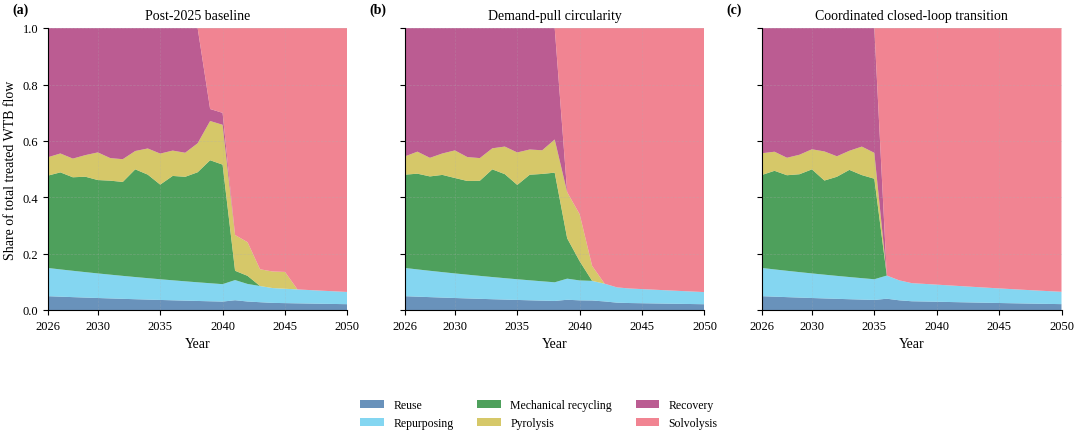

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# Shared utilities for journal-style figures (from dLVf_zBtHO1s)
# ============================================================

def set_year_axis(
    ax,
    start_year=START_YEAR,
    end_year=END_YEAR,
    preferred_ticks=None,
):
    """
    Applies a compact and consistent simulation-year axis.
    """
    start_year = int(start_year)
    end_year = int(end_year)

    if end_year < start_year:
        raise ValueError(
            "end_year must be equal to or greater than start_year."
        )

    if preferred_ticks is None:
        preferred_ticks = [
            2026,
            2030,
            2035,
            2040,
            2045,
            2050,
        ]

    ticks = [
        int(year)
        for year in preferred_ticks
        if start_year <= year <= end_year
    ]

    if start_year not in ticks:
        ticks.insert(
            0,
            start_year,
        )

    if end_year not in ticks:
        ticks.append(
            end_year
        )

    ticks = sorted(
        set(ticks)
    )

    ax.set_xlim(
        start_year,
        end_year,
    )

    ax.set_xticks(
        ticks
    )

    return ax

def get_available_scenarios(results):
    """
    Returns recognized scenarios in manuscript order.
    """
    validate_plotting_columns(
        dataframe=results,
        required_columns=[
            "scenario",
            "year",
        ],
    )

    observed_scenarios = set(
        results
        [
            "scenario"
        ]
        .dropna()
        .unique()
    )

    available_scenarios = [
        scenario
        for scenario in SCENARIO_ORDER
        if scenario in observed_scenarios
    ]

    if not available_scenarios:
        raise ValueError(
            "The results DataFrame contains "
            "no recognized scenarios."
        )

    return available_scenarios

def get_run_identifier_column(results):
    """
    Detects the column identifying Monte Carlo runs.

    Returns
    -------
    str or None
        Run-identifier column, or None for a single simulation.
    """
    candidates = [
        "run",
        "run_id",
        "simulation_run",
        "mc_run",
        "iteration",
    ]

    for column in candidates:
        if column in results.columns:
            return column

    return None

def summarize_indicator_by_scenario_year(
    results,
    indicator,
    quantiles=(0.05, 0.50, 0.95),
):
    """
    Summarizes an indicator by scenario and year.

    For Monte Carlo results, the function returns the lower,
    median, and upper quantiles.

    For a single simulation, the observed value is treated as
    the median and uncertainty bounds are returned as missing.
    """
    validate_plotting_columns(
        dataframe=results,
        required_columns=[
            "scenario",
            "year",
            indicator,
        ],
    )

    if len(quantiles) != 3:
        raise ValueError(
            "quantiles must contain exactly "
            "three values: lower, median, and upper."
        )

    lower_q, median_q, upper_q = (
        quantiles
    )

    if not (
        0.0
        <= lower_q
        <= median_q
        <= upper_q
        <= 1.0
    ):
        raise ValueError(
            "Quantiles must satisfy "
            "0 <= lower <= median <= upper <= 1."
        )

    data = results[
        [
            "scenario",
            "year",
            indicator,
        ]
    ].copy()

    run_column = (
        get_run_identifier_column(
            results
        )
    )

    # --------------------------------------------------------
    # Single deterministic run
    # --------------------------------------------------------

    if run_column is None:
        data = data.rename(
            columns={
                indicator: "median",
            }
        )

        data["lower"] = np.nan
        data["upper"] = np.nan

        return data[
            [
                "scenario",
                "year",
                "lower",
                "median",
                "upper",
            ]
        ]

    # --------------------------------------------------------
    # Monte Carlo summary
    # --------------------------------------------------------

    summary = (
        data
        .groupby(
            [
                "scenario",
                "year",
            ],
            as_index=False,
        )
        .agg(
            lower=(
                indicator,
                lambda values: values.quantile(
                    lower_q
                ),
            ),
            median=(
                indicator,
                lambda values: values.quantile(
                    median_q
                ),
            ),
            upper=(
                indicator,
                lambda values: values.quantile(
                    upper_q
                ),
            ),
        )
    )

    return summary

def plot_scenario_indicator(
    ax,
    summary,
    scenario,
    show_uncertainty=True,
    uncertainty_alpha=0.16,
    label=None,
):
    """
    Plots one scenario trajectory and its optional uncertainty band.
    """
    required_summary_columns = [
        "scenario",
        "year",
        "lower",
        "median",
        "upper",
    ]

    validate_plotting_columns(
        dataframe=summary,
        required_columns=(
            required_summary_columns
        ),
    )

    if scenario not in SCENARIO_ORDER:
        raise ValueError(
            f"Unknown scenario: {scenario}"
        )

    scenario_data = (
        summary.loc[
            summary["scenario"]
            == scenario
        ]
        .sort_values("year")
    )

    if scenario_data.empty:
        return ax

    ax.plot(
        scenario_data["year"],
        scenario_data["median"],
        color=(
            SCENARIO_COLORS[
                scenario
            ]
        ),
        linestyle=(
            SCENARIO_LINESTYLES[
                scenario
            ]
        ),
        linewidth=1.8,
        label=(
            label
            if label is not None
            else SCENARIO_LABELS[
                scenario
            ]
        ),
    )

    uncertainty_available = (
        scenario_data
        [
            "lower"
        ].notna().any()
        and
        scenario_data
        [
            "upper"
        ].notna().any()
    )

    if (
        show_uncertainty
        and uncertainty_available
    ):
        ax.fill_between(
            scenario_data["year"],
            scenario_data["lower"],
            scenario_data["upper"],
            color=(
                SCENARIO_COLORS[
                    scenario
                ]
            ),
            alpha=uncertainty_alpha,
            linewidth=0.0,
        )

    return ax

# ============================================================
# Generate Figure 2 (including its function definition from 54b1d322)
# ============================================================

def plot_pathway_shares_journal(
    results,
    y_upper=None,
    show_uncertainty=True,
    filename="figure_2_pathway_allocation",
):
    """
    Plots the annual WTB flow shares for each pathway across scenarios.

    The shares are calculated relative to the total treated WTB flow in that year.

    Parameters
    ----------
    results : pandas.DataFrame
        Deterministic or Monte Carlo simulation results.

    y_upper : float or None
        Upper limit of the y-axis. If None, it is determined automatically.

    show_uncertainty : bool
        Displays uncertainty intervals (not implemented for stacked plots).
        Currently, only median stackplots are shown, even if True.

    filename : str
        Output filename without extension.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    # Validate required columns for input `results`
    required_cols = ["scenario", "year", "total_treated"] + list(PATHWAY_FLOW_COLUMNS.values())
    if "run_id" in results.columns:
        required_cols.append("run_id")
    validate_plotting_columns(dataframe=results, required_columns=required_cols)

    # Calculate pathway shares for each row
    plotting_data = results.copy()
    for pathway in PATHWAY_ORDER:
        col_flow = PATHWAY_FLOW_COLUMNS[pathway]
        # Handle potential division by zero or NaN values
        plotting_data[f"share_{pathway}"] = plotting_data[col_flow] / plotting_data["total_treated"]
        plotting_data[f"share_{pathway}"] = plotting_data[f"share_{pathway}"].fillna(0).replace([np.inf, -np.inf], 0)
        # Clip shares to [0, 1] in case of minor numerical issues
        plotting_data[f"share_{pathway}"] = plotting_data[f"share_{pathway}"].clip(0, 1)

    # Summarize shares by scenario and year (median/mean for plotting)
    summaries_by_pathway = {}
    for pathway_idx, pathway in enumerate(PATHWAY_ORDER):
        indicator = f"share_{pathway}"
        # summarize_indicator_by_scenario_year handles both MC and deterministic cases
        summary = summarize_indicator_by_scenario_year(
            results=plotting_data,
            indicator=indicator,
            quantiles=(0.05, 0.50, 0.95) # 0.50 is for median
        )
        summary = summary.rename(columns={
            "median": f"{indicator}_median",
            "lower": f"{indicator}_lower",
            "upper": f"{indicator}_upper"
        })
        summaries_by_pathway[pathway] = summary

    # Merge all pathway summaries into a single DataFrame for plotting
    merged_summary = None
    for pathway_idx, pathway in enumerate(PATHWAY_ORDER):
        if merged_summary is None:
            merged_summary = summaries_by_pathway[pathway]
        else:
            merged_summary = pd.merge(merged_summary, summaries_by_pathway[pathway], on=["scenario", "year"], how="outer")

    # Sort for consistent plotting
    merged_summary = merged_summary.sort_values(["scenario", "year"])

    available_scenarios = get_available_scenarios(results)
    n_scenarios = len(available_scenarios)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_scenarios,
        figsize=(FIGSIZE_ONE_AND_HALF_COLUMN[0] * n_scenarios / 1.5, FIGSIZE_ONE_AND_HALF_COLUMN[1] * 1.2),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_1d(axes)

    for i, scenario in enumerate(available_scenarios):
        ax = axes[i]
        scenario_data = merged_summary[merged_summary["scenario"] == scenario].copy()

        # Prepare data for stackplot using median shares
        x_years = scenario_data["year"]
        y_shares = [scenario_data[f"share_{p}_median"] for p in PATHWAY_ORDER]

        ax.stackplot(
            x_years,
            y_shares,
            colors=[PATHWAY_COLORS[p] for p in PATHWAY_ORDER],
            labels=[PATHWAY_LABELS[p] for p in PATHWAY_ORDER],
            alpha=0.8
        )

        # For stacked area plots, showing uncertainty for individual layers is complex and often omitted.
        # This implementation focuses on plotting the median shares as requested by initial `show_uncertainty=False`.

        ax.set_title(SCENARIO_LABELS[scenario], fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylim(0.0, y_upper if y_upper is not None else 1.0)
        ax.set_yticks(np.arange(0.0, (y_upper if y_upper is not None else 1.0) + 0.001, 0.20))
        set_year_axis(ax, start_year=int(results["year"].min()), end_year=int(results["year"].max()))
        clean_axis(ax, horizontal_grid=False, vertical_grid=False) # No horizontal grid for stacked areas for clarity.
        add_panel_label(ax, label=f"({chr(97 + i)})")

    axes[0].set_ylabel("Share of total treated WTB flow")

    # Common legend for all subplots
    handles, labels = axes[0].get_legend_handles_labels() # Get from first axis
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.05), handlelength=2.0)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.25) # Adjust bottom to make space for legend

    save_figure(fig, filename=filename, formats=("pdf", "svg", "png"), dpi=600, close=False)

    return fig

# Call the plotting function
fig_pathway_allocation = plot_pathway_shares_journal(
    results=results,
    y_upper=1.0,
    show_uncertainty=False,
    filename="figure_2_pathway_allocation",
)

plt.show()

In [53]:
# ============================================================
# 9. Shared utilities for journal-style figures
# ============================================================

# This cell reuses the plotting configuration defined previously:
#
# - FIG_DIR
# - SCENARIO_LABELS
# - SCENARIO_ORDER
# - SCENARIO_COLORS
# - SCENARIO_LINESTYLES
# - SCENARIO_MARKERS
# - clean_axis()
# - add_panel_label()
# - save_figure()
# - validate_plotting_columns()
#
# The visual configuration is defined only once to ensure
# consistency across all manuscript figures.


# ------------------------------------------------------------
# Year-axis formatting
# ------------------------------------------------------------

def set_year_axis(
    ax,
    start_year=START_YEAR,
    end_year=END_YEAR,
    preferred_ticks=None,
):
    """
    Applies a compact and consistent simulation-year axis.
    """
    start_year = int(start_year)
    end_year = int(end_year)

    if end_year < start_year:
        raise ValueError(
            "end_year must be equal to or greater than start_year."
        )

    if preferred_ticks is None:
        preferred_ticks = [
            2026,
            2030,
            2035,
            2040,
            2045,
            2050,
        ]

    ticks = [
        int(year)
        for year in preferred_ticks
        if start_year <= year <= end_year
    ]

    if start_year not in ticks:
        ticks.insert(
            0,
            start_year,
        )

    if end_year not in ticks:
        ticks.append(
            end_year
        )

    ticks = sorted(
        set(ticks)
    )

    ax.set_xlim(
        start_year,
        end_year,
    )

    ax.set_xticks(
        ticks
    )

    return ax


# ------------------------------------------------------------
# Scenario detection
# ------------------------------------------------------------

def get_available_scenarios(results):
    """
    Returns recognized scenarios in manuscript order.
    """
    validate_plotting_columns(
        dataframe=results,
        required_columns=[
            "scenario",
            "year",
        ],
    )

    observed_scenarios = set(
        results[
            "scenario"
        ]
        .dropna()
        .unique()
    )

    available_scenarios = [
        scenario
        for scenario in SCENARIO_ORDER
        if scenario in observed_scenarios
    ]

    if not available_scenarios:
        raise ValueError(
            "The results DataFrame contains "
            "no recognized scenarios."
        )

    return available_scenarios


# ------------------------------------------------------------
# Monte Carlo run detection
# ------------------------------------------------------------

def get_run_identifier_column(results):
    """
    Detects the column identifying Monte Carlo runs.

    Returns
    -------
    str or None
        Run-identifier column, or None for a single simulation.
    """
    candidates = [
        "run",
        "run_id",
        "simulation_run",
        "mc_run",
        "iteration",
    ]

    for column in candidates:
        if column in results.columns:
            return column

    return None


# ------------------------------------------------------------
# Scenario-year indicator summary
# ------------------------------------------------------------

def summarize_indicator_by_scenario_year(
    results,
    indicator,
    quantiles=(0.05, 0.50, 0.95),
):
    """
    Summarizes an indicator by scenario and year.

    For Monte Carlo results, the function returns the lower,
    median, and upper quantiles.

    For a single simulation, the observed value is treated as
    the median and uncertainty bounds are returned as missing.
    """
    validate_plotting_columns(
        dataframe=results,
        required_columns=[
            "scenario",
            "year",
            indicator,
        ],
    )

    if len(quantiles) != 3:
        raise ValueError(
            "quantiles must contain exactly "
            "three values: lower, median, and upper."
        )

    lower_q, median_q, upper_q = (
        quantiles
    )

    if not (
        0.0
        <= lower_q
        <= median_q
        <= upper_q
        <= 1.0
    ):
        raise ValueError(
            "Quantiles must satisfy "
            "0 <= lower <= median <= upper <= 1."
        )

    data = results[
        [
            "scenario",
            "year",
            indicator,
        ]
    ].copy()

    run_column = (
        get_run_identifier_column(
            results
        )
    )

    # --------------------------------------------------------
    # Single deterministic run
    # --------------------------------------------------------

    if run_column is None:
        data = data.rename(
            columns={
                indicator: "median",
            }
        )

        data["lower"] = np.nan
        data["upper"] = np.nan

        return data[
            [
                "scenario",
                "year",
                "lower",
                "median",
                "upper",
            ]
        ]

    # --------------------------------------------------------
    # Monte Carlo summary
    # --------------------------------------------------------

    summary = (
        data
        .groupby(
            [
                "scenario",
                "year",
            ],
            as_index=False,
        )
        .agg(
            lower=(
                indicator,
                lambda values: values.quantile(
                    lower_q
                ),
            ),
            median=(
                indicator,
                lambda values: values.quantile(
                    median_q
                ),
            ),
            upper=(
                indicator,
                lambda values: values.quantile(
                    upper_q
                ),
            ),
        )
    )

    return summary


# ------------------------------------------------------------
# Scenario trajectory plotting
# ------------------------------------------------------------

def plot_scenario_indicator(
    ax,
    summary,
    scenario,
    show_uncertainty=True,
    uncertainty_alpha=0.16,
    label=None,
):
    """
    Plots one scenario trajectory and its optional uncertainty band.
    """
    required_summary_columns = [
        "scenario",
        "year",
        "lower",
        "median",
        "upper",
    ]

    validate_plotting_columns(
        dataframe=summary,
        required_columns=(
            required_summary_columns
        ),
    )

    if scenario not in SCENARIO_ORDER:
        raise ValueError(
            f"Unknown scenario: {scenario}"
        )

    scenario_data = (
        summary.loc[
            summary["scenario"]
            == scenario
        ]
        .sort_values("year")
    )

    if scenario_data.empty:
        return ax

    ax.plot(
        scenario_data["year"],
        scenario_data["median"],
        color=(
            SCENARIO_COLORS[
                scenario
            ]
        ),
        linestyle=(
            SCENARIO_LINESTYLES[
                scenario
            ]
        ),
        linewidth=1.8,
        label=(
            label
            if label is not None
            else SCENARIO_LABELS[
                scenario
            ]
        ),
    )

    uncertainty_available = (
        scenario_data[
            "lower"
        ].notna().any()
        and
        scenario_data[
            "upper"
        ].notna().any()
    )

    if (
        show_uncertainty
        and uncertainty_available
    ):
        ax.fill_between(
            scenario_data["year"],
            scenario_data["lower"],
            scenario_data["upper"],
            color=(
                SCENARIO_COLORS[
                    scenario
                ]
            ),
            alpha=uncertainty_alpha,
            linewidth=0.0,
        )

    return ax


# ------------------------------------------------------------
# Required-object consistency check
# ------------------------------------------------------------

_required_plotting_objects = [
    "FIG_DIR",
    "SCENARIO_LABELS",
    "SCENARIO_ORDER",
    "SCENARIO_COLORS",
    "SCENARIO_LINESTYLES",
    "SCENARIO_MARKERS",
    "clean_axis",
    "add_panel_label",
    "save_figure",
    "validate_plotting_columns",
]

_missing_plotting_objects = [
    object_name
    for object_name
    in _required_plotting_objects
    if object_name not in globals()
]

if _missing_plotting_objects:
    raise RuntimeError(
        "Run the journal-style plotting "
        "configuration cell first. Missing objects: "
        + ", ".join(
            _missing_plotting_objects
        )
    )

print(
    "Shared plotting utilities loaded successfully."
)

Shared plotting utilities loaded successfully.


In [ ]:
# ============================================================
# Figure 3. Solvolysis diffusion across scenarios
# ============================================================

def plot_solvolysis_diffusion_journal(
    results,
    y_upper=None,
    show_uncertainty=True,
    filename="figure_3_solvolysis_diffusion",
):
    """
    Plots the diffusion of solvolysis across transition scenarios.

    Solvolysis diffusion is measured as the share of total treated
    WTB flow processed through solvolysis.

    This indicator is distinct from the closed-loop WTB flow share,
    because not all solvolysis-derived material is necessarily used
    in closed-loop applications.

    Parameters
    ----------
    results : pandas.DataFrame
        Deterministic or Monte Carlo simulation results.

    y_upper : float or None
        Upper limit of the y-axis. If None, it is determined
        automatically.

    show_uncertainty : bool
        Displays the 5th-95th percentile interval when Monte Carlo
        results are available.

    filename : str
        Output filename without extension.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    indicator = (
        "solvolysis_treatment_share"
    )

    validate_plotting_columns(
        dataframe=results,
        required_columns=[
            "scenario",
            "year",
            indicator,
        ],
    )

    summary = (
        summarize_indicator_by_scenario_year(
            results=results,
            indicator=indicator,
            quantiles=(
                0.05,
                0.50,
                0.95,
            ),
        )
    )

    available_scenarios = (
        get_available_scenarios(
            results
        )
    )

    fig, ax = plt.subplots(
        figsize=FIGSIZE_ONE_AND_HALF_COLUMN
    )

    for scenario in available_scenarios:
        plot_scenario_indicator(
            ax=ax,
            summary=summary,
            scenario=scenario,
            show_uncertainty=(
                show_uncertainty
            ),
            uncertainty_alpha=0.14,
        )

    # --------------------------------------------------------
    # Automatic y-axis limit
    # --------------------------------------------------------

    observed_upper = float(
        summary["median"].max()
    )

    if (
        show_uncertainty
        and summary["upper"].notna().any()
    ):
        observed_upper = max(
            observed_upper,
            float(
                summary["upper"].max()
            ),
        )

    if y_upper is None:
        y_upper = min(
            1.0,
            max(
                0.10,
                np.ceil(
                    observed_upper
                    * 20.0
                )
                / 20.0
                + 0.05,
            ),
        )

    if not (
        0.0
        < y_upper
        <= 1.0
    ):
        raise ValueError(
            "y_upper must lie between 0 and 1."
        )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        "Solvolysis share of treated WTB flow"
    )

    ax.set_ylim(
        0.0,
        y_upper,
    )

    ax.set_yticks(
        np.arange(
            0.0,
            y_upper + 0.001,
            0.20,
        )
    )

    set_year_axis(
        ax=ax,
        start_year=int(
            results["year"].min()
        ),
        end_year=int(
            results["year"].max()
        ),
    )

    clean_axis(
        ax=ax,
        horizontal_grid=True,
        vertical_grid=False,
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=2.8,
    )

    fig.tight_layout()

    save_figure(
        fig=fig,
        filename=filename,
        formats=(
            "pdf",
            "svg",
            "png",
        ),
        dpi=600,
        close=False,
    )

    return fig


# ============================================================
# Generate deterministic figure
# ============================================================

fig_solvolysis_diffusion = (
    plot_solvolysis_diffusion_journal(
        results=results,
        y_upper=1.0,
        show_uncertainty=False,
        filename=(
            "figure_3_solvolysis_diffusion"
        ),
    )
)

plt.show()

In [ ]:
# ============================================================
# Figure 4. Open-loop versus closed-loop material utilization
# ============================================================

def prepare_open_closed_utilization_summary(
    results,
):
    """
    Prepares annual open-loop and closed-loop utilization shares.

    For Monte Carlo results, annual medians and 5th-95th percentile
    intervals are calculated by scenario.

    Open-loop and closed-loop utilization shares are calculated
    relative to the total amount of recovered material actually used.
    """
    required_columns = [
        "scenario",
        "year",
        "open_loop_utilization_share",
        "closed_loop_utilization_share",
    ]

    validate_plotting_columns(
        dataframe=results,
        required_columns=required_columns,
    )

    open_summary = (
        summarize_indicator_by_scenario_year(
            results=results,
            indicator=(
                "open_loop_utilization_share"
            ),
            quantiles=(
                0.05,
                0.50,
                0.95,
            ),
        )
        .rename(
            columns={
                "lower": "open_lower",
                "median": "open_median",
                "upper": "open_upper",
            }
        )
    )

    closed_summary = (
        summarize_indicator_by_scenario_year(
            results=results,
            indicator=(
                "closed_loop_utilization_share"
            ),
            quantiles=(
                0.05,
                0.50,
                0.95,
            ),
        )
        .rename(
            columns={
                "lower": "closed_lower",
                "median": "closed_median",
                "upper": "closed_upper",
            }
        )
    )

    summary = open_summary.merge(
        closed_summary,
        on=[
            "scenario",
            "year",
        ],
        how="outer",
        validate="one_to_one",
    )

    return summary


def plot_open_closed_loop_journal(
    results,
    show_uncertainty=False,
    filename=(
        "figure_4_open_closed_loop_utilization"
    ),
):
    """
    Plots open-loop and closed-loop utilization shares
    across transition scenarios.

    Parameters
    ----------
    results : pandas.DataFrame
        Deterministic or Monte Carlo simulation results.

    show_uncertainty : bool
        Displays 5th-95th percentile intervals when Monte Carlo
        results are available.

    filename : str
        Output filename without extension.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    summary = (
        prepare_open_closed_utilization_summary(
            results=results
        )
    )

    available_scenarios = (
        get_available_scenarios(
            results
        )
    )

    number_of_scenarios = len(
        available_scenarios
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=number_of_scenarios,
        figsize=(
            4.25 * number_of_scenarios,
            4.10,
        ),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(
        axes
    )

    utilization_colors = {
        "open_loop": "#4477AA",
        "closed_loop": "#EE6677",
    }

    utilization_linestyles = {
        "open_loop": "--",
        "closed_loop": "-",
    }

    for panel_index, (
        ax,
        scenario,
    ) in enumerate(
        zip(
            axes,
            available_scenarios,
        )
    ):
        scenario_data = (
            summary.loc[
                summary["scenario"]
                == scenario
            ]
            .sort_values("year")
        )

        ax.plot(
            scenario_data["year"],
            scenario_data[
                "open_median"
            ],
            label=(
                "Open-loop utilization"
            ),
            color=(
                utilization_colors[
                    "open_loop"
                ]
            ),
            linestyle=(
                utilization_linestyles[
                    "open_loop"
                ]
            ),
            linewidth=1.9,
        )

        ax.plot(
            scenario_data["year"],
            scenario_data[
                "closed_median"
            ],
            label=(
                "Closed-loop utilization"
            ),
            color=(
                utilization_colors[
                    "closed_loop"
                ]
            ),
            linestyle=(
                utilization_linestyles[
                    "closed_loop"
                ]
            ),
            linewidth=1.9,
        )

        if (
            show_uncertainty
            and scenario_data[
                "open_lower"
            ].notna().any()
            and scenario_data[
                "open_upper"
            ].notna().any()
        ):
            ax.fill_between(
                scenario_data["year"],
                scenario_data[
                    "open_lower"
                ],
                scenario_data[
                    "open_upper"
                ],
                color=(
                    utilization_colors[
                        "open_loop"
                    ]
                ),
                alpha=0.10,
                linewidth=0.0,
            )

        if (
            show_uncertainty
            and scenario_data[
                "closed_lower"
            ].notna().any()
            and scenario_data[
                "closed_upper"
            ].notna().any()
        ):
            ax.fill_between(
                scenario_data["year"],
                scenario_data[
                    "closed_lower"
                ],
                scenario_data[
                    "closed_upper"
                ],
                color=(
                    utilization_colors[
                        "closed_loop"
                    ]
                ),
                alpha=0.10,
                linewidth=0.0,
            )

        ax.set_title(
            SCENARIO_LABELS[
                scenario
            ]
        )

        ax.set_xlabel(
            "Year"
        )

        ax.set_ylim(
            0.0,
            1.0,
        )

        ax.set_yticks(
            np.arange(
                0.0,
                1.01,
                0.20,
            )
        )

        set_year_axis(
            ax=ax,
            start_year=int(
                results[
                    "year"
                ].min()
            ),
            end_year=int(
                results[
                    "year"
                ].max()
            ),
        )

        clean_axis(
            ax=ax,
            horizontal_grid=True,
            vertical_grid=False,
        )

        add_panel_label(
            ax=ax,
            label=(
                f"({chr(97 + panel_index)})"
            ),
            x=-0.10,
            y=1.02,
        )

    axes[0].set_ylabel(
        "Share of utilized recovered material"
    )

    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(
            0.5,
            -0.01,
        ),
        handlelength=2.8,
        columnspacing=2.0,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.99,
        top=0.88,
        bottom=0.22,
        wspace=0.12,
    )

    save_figure(
        fig=fig,
        filename=filename,
        formats=(
            "pdf",
            "svg",
            "png",
        ),
        dpi=600,
        close=False,
    )

    return fig


# ============================================================
# Generate deterministic Figure 4
# ============================================================

fig_open_closed_utilization = (
    plot_open_closed_loop_journal(
        results=results,
        show_uncertainty=False,
        filename=(
            "figure_4_open_closed_loop_utilization"
        ),
    )
)

plt.show()

In [ ]:
# ============================================================
# Figure 5. Annual net untreated WTB stock increase
# ============================================================

def plot_annual_untreated_share_journal(
    results,
    y_upper=None,
    show_uncertainty=True,
    filename="figure_5_annual_untreated_share",
):
    """
    Plots the annual net increase in untreated WTB stock
    relative to annual decommissioned WTB inflow.

    The indicator is defined as:

        net untreated stock increase / annual decommissioned inflow

    where the net stock increase is:

        max(closing untreated stock - opening untreated stock, 0)

    Parameters
    ----------
    results : pandas.DataFrame
        Deterministic or Monte Carlo simulation results.

    y_upper : float or None
        Upper limit of the y-axis. If None, it is determined
        automatically.

    show_uncertainty : bool
        Displays the 5th-95th percentile interval when Monte Carlo
        results are available.

    filename : str
        Output filename without extension.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    indicator = (
        "net_untreated_stock_increase_share"
    )

    validate_plotting_columns(
        dataframe=results,
        required_columns=[
            "scenario",
            "year",
            indicator,
        ],
    )

    plotting_results = results.copy()

    # Limit only small floating-point deviations.
    plotting_results[indicator] = (
        plotting_results[indicator]
        .clip(
            lower=0.0,
            upper=1.0,
        )
    )

    # --------------------------------------------------------
    # Summarize deterministic or Monte Carlo trajectories
    # --------------------------------------------------------

    summary = (
        summarize_indicator_by_scenario_year(
            results=plotting_results,
            indicator=indicator,
            quantiles=(
                0.05,
                0.50,
                0.95,
            ),
        )
    )

    available_scenarios = (
        get_available_scenarios(
            plotting_results
        )
    )

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=FIGSIZE_ONE_AND_HALF_COLUMN
    )

    for scenario in available_scenarios:
        plot_scenario_indicator(
            ax=ax,
            summary=summary,
            scenario=scenario,
            show_uncertainty=(
                show_uncertainty
            ),
            uncertainty_alpha=0.14,
        )

    # --------------------------------------------------------
    # Automatic y-axis limit
    # --------------------------------------------------------

    observed_upper = float(
        summary["median"].max()
    )

    if (
        show_uncertainty
        and summary["upper"].notna().any()
    ):
        observed_upper = max(
            observed_upper,
            float(
                summary["upper"].max()
            ),
        )

    if y_upper is None:
        y_upper = min(
            1.0,
            max(
                0.10,
                np.ceil(
                    observed_upper
                    * 20.0
                )
                / 20.0
                + 0.05,
            ),
        )

    if not (
        0.0
        < y_upper
        <= 1.0
    ):
        raise ValueError(
            "y_upper must lie between 0 and 1."
        )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        "Net untreated WTB stock increase share"
    )

    ax.set_ylim(
        0.0,
        y_upper,
    )

    ax.set_yticks(
        np.arange(
            0.0,
            y_upper + 0.001,
            0.10,
        )
    )

    set_year_axis(
        ax=ax,
        start_year=int(
            plotting_results[
                "year"
            ].min()
        ),
        end_year=int(
            plotting_results[
                "year"
            ].max()
        ),
    )

    clean_axis(
        ax=ax,
        horizontal_grid=True,
        vertical_grid=False,
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=2.8,
    )

    fig.tight_layout()

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    save_figure(
        fig=fig,
        filename=filename,
        formats=(
            "pdf",
            "svg",
            "png",
        ),
        dpi=600,
        close=False,
    )

    return fig


# ============================================================
# Generate deterministic Figure 5
# ============================================================

fig_annual_untreated_share = (
    plot_annual_untreated_share_journal(
        results=results,
        y_upper=0.70,
        show_uncertainty=False,
        filename=(
            "figure_5_annual_untreated_share"
        ),
    )
)

plt.show()

In [ ]:
# ============================================================
# Figure 6. Economic and environmental outcomes
# ============================================================

def add_y_margin(
    ax,
    values,
    margin=0.08,
    force_zero=False,
):
    """
    Sets y-axis limits with a proportional margin.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to format.

    values : array-like
        Numerical values used to determine the axis range.

    margin : float
        Proportional margin added above and below the observed range.

    force_zero : bool
        If True and all values are non-negative, the lower limit
        is fixed at zero.

    Returns
    -------
    matplotlib.axes.Axes
        Formatted axis.
    """
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if values.size == 0:
        return ax

    y_min = float(
        np.min(values)
    )

    y_max = float(
        np.max(values)
    )

    span = y_max - y_min

    if span <= NUMERICAL_EPSILON:
        span = (
            abs(y_max)
            if abs(y_max)
            > NUMERICAL_EPSILON
            else 1.0
        )

    lower_limit = (
        y_min
        - margin * span
    )

    upper_limit = (
        y_max
        + margin * span
    )

    if (
        force_zero
        and y_min >= 0.0
    ):
        lower_limit = 0.0

    elif lower_limit > 0.0:
        lower_limit = max(
            0.0,
            lower_limit,
        )

    ax.set_ylim(
        lower_limit,
        upper_limit,
    )

    return ax


def plot_cost_and_ghg_journal(
    results,
    show_uncertainty=True,
    filename="figure_6_cost_ghg",
):
    """
    Plots average processing cost and avoided GHG impact
    across transition scenarios.

    Panel (a) shows the annual average processing-cost index.

    Panel (b) shows the annual avoided GHG impact index associated
    with recovered-material utilization and resource recovery.

    For Monte Carlo results, solid lines represent medians and
    shaded areas represent 5th-95th percentile intervals.

    Parameters
    ----------
    results : pandas.DataFrame
        Deterministic or Monte Carlo simulation results.

    show_uncertainty : bool
        Displays uncertainty intervals when Monte Carlo results
        are available.

    filename : str
        Output filename without extension.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    required_columns = [
        "scenario",
        "year",
        "average_processing_cost",
        "avoided_ghg_index",
    ]

    validate_plotting_columns(
        dataframe=results,
        required_columns=required_columns,
    )

    available_scenarios = (
        get_available_scenarios(
            results
        )
    )

    # --------------------------------------------------------
    # Indicator summaries
    # --------------------------------------------------------

    cost_summary = (
        summarize_indicator_by_scenario_year(
            results=results,
            indicator=(
                "average_processing_cost"
            ),
            quantiles=(
                0.05,
                0.50,
                0.95,
            ),
        )
    )

    ghg_summary = (
        summarize_indicator_by_scenario_year(
            results=results,
            indicator=(
                "avoided_ghg_index"
            ),
            quantiles=(
                0.05,
                0.50,
                0.95,
            ),
        )
    )

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(
            10.8,
            4.2,
        ),
        sharex=True,
    )

    ax_cost = axes[0]
    ax_ghg = axes[1]

    # ========================================================
    # Panel (a): Average processing cost
    # ========================================================

    for scenario in available_scenarios:
        plot_scenario_indicator(
            ax=ax_cost,
            summary=cost_summary,
            scenario=scenario,
            show_uncertainty=(
                show_uncertainty
            ),
            uncertainty_alpha=0.14,
        )

    ax_cost.set_title(
        "Average processing cost"
    )

    ax_cost.set_xlabel(
        "Year"
    )

    ax_cost.set_ylabel(
        "Average processing-cost index"
    )

    set_year_axis(
        ax=ax_cost,
        start_year=int(
            results["year"].min()
        ),
        end_year=int(
            results["year"].max()
        ),
    )

    cost_axis_values = list(
        cost_summary[
            "median"
        ].dropna()
    )

    if (
        show_uncertainty
        and cost_summary[
            "lower"
        ].notna().any()
        and cost_summary[
            "upper"
        ].notna().any()
    ):
        cost_axis_values.extend(
            cost_summary[
                "lower"
            ].dropna()
        )

        cost_axis_values.extend(
            cost_summary[
                "upper"
            ].dropna()
        )

    add_y_margin(
        ax=ax_cost,
        values=cost_axis_values,
        margin=0.10,
        force_zero=False,
    )

    clean_axis(
        ax=ax_cost,
        horizontal_grid=True,
        vertical_grid=False,
    )

    add_panel_label(
        ax=ax_cost,
        label="(a)",
        x=-0.12,
        y=1.03,
    )

    # ========================================================
    # Panel (b): Avoided GHG impact
    # ========================================================

    for scenario in available_scenarios:
        plot_scenario_indicator(
            ax=ax_ghg,
            summary=ghg_summary,
            scenario=scenario,
            show_uncertainty=(
                show_uncertainty
            ),
            uncertainty_alpha=0.14,
        )

    ax_ghg.set_title(
        "Avoided GHG impact"
    )

    ax_ghg.set_xlabel(
        "Year"
    )

    ax_ghg.set_ylabel(
        "Avoided GHG impact index"
    )

    set_year_axis(
        ax=ax_ghg,
        start_year=int(
            results["year"].min()
        ),
        end_year=int(
            results["year"].max()
        ),
    )

    ghg_axis_values = list(
        ghg_summary[
            "median"
        ].dropna()
    )

    if (
        show_uncertainty
        and ghg_summary[
            "lower"
        ].notna().any()
        and ghg_summary[
            "upper"
        ].notna().any()
    ):
        ghg_axis_values.extend(
            ghg_summary[
                "lower"
            ].dropna()
        )

        ghg_axis_values.extend(
            ghg_summary[
                "upper"
            ].dropna()
        )

    add_y_margin(
        ax=ax_ghg,
        values=ghg_axis_values,
        margin=0.10,
        force_zero=True,
    )

    clean_axis(
        ax=ax_ghg,
        horizontal_grid=True,
        vertical_grid=False,
    )

    add_panel_label(
        ax=ax_ghg,
        label="(b)",
        x=-0.12,
        y=1.03,
    )

    # --------------------------------------------------------
    # Shared legend
    # --------------------------------------------------------

    handles, labels = (
        ax_ghg
        .get_legend_handles_labels()
    )

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(
            0.5,
            -0.01,
        ),
        columnspacing=1.5,
        handlelength=2.8,
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.99,
        top=0.88,
        bottom=0.23,
        wspace=0.28,
    )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    save_figure(
        fig=fig,
        filename=filename,
        formats=(
            "pdf",
            "svg",
            "png",
        ),
        dpi=600,
        close=False,
    )

    return fig


# ============================================================
# Generate deterministic Figure 6
# ============================================================

fig_cost_ghg = (
    plot_cost_and_ghg_journal(
        results=results,
        show_uncertainty=False,
        filename=(
            "figure_6_cost_ghg"
        ),
    )
)

plt.show()

In [ ]:
# ============================================================
# Figure 7. Solvolysis technology maturity trajectory
# ============================================================

def plot_solvolysis_maturity_journal(
    results,
    y_lower=5.0,
    y_upper=9.0,
    show_uncertainty=True,
    filename="figure_7_solvolysis_maturity",
):
    """
    Plots the opening-period solvolysis technology maturity
    trajectory across transition scenarios.

    Technology maturity is represented by the stylized
    technology-readiness-level trajectory observed by agents
    at the beginning of each simulation year.

    The horizontal reference line indicates the maturity
    threshold above which solvolysis becomes available for
    commercial investment.

    Parameters
    ----------
    results : pandas.DataFrame
        Deterministic or Monte Carlo simulation results.

    y_lower : float
        Lower y-axis limit.

    y_upper : float
        Upper y-axis limit.

    show_uncertainty : bool
        Displays the 5th-95th percentile interval when Monte Carlo
        uncertainty affects the maturity trajectory.

    filename : str
        Output filename without extension.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    indicator = (
        "opening_trl_solvolysis"
    )

    validate_plotting_columns(
        dataframe=results,
        required_columns=[
            "scenario",
            "year",
            indicator,
        ],
    )

    if y_upper <= y_lower:
        raise ValueError(
            "y_upper must be greater than y_lower."
        )

    if y_lower < 1.0 or y_upper > 9.0:
        raise ValueError(
            "TRL axis limits must remain within the interval [1, 9]."
        )

    # --------------------------------------------------------
    # Summarize trajectories
    # --------------------------------------------------------

    summary = (
        summarize_indicator_by_scenario_year(
            results=results,
            indicator=indicator,
            quantiles=(
                0.05,
                0.50,
                0.95,
            ),
        )
    )

    available_scenarios = (
        get_available_scenarios(
            results
        )
    )

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=FIGSIZE_ONE_AND_HALF_COLUMN
    )

    for scenario in available_scenarios:
        plot_scenario_indicator(
            ax=ax,
            summary=summary,
            scenario=scenario,
            show_uncertainty=(
                show_uncertainty
            ),
            uncertainty_alpha=0.12,
        )

    # --------------------------------------------------------
    # Commercial maturity threshold
    # --------------------------------------------------------

    add_reference_line(
        ax=ax,
        value=TRL_THRESHOLD_SOLVOLYSIS,
        axis="y",
        label=(
            "Commercial maturity threshold"
        ),
        linestyle=":",
        linewidth=1.1,
        alpha=0.80,
    )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        "Solvolysis technology readiness level"
    )

    ax.set_ylim(
        y_lower,
        y_upper,
    )

    ax.set_yticks(
        np.arange(
            np.ceil(y_lower),
            np.floor(y_upper) + 1,
            1,
        )
    )

    set_year_axis(
        ax=ax,
        start_year=int(
            results["year"].min()
        ),
        end_year=int(
            results["year"].max()
        ),
    )

    clean_axis(
        ax=ax,
        horizontal_grid=True,
        vertical_grid=False,
    )

    ax.legend(
        loc="lower right",
        frameon=False,
        handlelength=2.8,
    )

    fig.tight_layout()

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    save_figure(
        fig=fig,
        filename=filename,
        formats=(
            "pdf",
            "svg",
            "png",
        ),
        dpi=600,
        close=False,
    )

    return fig


# ============================================================
# Generate deterministic Figure 7
# ============================================================

fig_solvolysis_maturity = (
    plot_solvolysis_maturity_journal(
        results=results,
        y_lower=5.0,
        y_upper=9.0,
        show_uncertainty=False,
        filename=(
            "figure_7_solvolysis_maturity"
        ),
    )
)

plt.show()

In [ ]:
# ============================================================# 10. Monte Carlo uncertainty analysis# ============================================================import copyimport numpy as npimport pandas as pdfrom dataclasses import replace# ------------------------------------------------------------# Monte Carlo settings# ------------------------------------------------------------# Use 30 runs only for debugging and notebook development.# Increase to at least 500 runs for the final analysis.N_RUNS = 500RANDOM_SEED = 123# ------------------------------------------------------------# Baseline parameter backup# ------------------------------------------------------------# The Monte Carlo procedure temporarily modifies global parameter# dictionaries and scalar values. Every run starts from exactly# the same baseline parameterization.BASE_PARAMETER_BACKUP = {    # Technical and economic parameters    "INITIAL_PROCESSING_COST": copy.deepcopy(        INITIAL_PROCESSING_COST    ),    "LEARNING_EXPONENT": copy.deepcopy(        LEARNING_EXPONENT    ),    "RECOVERY_EFFICIENCY": copy.deepcopy(        RECOVERY_EFFICIENCY    ),    "MATERIAL_QUALITY": copy.deepcopy(        MATERIAL_QUALITY    ),    "MAX_ANNUAL_CAPACITY_EXPANSION": copy.deepcopy(        MAX_ANNUAL_CAPACITY_EXPANSION    ),    "BASE_TRL_GROWTH_SOLVOLYSIS": (        BASE_TRL_GROWTH_SOLVOLYSIS    ),    # Behavioural population means    "MEAN_MANUFACTURER_ADOPTION_THRESHOLD": (        MEAN_MANUFACTURER_ADOPTION_THRESHOLD    ),    "MEAN_PERCEIVED_TECHNICAL_RISK": (        MEAN_PERCEIVED_TECHNICAL_RISK    ),    "MEAN_SUPPLY_RELIABILITY": (        MEAN_SUPPLY_RELIABILITY    ),    # Recycler economics    "BASE_GATE_FEE": copy.deepcopy(        BASE_GATE_FEE    ),    "BASE_LOGISTICS_COST": copy.deepcopy(        BASE_LOGISTICS_COST    ),    "RECYCLER_INVESTMENT_COST": copy.deepcopy(        RECYCLER_INVESTMENT_COST    ),    "RECYCLER_SWITCHING_COST": copy.deepcopy(        RECYCLER_SWITCHING_COST    ),}# ------------------------------------------------------------# Restore baseline parameters# ------------------------------------------------------------def restore_baseline_parameters():    """    Restores all Monte Carlo-perturbed model parameters.    Dictionaries are updated in place to preserve references already    used by model functions and classes.    """    global BASE_TRL_GROWTH_SOLVOLYSIS    global MEAN_MANUFACTURER_ADOPTION_THRESHOLD    global MEAN_PERCEIVED_TECHNICAL_RISK    global MEAN_SUPPLY_RELIABILITY    dictionary_parameters = [        "INITIAL_PROCESSING_COST",        "LEARNING_EXPONENT",        "RECOVERY_EFFICIENCY",        "MATERIAL_QUALITY",        "MAX_ANNUAL_CAPACITY_EXPANSION",        "BASE_GATE_FEE",        "BASE_LOGISTICS_COST",        "RECYCLER_INVESTMENT_COST",        "RECYCLER_SWITCHING_COST",    ]    for parameter_name in dictionary_parameters:        target_dictionary = globals()[            parameter_name        ]        target_dictionary.clear()        target_dictionary.update(            copy.deepcopy(                BASE_PARAMETER_BACKUP[                    parameter_name                ]            )        )    BASE_TRL_GROWTH_SOLVOLYSIS = (        BASE_PARAMETER_BACKUP[            "BASE_TRL_GROWTH_SOLVOLYSIS"        ]    )    MEAN_MANUFACTURER_ADOPTION_THRESHOLD = (        BASE_PARAMETER_BACKUP[            "MEAN_MANUFACTURER_ADOPTION_THRESHOLD"        ]    )    MEAN_PERCEIVED_TECHNICAL_RISK = (        BASE_PARAMETER_BACKUP[            "MEAN_PERCEIVED_TECHNICAL_RISK"        ]    )    MEAN_SUPPLY_RELIABILITY = (        BASE_PARAMETER_BACKUP[            "MEAN_SUPPLY_RELIABILITY"        ]    )# ------------------------------------------------------------# Sample uncertain parameters# ------------------------------------------------------------def sample_uncertain_parameters(rng):    """    Samples one coherent Monte Carlo parameter vector.    All three scenarios within the same Monte Carlo run use the same    sampled parameter vector. Therefore, scenario differences reflect    policy and coordination assumptions rather than unrelated parameter    draws.    """    return {        # Solvolysis processing and investment costs        "solvolysis_cost_multiplier": rng.uniform(            0.85,            1.25,        ),        "solvolysis_investment_multiplier": rng.uniform(            0.80,            1.25,        ),        # Learning-by-doing        "solvolysis_learning_multiplier": rng.uniform(            0.75,            1.35,        ),        "pyrolysis_learning_multiplier": rng.uniform(            0.85,            1.20,        ),        "mechanical_learning_multiplier": rng.uniform(            0.85,            1.15,        ),        # Technology maturity        "trl_growth_multiplier": rng.uniform(            0.85,            1.15,        ),        # Material quality and recovery        "solvolysis_quality_shift": rng.normal(            0.0,            0.04,        ),        "solvolysis_efficiency_multiplier": rng.uniform(            0.90,            1.10,        ),        # Capacity expansion        "solvolysis_capacity_multiplier": rng.uniform(            0.75,            1.35,        ),        "incumbent_capacity_multiplier": rng.uniform(            0.85,            1.15,        ),        # Recycler revenues        "gate_fee_multiplier": rng.uniform(            0.90,            1.15,        ),        # Manufacturer behaviour        "manufacturer_threshold_shift": rng.normal(            0.0,            0.05,        ),        "perceived_risk_multiplier": rng.uniform(            0.85,            1.20,        ),        "supply_reliability_multiplier": rng.uniform(            0.85,            1.15,        ),        # Closed-loop market formation        "closed_loop_demand_growth_multiplier": rng.uniform(            0.75,            1.35,        ),    }# ------------------------------------------------------------# Apply uncertain parameters# ------------------------------------------------------------def apply_uncertain_parameters(sampled):    """    Applies one sampled Monte Carlo parameter vector.    This function must be called after restoring baseline parameters    and before creating the model objects for the current run.    """    global BASE_TRL_GROWTH_SOLVOLYSIS    global MEAN_MANUFACTURER_ADOPTION_THRESHOLD    global MEAN_PERCEIVED_TECHNICAL_RISK    global MEAN_SUPPLY_RELIABILITY    # --------------------------------------------------------    # Solvolysis processing cost    # --------------------------------------------------------    INITIAL_PROCESSING_COST[        "solvolysis"    ] *= sampled[        "solvolysis_cost_multiplier"    ]    # --------------------------------------------------------    # Learning-by-doing    # --------------------------------------------------------    LEARNING_EXPONENT[        "solvolysis"    ] *= sampled[        "solvolysis_learning_multiplier"    ]    LEARNING_EXPONENT[        "pyrolysis"    ] *= sampled[        "pyrolysis_learning_multiplier"    ]    LEARNING_EXPONENT[        "mechanical_recycling"    ] *= sampled[        "mechanical_learning_multiplier"    ]    for pathway in LEARNING_EXPONENT:        LEARNING_EXPONENT[            pathway        ] = float(            np.clip(                LEARNING_EXPONENT[                    pathway                ],                0.0,                0.40,            )        )    # --------------------------------------------------------    # Solvolysis maturity    # --------------------------------------------------------    BASE_TRL_GROWTH_SOLVOLYSIS *= sampled[        "trl_growth_multiplier"    ]    BASE_TRL_GROWTH_SOLVOLYSIS = max(        0.0,        float(            BASE_TRL_GROWTH_SOLVOLYSIS        ),    )    # --------------------------------------------------------    # Solvolysis material performance    # --------------------------------------------------------    MATERIAL_QUALITY[        "solvolysis"    ] = float(        np.clip(            MATERIAL_QUALITY[                "solvolysis"            ]            + sampled[                "solvolysis_quality_shift"            ],            0.60,            0.95,        )    )    RECOVERY_EFFICIENCY[        "solvolysis"    ] = float(        np.clip(            RECOVERY_EFFICIENCY[                "solvolysis"            ]            * sampled[                "solvolysis_efficiency_multiplier"            ],            0.60,            0.95,        )    )    # --------------------------------------------------------    # Capacity expansion    # --------------------------------------------------------    MAX_ANNUAL_CAPACITY_EXPANSION[        "solvolysis"    ] *= sampled[        "solvolysis_capacity_multiplier"    ]    incumbent_pathways = [        "mechanical_recycling",        "pyrolysis",        "recovery",    ]    for pathway in incumbent_pathways:        MAX_ANNUAL_CAPACITY_EXPANSION[            pathway        ] *= sampled[            "incumbent_capacity_multiplier"        ]    for pathway in MAX_ANNUAL_CAPACITY_EXPANSION:        MAX_ANNUAL_CAPACITY_EXPANSION[            pathway        ] = float(            np.clip(                MAX_ANNUAL_CAPACITY_EXPANSION[                    pathway                ],                0.0,                0.40,            )        )    # --------------------------------------------------------    # Recycler economics    # --------------------------------------------------------    RECYCLER_INVESTMENT_COST[        "solvolysis"    ] *= sampled[        "solvolysis_investment_multiplier"    ]    for pathway in BASE_GATE_FEE:        BASE_GATE_FEE[            pathway        ] *= sampled[            "gate_fee_multiplier"        ]    # --------------------------------------------------------    # Manufacturer behaviour    # --------------------------------------------------------    MEAN_MANUFACTURER_ADOPTION_THRESHOLD = float(        np.clip(            MEAN_MANUFACTURER_ADOPTION_THRESHOLD            + sampled[                "manufacturer_threshold_shift"            ],            0.05,            0.95,        )    )    MEAN_PERCEIVED_TECHNICAL_RISK = float(        np.clip(            MEAN_PERCEIVED_TECHNICAL_RISK            * sampled[                "perceived_risk_multiplier"            ],            0.05,            0.95,        )    )    MEAN_SUPPLY_RELIABILITY = float(        np.clip(            MEAN_SUPPLY_RELIABILITY            * sampled[                "supply_reliability_multiplier"            ],            0.05,            0.95,        )    )# ------------------------------------------------------------# Parameter traceability# ------------------------------------------------------------def build_parameter_record(    sampled,    run_id,):    """    Creates a flat record of sampled parameters for sensitivity analysis.    """    record = {        "run_id": int(run_id),    }    for parameter_name, parameter_value in sampled.items():        record[            f"sampled_{parameter_name}"        ] = float(            parameter_value        )    return record# ------------------------------------------------------------# Run all scenarios for one parameter draw# ------------------------------------------------------------def run_all_scenarios_mc(    sampled,    run_id,    run_seed,    n_operators=N_OPERATORS,    n_recyclers=N_RECYCLERS,    n_manufacturers=N_MANUFACTURERS,):    """    Runs all scenarios for one Monte Carlo parameter draw.    The same parameter vector and random seed are used for every    scenario within the run. This common-random-number design improves    the comparability of scenario outcomes.    """    scenario_results = []    parameter_record = build_parameter_record(        sampled=sampled,        run_id=run_id,    )    for scenario_name in SCENARIO_ORDER:        scenario_config = SCENARIOS[            scenario_name        ]        # ----------------------------------------------------        # Perturb scenario-specific closed-loop demand growth        # ----------------------------------------------------        modified_closed_loop_growth = (            scenario_config.closed_loop_demand_growth            * sampled[                "closed_loop_demand_growth_multiplier"            ]        )        modified_closed_loop_growth = float(            np.clip(                modified_closed_loop_growth,                0.0,                0.20,            )        )        modified_config = replace(            scenario_config,            closed_loop_demand_growth=(                modified_closed_loop_growth            ),        )        # The same seed is used across scenarios within the run.        model = WTBHybridModel(            scenario_config=modified_config,            start_year=START_YEAR,            end_year=END_YEAR,            seed=run_seed,            n_operators=n_operators,            n_recyclers=n_recyclers,            n_manufacturers=n_manufacturers,        )        scenario_results_df = model.run()        scenario_results_df[            "run_id"        ] = int(            run_id        )        scenario_results_df[            "run_seed"        ] = int(            run_seed        )        for (            parameter_name,            parameter_value,        ) in parameter_record.items():            if parameter_name == "run_id":                continue            scenario_results_df[                parameter_name            ] = parameter_value        scenario_results.append(            scenario_results_df        )    if not scenario_results:        return pd.DataFrame()    return pd.concat(        scenario_results,        ignore_index=True,    )# ------------------------------------------------------------# Main Monte Carlo runner# ------------------------------------------------------------def run_monte_carlo(    n_runs=N_RUNS,    seed=RANDOM_SEED,    n_operators=N_OPERATORS,    n_recyclers=N_RECYCLERS,    n_manufacturers=N_MANUFACTURERS,    progress_interval=25,):    """    Runs the Monte Carlo uncertainty analysis.    Returns    -------    pandas.DataFrame        Full scenario-year-run results.    """    n_runs = int(        n_runs    )    if n_runs <= 0:        raise ValueError(            "n_runs must be positive."        )    master_seed_sequence = (        np.random.SeedSequence(            seed        )    )    child_seed_sequences = (        master_seed_sequence.spawn(            n_runs + 1        )    )    parameter_rng = (        np.random.default_rng(            child_seed_sequences[0]        )    )    run_seed_sequences = (        child_seed_sequences[1:]    )    monte_carlo_results = []    try:        for run_id in range(n_runs):            # Every run starts from the exact baseline.            restore_baseline_parameters()            sampled_parameters = (                sample_uncertain_parameters(                    parameter_rng                )            )            apply_uncertain_parameters(                sampled_parameters            )            run_seed = int(                run_seed_sequences[                    run_id                ].generate_state(                    1                )[0]            )            run_results = (                run_all_scenarios_mc(                    sampled=(                        sampled_parameters                    ),                    run_id=run_id,                    run_seed=run_seed,                    n_operators=n_operators,                    n_recyclers=n_recyclers,                    n_manufacturers=n_manufacturers,                )            )            monte_carlo_results.append(                run_results            )            if (                progress_interval is not None                and progress_interval > 0                and (                    run_id + 1                ) % progress_interval == 0            ):                print(                    f"Completed "                    f"{run_id + 1}/{n_runs} "                    "Monte Carlo runs"                )    finally:        # Restore the deterministic baseline even after an error.        restore_baseline_parameters()    if not monte_carlo_results:        return pd.DataFrame()    return pd.concat(        monte_carlo_results,        ignore_index=True,    )# ============================================================# Run Monte Carlo# ============================================================mc_results = run_monte_carlo(    n_runs=N_RUNS,    seed=RANDOM_SEED,    n_operators=N_OPERATORS,    n_recyclers=N_RECYCLERS,    n_manufacturers=N_MANUFACTURERS,    progress_interval=25,)# ------------------------------------------------------------# Monte Carlo execution checks# ------------------------------------------------------------expected_mc_rows = (    N_RUNS    * len(SCENARIO_ORDER)    * len(YEARS))print(    "Monte Carlo rows:",    len(mc_results),)print(    "Expected rows:",    expected_mc_rows,)print(    "Monte Carlo runs:",    mc_results[        "run_id"    ].nunique(),)print(    "Scenarios:",    mc_results[        "scenario"    ].nunique(),)print(    "Years:",    mc_results[        "year"    ].min(),    "-",    mc_results[        "year"    ].max(),)assert len(mc_results) == expected_mc_rowsassert (    mc_results[        "run_id"    ].nunique()    == N_RUNS)assert (    mc_results[        "scenario"    ].nunique()    == len(        SCENARIO_ORDER    ))assert not mc_results.duplicated(    subset=[        "run_id",        "scenario",        "year",    ]).any()mc_results.head()

In [ ]:
# ============================================================# 11. Annual WTB flow indicators and consistency checks# ============================================================import numpy as np# ------------------------------------------------------------# Required model outputs# ------------------------------------------------------------required_columns = [    "scenario",    "run_id",    "year",    "decommissioned",    "opening_untreated_stock",    "untreated_stock",    "total_treated",    "stock_drawdown",    "net_untreated_stock_increase",    "net_untreated_stock_increase_share",    "annual_treatment_to_inflow_ratio",    "annual_direct_reuse_to_inflow_ratio",    "annual_open_loop_to_inflow_ratio",    "annual_solvolysis_to_inflow_ratio",    "direct_reuse_share",    "incumbent_open_loop_treatment_share",    "solvolysis_treatment_share",    "closed_loop_wtb_flow_share",]missing_columns = [    column    for column in required_columns    if column not in mc_results.columns]if missing_columns:    raise KeyError(        "Missing columns required for annual WTB-flow analysis: "        + ", ".join(missing_columns)    )# ------------------------------------------------------------# Pathway-flow validation# ------------------------------------------------------------pathway_flow_columns = [    f"flow_{pathway}"    for pathway in PATHWAYS]missing_pathway_columns = [    column    for column in pathway_flow_columns    if column not in mc_results.columns]if missing_pathway_columns:    raise KeyError(        "Missing pathway-flow columns: "        + ", ".join(missing_pathway_columns)    )# ------------------------------------------------------------# Recalculate total treatment from pathway flows# ------------------------------------------------------------mc_results[    "total_treated_from_pathways"] = mc_results[    pathway_flow_columns].sum(axis=1)mc_results[    "pathway_flow_balance_error"] = (    mc_results[        "total_treated_from_pathways"    ]    - mc_results[        "total_treated"    ]).abs()# ------------------------------------------------------------# WTB stock-flow balance# ------------------------------------------------------------mc_results[    "calculated_closing_untreated_stock"] = (    mc_results[        "opening_untreated_stock"    ]    + mc_results[        "decommissioned"    ]    - mc_results[        "total_treated"    ]).clip(    lower=0.0)mc_results[    "wtb_stock_balance_error"] = (    mc_results[        "untreated_stock"    ]    - mc_results[        "calculated_closing_untreated_stock"    ]).abs()# ------------------------------------------------------------# Inflow-based decomposition# ------------------------------------------------------------# These ratios are not required to sum to one when accumulated# untreated stock is processed during the same year.mc_results[    "annual_reuse_to_inflow_ratio"] = mc_results[    "annual_direct_reuse_to_inflow_ratio"]mc_results[    "annual_incumbent_open_loop_to_inflow_ratio"] = mc_results[    "annual_open_loop_to_inflow_ratio"]mc_results[    "annual_solvolysis_to_inflow_ratio"] = mc_results[    "annual_solvolysis_to_inflow_ratio"]mc_results[    "annual_net_untreated_increase_to_inflow_ratio"] = mc_results[    "net_untreated_stock_increase_share"]# ------------------------------------------------------------# Treatment-composition check# ------------------------------------------------------------# Direct reuse, incumbent open-loop treatment, and solvolysis# are mutually exclusive shares of total treated WTB flow.mc_results[    "treatment_composition_sum"] = (    mc_results[        "direct_reuse_share"    ]    + mc_results[        "incumbent_open_loop_treatment_share"    ]    + mc_results[        "solvolysis_treatment_share"    ])mc_results[    "treatment_composition_error"] = (    mc_results[        "treatment_composition_sum"    ]    - 1.0).abs()# ------------------------------------------------------------# Numerical tolerances# ------------------------------------------------------------FLOW_TOLERANCE = 1e-10SHARE_TOLERANCE = 1e-8assert (    mc_results[        "pathway_flow_balance_error"    ].max()    <= FLOW_TOLERANCE), (    "Pathway flows do not match total treated flow. "    f"Maximum error: "    f"{mc_results['pathway_flow_balance_error'].max()}")assert (    mc_results[        "wtb_stock_balance_error"    ].max()    <= FLOW_TOLERANCE), (    "The untreated WTB stock balance is inconsistent. "    f"Maximum error: "    f"{mc_results['wtb_stock_balance_error'].max()}")treated_rows = (    mc_results["total_treated"]    > NUMERICAL_EPSILON)assert (    mc_results.loc[        treated_rows,        "treatment_composition_error",    ].max()    <= SHARE_TOLERANCE), (    "Treatment shares do not sum to one. "    f"Maximum error: "    f"{mc_results.loc[treated_rows, 'treatment_composition_error'].max()}")# ------------------------------------------------------------# Inspect annual indicators# ------------------------------------------------------------display_columns = [    "scenario",    "run_id",    "year",    "annual_direct_reuse_to_inflow_ratio",    "annual_open_loop_to_inflow_ratio",    "annual_solvolysis_to_inflow_ratio",    "annual_treatment_to_inflow_ratio",    "net_untreated_stock_increase_share",    "stock_drawdown",    "direct_reuse_share",    "incumbent_open_loop_treatment_share",    "solvolysis_treatment_share",    "closed_loop_wtb_flow_share",    "pathway_flow_balance_error",    "wtb_stock_balance_error",]print(    "Maximum pathway-flow balance error:",    mc_results[        "pathway_flow_balance_error"    ].max(),)print(    "Maximum WTB stock-balance error:",    mc_results[        "wtb_stock_balance_error"    ].max(),)print(    "Maximum treatment-composition error:",    mc_results.loc[        treated_rows,        "treatment_composition_error",    ].max(),)mc_results[    display_columns].tail()# ============================================================# DIAGNOSTIC CLASSIFICATION# ============================================================# Classify unmet flow causes into three categories:# 1. Total capacity shortage: all available capacity < total demand# 2. Allocation mismatch: desired pathway selected but lacks capacity; other pathways have spare# 3. Closed-loop demand insufficiency: solvolysis available but manufacturer adoption insufficientdef classify_unmet_flow_cause(year_data):    """    Classify the root cause of unmet_flow for a given year/scenario.        Returns one of:    - 'total_capacity_shortage': Total demand exceeds all available capacity    - 'allocation_mismatch': Desired pathways lack capacity but others have spare    - 'closed_loop_demand_insufficient': Solvolysis supply available but adoption too low    - 'no_unmet_flow': No unmet flow this year    """    unmet = year_data.get("unmet_flow", 0.0)        if unmet <= 0.0001:        return "no_unmet_flow"        # Get pathway-specific data    desired_flows = {}    actual_flows = {}    unmet_by_pathway = {}    capacities = {}        for pathway in PATHWAYS:        desired_flows[pathway] = year_data.get(f"desired_flow_{pathway}", 0.0)        actual_flows[pathway] = year_data.get(f"flow_{pathway}", 0.0)        unmet_by_pathway[pathway] = year_data.get(f"unmet_flow_{pathway}", 0.0)        capacities[pathway] = year_data.get(f"capacity_{pathway}", 0.0)        total_desired = sum(desired_flows.values())    total_capacity = sum(capacities.values())        # 1. Total capacity shortage?    if total_capacity < (total_desired - unmet * 0.01):        return "total_capacity_shortage"        # 2. Check for allocation mismatch: some pathways have unmet demand while others have spare capacity    pathways_with_unmet = {p: unmet_by_pathway[p] for p in PATHWAYS if unmet_by_pathway[p] > 0.001}    pathways_with_spare = {p: capacities[p] - actual_flows[p] for p in PATHWAYS                           if (capacities[p] - actual_flows[p]) > 0.001}        if pathways_with_unmet and pathways_with_spare:        return "allocation_mismatch"        # 3. Closed-loop demand insufficiency?    # If solvolysis has capacity but manufacturer adoption is low    solvolysis_capacity = capacities.get("solvolysis", 0.0)    solvolysis_flow = actual_flows.get("solvolysis", 0.0)    manufacturer_adoption = year_data.get("manufacturer_realized_adoption_share", 0.0)        if solvolysis_capacity > 0.1 and manufacturer_adoption < 0.30 and unmet > 0.001:        return "closed_loop_demand_insufficient"        return "other"# Apply diagnostic classificationmc_results["unmet_flow_diagnosis"] = mc_results.apply(    classify_unmet_flow_cause,    axis=1)# ============================================================# BALANCE AND COHERENCE VALIDATION# ============================================================# Unmet flow accounting: sum of pathway-specific unmet flows should equal totalpathway_unmet_columns = [    f"unmet_flow_{pathway}"    for pathway in PATHWAYS]mc_results["total_unmet_from_pathways"] = mc_results[    pathway_unmet_columns].sum(axis=1)mc_results["unmet_flow_accounting_error"] = (    mc_results["total_unmet_from_pathways"]    - mc_results["unmet_flow"]).abs()# Flag rows where accounting error exceeds tolerance (1% of demand)mc_results["unmet_flow_accounting_invalid"] = (    mc_results["unmet_flow_accounting_error"] >     (mc_results["desired_total_flow"] * 0.01))# Material coherence: desired_flow should partition into actual_flow + unmet_flowfor pathway in PATHWAYS:    mc_results[f"coherence_error_{pathway}"] = (        mc_results[f"desired_flow_{pathway}"]        - mc_results[f"flow_{pathway}"]        - mc_results[f"unmet_flow_{pathway}"]    ).abs()# Global coherence: total_desired = total_treated + total_unmetmc_results["global_coherence_error"] = (    mc_results["desired_total_flow"]    - mc_results["total_treated"]    - mc_results["unmet_flow"]).abs()# Flag coherence violations (tolerance: 0.1% of desired flow)tolerance = mc_results["desired_total_flow"] * 0.001mc_results["coherence_valid"] = (    mc_results["global_coherence_error"] <= tolerance)# Summary of diagnosticsprint("\n" + "="*60)print("DIAGNOSTIC SUMMARY")print("="*60)print("\nUnmet flow classification:")print(mc_results["unmet_flow_diagnosis"].value_counts())print("\nAccountancy errors (unmet_flow):")print(f"  Max error: {mc_results['unmet_flow_accounting_error'].max():.6f}")print(f"  Invalid rows: {mc_results['unmet_flow_accounting_invalid'].sum()}")print("\nGlobal coherence errors:")print(f"  Max error: {mc_results['global_coherence_error'].max():.6f}")print(f"  Valid rows: {mc_results['coherence_valid'].sum()} / {len(mc_results)}")if not mc_results["coherence_valid"].all():    print("\n[WARNING] Coherence violations detected:")    invalid = mc_results[~mc_results["coherence_valid"]]    print(invalid[["scenario", "year", "global_coherence_error"]].head())print("\n" + "="*60)

In [ ]:
# ============================================================
# 12. Monte Carlo final-year summary
# ============================================================

FINAL_YEAR = END_YEAR


# ------------------------------------------------------------
# Percentile functions
# ------------------------------------------------------------

def percentile_05(series):
    """
    Returns the 5th percentile, ignoring missing values.
    """
    values = (
        series
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    if values.size == 0:
        return np.nan

    return float(
        np.percentile(
            values,
            5,
        )
    )


def percentile_95(series):
    """
    Returns the 95th percentile, ignoring missing values.
    """
    values = (
        series
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    if values.size == 0:
        return np.nan

    return float(
        np.percentile(
            values,
            95,
        )
    )


# ------------------------------------------------------------
# Required final-year indicators
# ------------------------------------------------------------

required_summary_columns = [
    "run_id",
    "scenario",
    "year",
    "solvolysis_treatment_share",
    "closed_loop_wtb_flow_share",
    "untreated_stock_share",
    "average_processing_cost",
    "virgin_material_displacement",
    "avoided_ghg_index",
]

missing_summary_columns = [
    column
    for column in required_summary_columns
    if column not in mc_results.columns
]

if missing_summary_columns:
    raise KeyError(
        "Missing columns required for the final-year "
        "Monte Carlo summary: "
        + ", ".join(
            missing_summary_columns
        )
    )


# ------------------------------------------------------------
# Select final-year observations
# ------------------------------------------------------------

mc_final = (
    mc_results.loc[
        mc_results["year"]
        == FINAL_YEAR,
        required_summary_columns,
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

if mc_final.empty:
    raise ValueError(
        f"No Monte Carlo observations were found for {FINAL_YEAR}."
    )


# ------------------------------------------------------------
# Validate run-scenario completeness
# ------------------------------------------------------------

run_scenario_counts = (
    mc_final
    .groupby(
        [
            "run_id",
            "scenario",
        ]
    )
    .size()
)

if not (
    run_scenario_counts == 1
).all():
    invalid_combinations = (
        run_scenario_counts[
            run_scenario_counts != 1
        ]
    )

    raise ValueError(
        "Each run-scenario combination must contain exactly "
        f"one observation for {FINAL_YEAR}. Invalid combinations:\n"
        f"{invalid_combinations}"
    )


expected_final_rows = (
    mc_results["run_id"].nunique()
    * len(SCENARIO_ORDER)
)

if len(mc_final) != expected_final_rows:
    raise ValueError(
        f"Expected {expected_final_rows} final-year observations, "
        f"but found {len(mc_final)}."
    )


# ------------------------------------------------------------
# Calculate median and 5th-95th percentile intervals
# ------------------------------------------------------------

mc_summary_2050 = (
    mc_final
    .groupby(
        "scenario",
        as_index=False,
    )
    .agg(
        n_runs=(
            "run_id",
            "nunique",
        ),

        # Solvolysis diffusion
        solvolysis_treatment_share_median=(
            "solvolysis_treatment_share",
            "median",
        ),
        solvolysis_treatment_share_p05=(
            "solvolysis_treatment_share",
            percentile_05,
        ),
        solvolysis_treatment_share_p95=(
            "solvolysis_treatment_share",
            percentile_95,
        ),

        # Closed-loop realization
        closed_loop_wtb_flow_share_median=(
            "closed_loop_wtb_flow_share",
            "median",
        ),
        closed_loop_wtb_flow_share_p05=(
            "closed_loop_wtb_flow_share",
            percentile_05,
        ),
        closed_loop_wtb_flow_share_p95=(
            "closed_loop_wtb_flow_share",
            percentile_95,
        ),

        # Untreated stock
        untreated_stock_share_median=(
            "untreated_stock_share",
            "median",
        ),
        untreated_stock_share_p05=(
            "untreated_stock_share",
            percentile_05,
        ),
        untreated_stock_share_p95=(
            "untreated_stock_share",
            percentile_95,
        ),

        # Processing cost
        average_processing_cost_median=(
            "average_processing_cost",
            "median",
        ),
        average_processing_cost_p05=(
            "average_processing_cost",
            percentile_05,
        ),
        average_processing_cost_p95=(
            "average_processing_cost",
            percentile_95,
        ),

        # Virgin-material displacement
        virgin_material_displacement_median=(
            "virgin_material_displacement",
            "median",
        ),
        virgin_material_displacement_p05=(
            "virgin_material_displacement",
            percentile_05,
        ),
        virgin_material_displacement_p95=(
            "virgin_material_displacement",
            percentile_95,
        ),

        # Avoided environmental impact
        avoided_ghg_index_median=(
            "avoided_ghg_index",
            "median",
        ),
        avoided_ghg_index_p05=(
            "avoided_ghg_index",
            percentile_05,
        ),
        avoided_ghg_index_p95=(
            "avoided_ghg_index",
            percentile_95,
        ),
    )
)


# ------------------------------------------------------------
# Preserve manuscript scenario order
# ------------------------------------------------------------

mc_summary_2050["scenario"] = pd.Categorical(
    mc_summary_2050["scenario"],
    categories=SCENARIO_ORDER,
    ordered=True,
)

mc_summary_2050 = (
    mc_summary_2050
    .sort_values(
        "scenario"
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Add readable scenario labels
# ------------------------------------------------------------

mc_summary_2050[
    "scenario_label"
] = (
    mc_summary_2050[
        "scenario"
    ]
    .astype(str)
    .map(
        SCENARIO_LABELS
    )
)


# ------------------------------------------------------------
# Validate number of runs by scenario
# ------------------------------------------------------------

expected_runs = (
    mc_results[
        "run_id"
    ].nunique()
)

if not (
    mc_summary_2050[
        "n_runs"
    ] == expected_runs
).all():
    raise ValueError(
        "Not all scenarios contain the expected number "
        "of Monte Carlo runs."
    )


mc_summary_2050

In [ ]:
# ============================================================
# 13. Emergent-configuration classification and probabilities
# ============================================================

# ------------------------------------------------------------
# Classification thresholds
# ------------------------------------------------------------
# These thresholds operationalize the conceptual configurations.
# They should later be tested through threshold-sensitivity analysis.

SOLVOLYSIS_DIFFUSION_THRESHOLD = 0.30
CLOSED_LOOP_REALIZATION_THRESHOLD = 0.35
HIGH_UNTREATED_STOCK_THRESHOLD = 0.55


CONFIGURATION_LABELS = {
    "open_loop_lock_in": (
        "Open-loop lock-in"
    ),
    "capacity_constrained_transition": (
        "Capacity-constrained transition"
    ),
    "solvolysis_without_closed_loop": (
        "Solvolysis diffusion without closed-loop realization"
    ),
    "coordinated_closed_loop_transition": (
        "Coordinated closed-loop transition"
    ),
}


CONFIGURATION_ORDER = [
    "open_loop_lock_in",
    "capacity_constrained_transition",
    "solvolysis_without_closed_loop",
    "coordinated_closed_loop_transition",
]


# ------------------------------------------------------------
# Emergent-configuration classifier
# ------------------------------------------------------------

def classify_emergent_configuration(row):
    """
    Classifies one final-year simulation outcome.

    The classification distinguishes:

    1. coordinated closed-loop transition;
    2. capacity-constrained transition;
    3. solvolysis diffusion without closed-loop realization;
    4. open-loop lock-in.

    Classification is based on final-year solvolysis diffusion,
    closed-loop realization, and accumulated untreated WTB stock.
    """
    solvolysis_share = float(
        row["solvolysis_treatment_share"]
    )

    closed_loop_share = float(
        row["closed_loop_wtb_flow_share"]
    )

    untreated_stock_share = float(
        row["untreated_stock_share"]
    )

    # --------------------------------------------------------
    # Coordinated closed-loop transition
    # --------------------------------------------------------
    if (
        solvolysis_share
        >= SOLVOLYSIS_DIFFUSION_THRESHOLD
        and closed_loop_share
        >= CLOSED_LOOP_REALIZATION_THRESHOLD
        and untreated_stock_share
        < HIGH_UNTREATED_STOCK_THRESHOLD
    ):
        return (
            "coordinated_closed_loop_transition"
        )

    # --------------------------------------------------------
    # Capacity-constrained transition
    # --------------------------------------------------------
    if (
        untreated_stock_share
        >= HIGH_UNTREATED_STOCK_THRESHOLD
    ):
        return (
            "capacity_constrained_transition"
        )

    # --------------------------------------------------------
    # Solvolysis without closed-loop realization
    # --------------------------------------------------------
    if (
        solvolysis_share
        >= SOLVOLYSIS_DIFFUSION_THRESHOLD
        and closed_loop_share
        < CLOSED_LOOP_REALIZATION_THRESHOLD
    ):
        return (
            "solvolysis_without_closed_loop"
        )

    # --------------------------------------------------------
    # Open-loop lock-in
    # --------------------------------------------------------
    return "open_loop_lock_in"


# ------------------------------------------------------------
# Validate final-year classification inputs
# ------------------------------------------------------------

required_classification_columns = [
    "run_id",
    "scenario",
    "year",
    "solvolysis_treatment_share",
    "closed_loop_wtb_flow_share",
    "untreated_stock_share",
]

missing_columns = [
    column
    for column in required_classification_columns
    if column not in mc_final.columns
]

if missing_columns:
    raise KeyError(
        "Missing columns required for emergent-configuration "
        "classification: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------------------
# Classify every final-year Monte Carlo outcome
# ------------------------------------------------------------

mc_final_classified = mc_final.copy()

mc_final_classified[
    "configuration"
] = mc_final_classified.apply(
    classify_emergent_configuration,
    axis=1,
)

mc_final_classified[
    "configuration_label"
] = mc_final_classified[
    "configuration"
].map(
    CONFIGURATION_LABELS
)


# ------------------------------------------------------------
# Validate one observation per run and scenario
# ------------------------------------------------------------

duplicate_rows = (
    mc_final_classified
    .duplicated(
        subset=[
            "run_id",
            "scenario",
        ]
    )
)

if duplicate_rows.any():
    raise ValueError(
        "Some run-scenario combinations contain more than "
        "one final-year observation."
    )


# ------------------------------------------------------------
# Count configurations by scenario
# ------------------------------------------------------------

configuration_counts = (
    mc_final_classified
    .groupby(
        [
            "scenario",
            "configuration",
        ],
        observed=True,
    )
    .size()
    .rename(
        "count"
    )
    .reset_index()
)


# ------------------------------------------------------------
# Number of runs available per scenario
# ------------------------------------------------------------

scenario_run_counts = (
    mc_final_classified
    .groupby(
        "scenario",
        observed=True,
    )["run_id"]
    .nunique()
    .rename(
        "n_runs"
    )
    .reset_index()
)


# ------------------------------------------------------------
# Complete all scenario-configuration combinations
# ------------------------------------------------------------

complete_index = pd.MultiIndex.from_product(
    [
        SCENARIO_ORDER,
        CONFIGURATION_ORDER,
    ],
    names=[
        "scenario",
        "configuration",
    ],
)

configuration_probabilities = (
    configuration_counts
    .set_index(
        [
            "scenario",
            "configuration",
        ]
    )
    .reindex(
        complete_index,
        fill_value=0,
    )
    .reset_index()
)


# ------------------------------------------------------------
# Attach run counts and calculate probabilities
# ------------------------------------------------------------

configuration_probabilities = (
    configuration_probabilities
    .merge(
        scenario_run_counts,
        on="scenario",
        how="left",
        validate="many_to_one",
    )
)

configuration_probabilities[
    "probability"
] = (
    configuration_probabilities[
        "count"
    ]
    / configuration_probabilities[
        "n_runs"
    ]
)


# ------------------------------------------------------------
# Add readable labels
# ------------------------------------------------------------

configuration_probabilities[
    "scenario_label"
] = (
    configuration_probabilities[
        "scenario"
    ].map(
        SCENARIO_LABELS
    )
)

configuration_probabilities[
    "configuration_label"
] = (
    configuration_probabilities[
        "configuration"
    ].map(
        CONFIGURATION_LABELS
    )
)


# ------------------------------------------------------------
# Preserve reporting order
# ------------------------------------------------------------

configuration_probabilities[
    "scenario"
] = pd.Categorical(
    configuration_probabilities[
        "scenario"
    ],
    categories=SCENARIO_ORDER,
    ordered=True,
)

configuration_probabilities[
    "configuration"
] = pd.Categorical(
    configuration_probabilities[
        "configuration"
    ],
    categories=CONFIGURATION_ORDER,
    ordered=True,
)

configuration_probabilities = (
    configuration_probabilities
    .sort_values(
        [
            "scenario",
            "configuration",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Probability consistency check
# ------------------------------------------------------------

probability_check = (
    configuration_probabilities
    .groupby(
        "scenario",
        observed=True,
    )["probability"]
    .sum()
)

if not np.allclose(
    probability_check.to_numpy(),
    1.0,
    atol=1e-10,
):
    raise ValueError(
        "Configuration probabilities do not sum to one "
        "for every scenario."
    )


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

configuration_probabilities[
    [
        "scenario_label",
        "configuration_label",
        "count",
        "n_runs",
        "probability",
    ]
]

In [ ]:
# ============================================================
# Monte Carlo shaded uncertainty plots
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Prepare Monte Carlo plotting results
# ------------------------------------------------------------

required_mc_columns = [
    "run_id",
    "scenario",
    "year",
]

validate_plotting_columns(
    dataframe=mc_results,
    required_columns=required_mc_columns,
)

mc_plot_results = mc_results.copy()


# ------------------------------------------------------------
# Monte Carlo summary over time
# ------------------------------------------------------------

def summarize_mc_over_time(
    mc_results,
    variable,
    lower_quantile=0.05,
    upper_quantile=0.95,
):
    """
    Computes annual Monte Carlo medians and percentile intervals
    by scenario.

    Parameters
    ----------
    mc_results : pandas.DataFrame
        Full Monte Carlo results containing one or more runs.

    variable : str
        Indicator to summarize.

    lower_quantile : float
        Lower uncertainty quantile.

    upper_quantile : float
        Upper uncertainty quantile.

    Returns
    -------
    pandas.DataFrame
        Scenario-year median and uncertainty interval.
    """
    validate_plotting_columns(
        dataframe=mc_results,
        required_columns=[
            "run_id",
            "scenario",
            "year",
            variable,
        ],
    )

    if not (
        0.0 <= lower_quantile < 0.50
        and 0.50 < upper_quantile <= 1.0
    ):
        raise ValueError(
            "Quantiles must satisfy "
            "0 <= lower_quantile < 0.5 "
            "< upper_quantile <= 1."
        )

    summary = (
        mc_results
        .groupby(
            [
                "scenario",
                "year",
            ],
            as_index=False,
            observed=True,
        )[variable]
        .agg(
            median=lambda values: float(
                np.nanmedian(
                    values.to_numpy(
                        dtype=float
                    )
                )
            ),

            lower=lambda values: float(
                np.nanquantile(
                    values.to_numpy(
                        dtype=float
                    ),
                    lower_quantile,
                )
            ),

            upper=lambda values: float(
                np.nanquantile(
                    values.to_numpy(
                        dtype=float
                    ),
                    upper_quantile,
                )
            ),

            n_runs=lambda values: int(
                values.notna().sum()
            ),
        )
    )

    return summary


# ------------------------------------------------------------
# Generic Monte Carlo uncertainty-band figure
# ------------------------------------------------------------

def plot_mc_uncertainty_band(
    mc_results,
    variable,
    ylabel,
    filename,
    y_lower=None,
    y_upper=None,
    legend_loc="best",
    show_title=False,
    title=None,
    uncertainty_alpha=0.15,
):
    """
    Plots Monte Carlo median trajectories and 5th-95th
    percentile intervals across scenarios.

    Parameters
    ----------
    mc_results : pandas.DataFrame
        Full Monte Carlo simulation results.

    variable : str
        Indicator to plot.

    ylabel : str
        Y-axis label.

    filename : str
        Output filename without extension.

    y_lower : float or None
        Optional lower y-axis limit.

    y_upper : float or None
        Optional upper y-axis limit.

    legend_loc : str
        Matplotlib legend location.

    show_title : bool
        Whether to display a title inside the figure.

    title : str or None
        Optional figure title.

    uncertainty_alpha : float
        Transparency of percentile bands.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    if not 0.0 <= uncertainty_alpha <= 1.0:
        raise ValueError(
            "uncertainty_alpha must lie between 0 and 1."
        )

    summary = summarize_mc_over_time(
        mc_results=mc_results,
        variable=variable,
        lower_quantile=0.05,
        upper_quantile=0.95,
    )

    available_scenarios = get_available_scenarios(
        mc_results
    )

    fig, ax = plt.subplots(
        figsize=FIGSIZE_ONE_AND_HALF_COLUMN
    )

    for scenario in available_scenarios:
        scenario_data = (
            summary.loc[
                summary["scenario"]
                == scenario
            ]
            .sort_values(
                "year"
            )
        )

        if scenario_data.empty:
            continue

        ax.plot(
            scenario_data["year"],
            scenario_data["median"],
            label=SCENARIO_LABELS[
                scenario
            ],
            color=SCENARIO_COLORS[
                scenario
            ],
            linestyle=SCENARIO_LINESTYLES[
                scenario
            ],
            linewidth=1.9,
        )

        ax.fill_between(
            scenario_data["year"],
            scenario_data["lower"],
            scenario_data["upper"],
            color=SCENARIO_COLORS[
                scenario
            ],
            alpha=uncertainty_alpha,
            linewidth=0.0,
        )

    if show_title and title:
        ax.set_title(
            title
        )

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        ylabel
    )

    set_year_axis(
        ax=ax,
        start_year=int(
            mc_results["year"].min()
        ),
        end_year=int(
            mc_results["year"].max()
        ),
    )

    if (
        y_lower is not None
        or y_upper is not None
    ):
        current_lower, current_upper = (
            ax.get_ylim()
        )

        final_lower = (
            current_lower
            if y_lower is None
            else float(y_lower)
        )

        final_upper = (
            current_upper
            if y_upper is None
            else float(y_upper)
        )

        if final_upper <= final_lower:
            raise ValueError(
                "y_upper must be greater than y_lower."
            )

        ax.set_ylim(
            final_lower,
            final_upper,
        )

    clean_axis(
        ax=ax,
        horizontal_grid=True,
        vertical_grid=False,
    )

    ax.legend(
        frameon=False,
        loc=legend_loc,
        handlelength=2.8,
    )

    fig.tight_layout()

    save_figure(
        fig=fig,
        filename=filename,
        formats=(
            "pdf",
            "svg",
            "png",
        ),
        dpi=600,
        close=False,
    )

    return fig

In [ ]:
# ============================================================
# Generate final Monte Carlo uncertainty figures
# ============================================================

# ------------------------------------------------------------
# Validate Monte Carlo results
# ------------------------------------------------------------

required_mc_plot_columns = [
    "scenario",
    "year",
    "run_id",
    "solvolysis_treatment_share",
    "closed_loop_wtb_flow_share",
    "untreated_stock_share",
    "average_processing_cost",
    "avoided_ghg_index",
    "opening_trl_solvolysis",
]

missing_mc_plot_columns = [
    column
    for column in required_mc_plot_columns
    if column not in mc_results.columns
]

if missing_mc_plot_columns:
    raise KeyError(
        "Missing columns required for final Monte Carlo figures: "
        + ", ".join(missing_mc_plot_columns)
    )


# ------------------------------------------------------------
# Use complete Monte Carlo result table
# ------------------------------------------------------------

mc_plot_results = mc_results.copy()


# ============================================================
# Figure 3. Solvolysis diffusion
# ============================================================

fig_solvolysis_diffusion = (
    plot_solvolysis_diffusion_journal(
        results=mc_plot_results,
        show_uncertainty=True,
        y_upper=1.0,
        filename=(
            "figure_3_solvolysis_diffusion"
        ),
    )
)


# ============================================================
# Figure 4. Open-loop versus closed-loop utilization
# ============================================================

fig_open_closed_utilization = (
    plot_open_closed_loop_journal(
        results=mc_plot_results,
        show_uncertainty=True,
        filename=(
            "figure_4_open_closed_loop_utilization"
        ),
    )
)


# ============================================================
# Figure 5. Untreated WTB stock share
# ============================================================

fig_untreated_stock = (
    plot_mc_uncertainty_band(
        mc_results=mc_plot_results,
        variable="untreated_stock_share",
        ylabel="Untreated WTB stock share",
        filename=(
            "figure_5_untreated_stock_share"
        ),
        y_lower=0.0,
        y_upper=1.0,
        legend_loc="upper left",
    )
)


# ============================================================
# Figure 6. Economic and environmental outcomes
# ============================================================

fig_cost_ghg = (
    plot_cost_and_ghg_journal(
        results=mc_plot_results,
        show_uncertainty=True,
        filename=(
            "figure_6_cost_ghg"
        ),
    )
)


# ============================================================
# Figure 7. Solvolysis technology maturity
# ============================================================

fig_solvolysis_maturity = (
    plot_solvolysis_maturity_journal(
        results=mc_plot_results,
        y_lower=5.0,
        y_upper=9.0,
        show_uncertainty=True,
        filename=(
            "figure_7_solvolysis_maturity"
        ),
    )
)


# ------------------------------------------------------------
# Optional supplementary figure:
# annual net untreated-stock increase
# ------------------------------------------------------------

if (
    "net_untreated_stock_increase_share"
    in mc_plot_results.columns
):
    fig_net_untreated_increase = (
        plot_mc_uncertainty_band(
            mc_results=mc_plot_results,
            variable=(
                "net_untreated_stock_increase_share"
            ),
            ylabel=(
                "Net untreated-stock increase "
                "relative to annual inflow"
            ),
            filename=(
                "figure_s1_net_untreated_stock_increase"
            ),
            y_lower=0.0,
            y_upper=1.0,
            legend_loc="upper left",
        )
    )


# ------------------------------------------------------------
# Show all generated figures
# ------------------------------------------------------------

plt.show()

In [ ]:
# ============================================================
# Table 1. Monte Carlo summary of 2050 outcomes
# ============================================================

table_1 = mc_summary_2050.copy()


# ------------------------------------------------------------
# Validate required columns
# ------------------------------------------------------------

required_table_columns = [
    "scenario",
    "solvolysis_treatment_share_median",
    "solvolysis_treatment_share_p05",
    "solvolysis_treatment_share_p95",
    "closed_loop_wtb_flow_share_median",
    "closed_loop_wtb_flow_share_p05",
    "closed_loop_wtb_flow_share_p95",
    "untreated_stock_share_median",
    "untreated_stock_share_p05",
    "untreated_stock_share_p95",
    "avoided_ghg_index_median",
    "avoided_ghg_index_p05",
    "avoided_ghg_index_p95",
]

missing_table_columns = [
    column
    for column in required_table_columns
    if column not in table_1.columns
]

if missing_table_columns:
    raise KeyError(
        "Missing columns required for Table 1: "
        + ", ".join(missing_table_columns)
    )


# ------------------------------------------------------------
# Scenario labels
# ------------------------------------------------------------

table_1["Scenario"] = (
    table_1["scenario"]
    .astype(str)
    .map(SCENARIO_LABELS)
)

if table_1["Scenario"].isna().any():
    unknown_scenarios = (
        table_1.loc[
            table_1["Scenario"].isna(),
            "scenario",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise KeyError(
        "Missing readable labels for scenarios: "
        + ", ".join(unknown_scenarios)
    )


# ------------------------------------------------------------
# Formatting utilities
# ------------------------------------------------------------

def format_median_interval(
    row,
    median_column,
    lower_column,
    upper_column,
    decimals=1,
    multiplier=1.0,
    suffix="",
):
    """
    Formats a Monte Carlo median and 5th-95th percentile interval.

    The resulting format is:

        median [P5--P95]
    """
    median = row[median_column]
    lower = row[lower_column]
    upper = row[upper_column]

    if (
        pd.isna(median)
        or pd.isna(lower)
        or pd.isna(upper)
    ):
        return "NA"

    median *= multiplier
    lower *= multiplier
    upper *= multiplier

    return (
        f"{median:.{decimals}f}"
        f"{suffix} "
        f"[{lower:.{decimals}f}"
        f"{suffix}--"
        f"{upper:.{decimals}f}"
        f"{suffix}]"
    )


# ------------------------------------------------------------
# Format share indicators as percentages
# ------------------------------------------------------------

table_1["Solvolysis treatment share"] = (
    table_1.apply(
        lambda row: format_median_interval(
            row=row,
            median_column=(
                "solvolysis_treatment_share_median"
            ),
            lower_column=(
                "solvolysis_treatment_share_p05"
            ),
            upper_column=(
                "solvolysis_treatment_share_p95"
            ),
            decimals=1,
            multiplier=100.0,
            suffix="%",
        ),
        axis=1,
    )
)

table_1["Closed-loop WTB flow share"] = (
    table_1.apply(
        lambda row: format_median_interval(
            row=row,
            median_column=(
                "closed_loop_wtb_flow_share_median"
            ),
            lower_column=(
                "closed_loop_wtb_flow_share_p05"
            ),
            upper_column=(
                "closed_loop_wtb_flow_share_p95"
            ),
            decimals=1,
            multiplier=100.0,
            suffix="%",
        ),
        axis=1,
    )
)

table_1["Untreated stock share"] = (
    table_1.apply(
        lambda row: format_median_interval(
            row=row,
            median_column=(
                "untreated_stock_share_median"
            ),
            lower_column=(
                "untreated_stock_share_p05"
            ),
            upper_column=(
                "untreated_stock_share_p95"
            ),
            decimals=1,
            multiplier=100.0,
            suffix="%",
        ),
        axis=1,
    )
)


# ------------------------------------------------------------
# Format avoided GHG impact index
# ------------------------------------------------------------

table_1["Avoided GHG impact index"] = (
    table_1.apply(
        lambda row: format_median_interval(
            row=row,
            median_column=(
                "avoided_ghg_index_median"
            ),
            lower_column=(
                "avoided_ghg_index_p05"
            ),
            upper_column=(
                "avoided_ghg_index_p95"
            ),
            decimals=1,
            multiplier=1.0,
            suffix="",
        ),
        axis=1,
    )
)


# ------------------------------------------------------------
# Final clean table
# ------------------------------------------------------------

table_1_clean = (
    table_1[
        [
            "Scenario",
            "Solvolysis treatment share",
            "Closed-loop WTB flow share",
            "Untreated stock share",
            "Avoided GHG impact index",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


table_1_clean

In [ ]:
# ============================================================
# Table 2. Change compared with baseline
# ============================================================

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

required_columns = [
    "scenario",
    "solvolysis_treatment_share_median",
    "closed_loop_wtb_flow_share_median",
    "untreated_stock_share_median",
    "avoided_ghg_index_median",
]

missing_columns = [
    column
    for column in required_columns
    if column not in mc_summary_2050.columns
]

if missing_columns:
    raise KeyError(
        "Missing columns required for Table 2: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------------------
# Extract baseline scenario
# ------------------------------------------------------------

BASELINE_SCENARIO = "post_2025_baseline"

baseline_rows = (
    mc_summary_2050.loc[
        mc_summary_2050["scenario"].astype(str)
        == BASELINE_SCENARIO
    ]
)

if baseline_rows.empty:
    raise ValueError(
        "The post-2025 baseline scenario is missing "
        "from mc_summary_2050."
    )

if len(baseline_rows) != 1:
    raise ValueError(
        "Exactly one baseline row must be present "
        "in mc_summary_2050."
    )

baseline = baseline_rows.iloc[0]


# ------------------------------------------------------------
# Change functions
# ------------------------------------------------------------

def percentage_point_change(
    scenario_value,
    baseline_value,
):
    """
    Calculates the change in percentage points between two shares.
    """
    if (
        pd.isna(scenario_value)
        or pd.isna(baseline_value)
    ):
        return np.nan

    return 100.0 * (
        scenario_value
        - baseline_value
    )


def relative_change_percent(
    scenario_value,
    baseline_value,
    epsilon=1e-12,
):
    """
    Calculates the percentage change relative to the baseline.

    Returns NaN when the baseline is zero or numerically negligible.
    """
    if (
        pd.isna(scenario_value)
        or pd.isna(baseline_value)
        or abs(baseline_value) <= epsilon
    ):
        return np.nan

    return 100.0 * (
        scenario_value
        - baseline_value
    ) / baseline_value


# ------------------------------------------------------------
# Calculate changes relative to baseline
# ------------------------------------------------------------

relative_rows = []

for _, row in mc_summary_2050.iterrows():

    scenario = str(
        row["scenario"]
    )

    if scenario == BASELINE_SCENARIO:
        continue

    if scenario not in SCENARIO_LABELS:
        raise KeyError(
            f"Missing readable label for scenario '{scenario}'."
        )

    relative_rows.append(
        {
            "Scenario": SCENARIO_LABELS[
                scenario
            ],

            "Solvolysis treatment share": (
                percentage_point_change(
                    scenario_value=row[
                        "solvolysis_treatment_share_median"
                    ],
                    baseline_value=baseline[
                        "solvolysis_treatment_share_median"
                    ],
                )
            ),

            "Closed-loop WTB flow share": (
                percentage_point_change(
                    scenario_value=row[
                        "closed_loop_wtb_flow_share_median"
                    ],
                    baseline_value=baseline[
                        "closed_loop_wtb_flow_share_median"
                    ],
                )
            ),

            "Untreated stock share": (
                percentage_point_change(
                    scenario_value=row[
                        "untreated_stock_share_median"
                    ],
                    baseline_value=baseline[
                        "untreated_stock_share_median"
                    ],
                )
            ),

            "Avoided GHG impact index": (
                relative_change_percent(
                    scenario_value=row[
                        "avoided_ghg_index_median"
                    ],
                    baseline_value=baseline[
                        "avoided_ghg_index_median"
                    ],
                )
            ),
        }
    )


table_2_numeric = pd.DataFrame(
    relative_rows
)


# ------------------------------------------------------------
# Preserve scenario order
# ------------------------------------------------------------

scenario_reporting_order = [
    SCENARIO_LABELS[
        "demand_pull_circularity"
    ],
    SCENARIO_LABELS[
        "coordinated_closed_loop_transition"
    ],
]

table_2_numeric[
    "Scenario"
] = pd.Categorical(
    table_2_numeric[
        "Scenario"
    ],
    categories=scenario_reporting_order,
    ordered=True,
)

table_2_numeric = (
    table_2_numeric
    .sort_values(
        "Scenario"
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Reporting formats
# ------------------------------------------------------------

def format_percentage_point_change(value):
    """
    Formats changes in percentage points.
    """
    if pd.isna(value):
        return "NA"

    return f"{value:+.1f} pp"


def format_relative_change(value):
    """
    Formats relative percentage changes.
    """
    if pd.isna(value):
        return "NA"

    return f"{value:+.1f}%"


# ------------------------------------------------------------
# Final reporting table
# ------------------------------------------------------------

table_2 = table_2_numeric.copy()

share_change_columns = [
    "Solvolysis treatment share",
    "Closed-loop WTB flow share",
    "Untreated stock share",
]

for column in share_change_columns:
    table_2[
        column
    ] = table_2[
        column
    ].map(
        format_percentage_point_change
    )

table_2[
    "Avoided GHG impact index"
] = table_2[
    "Avoided GHG impact index"
].map(
    format_relative_change
)


table_2